# Self-Healing Agentic Orchestrator Experiments

This notebook contains the controlled benchmark, simulated tool environment, fault-injection logic, orchestration baselines, self-healing orchestrator, and experiment pipeline for the paper:

**Self-Healing Agentic Orchestrators for Reliable Tool-Augmented Large Language Model Systems**

## Experiment Map

| Experiment | Question answered | Main outputs |
|---|---|---|
| Experiment 1 | Does self-healing improve reliability under injected failures? | success/cost tables, fault-intensity plots |
| Experiment 2 | Which failure classes benefit most? | failure-type tables and heatmap |
| Experiment 3 | Which self-healing components matter? | ablation tables and plots |
| Experiment 4 | Does verification reduce semantic silent failures? | semantic fault tables and silent-failure plots |
| Experiment 5 | Are self-healing recovery traces diagnosable? | JSON traces, compact trace tables, trace completeness summary |

The experiments build on each other. Experiments 1–4 produce the quantitative evidence; Experiment 5 extracts representative traces to make the recovery mechanism inspectable.

## How to Run

This notebook is designed to be run top-to-bottom in Google Colab or a local Jupyter environment.

It performs the following steps:

1. Creates the simulated tool environment.
2. Generates the 100-task benchmark.
3. Runs the main reliability experiment.
4. Runs failure-class analysis.
5. Runs the ablation study.
6. Runs the semantic silent-failure experiment.
7. Extracts representative recovery traces.
8. Exports result CSV files, figures, LaTeX tables, and JSON traces.

All generated artifacts are written under the `outputs/` directory.

**Scope note.** The experiments use synthetic benchmark tasks, simulated tools, and deterministic fault injection. This design is intended to isolate orchestration-level reliability behavior under matched task and fault conditions. The results should not be interpreted as measurements of live LLM or production API behavior.

## Environment and Dependency Check

This cell records the Python runtime and verifies that the core dependencies are importable. The notebook uses only common scientific Python packages so that it can run in Google Colab without custom installation in most environments.

In [1]:
import sys
import platform

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Platform:", platform.platform())

# Core dependencies used by this notebook.
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("pandas version:", pd.__version__)
print("matplotlib version:", matplotlib.__version__)

Python executable: /opt/pyvenv/bin/python
Python version: 3.13.5 (main, Jun 25 2025, 18:55:22) [GCC 14.2.0]
Platform: Linux-4.4.0-x86_64-with-glibc2.41


pandas version: 2.2.3
matplotlib version: 3.10.8


## 1. Imports and Global Configuration

This section imports core dependencies and defines experiment-level constants. The `stable_seed()` helper is important: it prevents many tasks from accidentally sharing the same random fault pattern.

In [2]:
import copy
import hashlib
import json
import math
import operator
import random
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Output folders. These are created automatically so the notebook can export artifacts.
OUTPUT_DIR = Path("outputs")
DATA_DIR = OUTPUT_DIR / "data"
RESULTS_DIR = OUTPUT_DIR / "results"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

for directory in [OUTPUT_DIR, DATA_DIR, RESULTS_DIR, FIGURES_DIR, TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Primary evaluation intensities: 0.0–0.3.
# Stress-test intensities: 0.4–0.5.
FAULT_INTENSITIES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
PRIMARY_FAULT_INTENSITIES = [0.0, 0.1, 0.2, 0.3]
STRESS_FAULT_INTENSITIES = [0.4, 0.5]

SEEDS = [1, 2, 3]


def stable_seed(*parts):
    """
    Create a deterministic integer seed from multiple identifiers.

    Why this matters:
    - A naive seed like `seed + step_index` causes many tasks to reuse the same
      random values.
    - This helper makes fault injection reproducible while varying by task,
      method, attempt, step, and fault intensity.
    """
    text = "|".join(str(p) for p in parts)
    return int(hashlib.md5(text.encode("utf-8")).hexdigest()[:8], 16)

## 2. Simulated Data and Tools

The experiment does not call real APIs. Instead, it uses deterministic simulated tools. This keeps the benchmark reproducible and lets us inject controlled failures.

In [3]:
# -----------------------------
# Simulated knowledge / API state
# -----------------------------

DOCUMENTS = {
    "product_a_support": "Product A has standard support for 12 months.",
    "product_b_refund": "Product B has a refund window of 30 days.",
    "enterprise_sla": "Enterprise customers receive priority support within 4 hours."
}

POLICIES = {
    "standard_support": "Standard support is 12 months for Product A.",
    "refund_policy": "Refunds are allowed within 30 days for Product B.",
    "shipping_policy": "Express shipping delivers within 2 business days."
}

CUSTOMERS = {
    "C001": {"name": "Alex Morgan", "tier": "enterprise", "region": "US"},
    "C002": {"name": "Jamie Chen", "tier": "standard", "region": "EU"}
}

ORDERS = {
    "O100": {"customer_id": "C001", "product": "Product A", "quantity": 2, "status": "processing"},
    "O200": {"customer_id": "C002", "product": "Product B", "quantity": 1, "status": "shipped"}
}

INVENTORY = {
    "Product A": {"available": True, "stock": 15},
    "Product B": {"available": True, "stock": 8},
    "Product C": {"available": False, "stock": 0}
}

In [4]:
# -----------------------------
# Simulated tools
# -----------------------------

def document_search(query):
    """Return deterministic document evidence based on simple keyword matching."""
    query = query.lower()

    if "product a" in query or "support" in query:
        output = DOCUMENTS["product_a_support"]
    elif "product b" in query or "refund" in query:
        output = DOCUMENTS["product_b_refund"]
    elif "enterprise" in query or "sla" in query:
        output = DOCUMENTS["enterprise_sla"]
    else:
        output = "No matching document found."

    return {"tool": "document_search", "status": "success", "output": output, "latency_ms": 80}


def policy_lookup(policy_name):
    """Return deterministic policy text for a requested policy name."""
    policy_name = policy_name.lower()

    if "support" in policy_name:
        output = POLICIES["standard_support"]
    elif "refund" in policy_name:
        output = POLICIES["refund_policy"]
    elif "shipping" in policy_name:
        output = POLICIES["shipping_policy"]
    else:
        output = "No matching policy found."

    return {"tool": "policy_lookup", "status": "success", "output": output, "latency_ms": 60}


def customer_lookup(customer_id):
    """Return a synthetic customer record."""
    customer = CUSTOMERS.get(customer_id)
    if customer is None:
        return {"tool": "customer_lookup", "status": "error", "error_type": "not_found", "output": None, "latency_ms": 40}
    return {"tool": "customer_lookup", "status": "success", "output": customer, "latency_ms": 40}


def order_lookup(order_id):
    """Return a synthetic order record."""
    order = ORDERS.get(order_id)
    if order is None:
        return {"tool": "order_lookup", "status": "error", "error_type": "not_found", "output": None, "latency_ms": 45}
    return {"tool": "order_lookup", "status": "success", "output": order, "latency_ms": 45}


def inventory_lookup(product_name):
    """Return deterministic inventory data for a product."""
    inventory = INVENTORY.get(product_name)
    if inventory is None:
        return {"tool": "inventory_lookup", "status": "error", "error_type": "not_found", "output": None, "latency_ms": 50}
    return {"tool": "inventory_lookup", "status": "success", "output": inventory, "latency_ms": 50}


# Safer arithmetic evaluator for the toy calculator tool.
_ALLOWED_OPERATORS = {
    math.floor: None,
    operator.add: None,
}


def _safe_eval_arithmetic(expression):
    """Evaluate simple arithmetic expressions without Python eval()."""
    import ast

    operators = {
        ast.Add: operator.add,
        ast.Sub: operator.sub,
        ast.Mult: operator.mul,
        ast.Div: operator.truediv,
        ast.Pow: operator.pow,
        ast.USub: operator.neg,
    }

    def eval_node(node):
        if isinstance(node, ast.Expression):
            return eval_node(node.body)
        if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
            return node.value
        if isinstance(node, ast.Num):  # compatibility for older Python ASTs
            return node.n
        if isinstance(node, ast.BinOp) and type(node.op) in operators:
            return operators[type(node.op)](eval_node(node.left), eval_node(node.right))
        if isinstance(node, ast.UnaryOp) and type(node.op) in operators:
            return operators[type(node.op)](eval_node(node.operand))
        raise ValueError(f"Unsupported calculator expression: {expression}")

    return eval_node(ast.parse(expression, mode="eval"))


def calculator(expression):
    """Evaluate simple arithmetic expressions used in synthetic calculation tasks."""
    try:
        output = _safe_eval_arithmetic(expression)
        return {"tool": "calculator", "status": "success", "output": output, "latency_ms": 30}
    except Exception as exc:
        return {"tool": "calculator", "status": "error", "error_type": "calculation_error", "output": str(exc), "latency_ms": 30}


def shipping_estimator(region, speed):
    """Return deterministic shipping duration for a synthetic shipping request."""
    days = 2 if speed == "express" else 5
    return {
        "tool": "shipping_estimator",
        "status": "success",
        "output": f"{speed.title()} shipping to {region} takes {days} business days.",
        "latency_ms": 70,
    }


def evidence_checker(answer, evidence):
    """Toy evidence checker. It records whether answer tokens appear in the evidence string."""
    answer_lower = str(answer).lower()
    evidence_lower = str(evidence).lower()
    supported = all(word in evidence_lower for word in answer_lower.split()[:3])
    return {
        "tool": "evidence_checker",
        "status": "success",
        "output": {"supported": supported, "answer": answer, "evidence": evidence},
        "latency_ms": 35,
    }


def tool_registry(task_description):
    """Return available tool names. Used by planning/tool-selection tasks."""
    return {
        "tool": "tool_registry",
        "status": "success",
        "output": [
            "document_search",
            "policy_lookup",
            "customer_lookup",
            "order_lookup",
            "inventory_lookup",
            "calculator",
            "shipping_estimator",
            "evidence_checker",
        ],
        "latency_ms": 20,
    }

### Quick Tool Smoke Test

This short cell verifies that the simulated tools return clean deterministic outputs before fault injection is enabled.

In [5]:
print(document_search("What is the support policy for Product A?"))
print(policy_lookup("refund policy"))
print(customer_lookup("C001"))
print(order_lookup("O100"))
print(inventory_lookup("Product A"))
print(calculator("120 * 1.08"))
print(shipping_estimator("US", "express"))

{'tool': 'document_search', 'status': 'success', 'output': 'Product A has standard support for 12 months.', 'latency_ms': 80}
{'tool': 'policy_lookup', 'status': 'success', 'output': 'Refunds are allowed within 30 days for Product B.', 'latency_ms': 60}
{'tool': 'customer_lookup', 'status': 'success', 'output': {'name': 'Alex Morgan', 'tier': 'enterprise', 'region': 'US'}, 'latency_ms': 40}
{'tool': 'order_lookup', 'status': 'success', 'output': {'customer_id': 'C001', 'product': 'Product A', 'quantity': 2, 'status': 'processing'}, 'latency_ms': 45}
{'tool': 'inventory_lookup', 'status': 'success', 'output': {'available': True, 'stock': 15}, 'latency_ms': 50}
{'tool': 'calculator', 'status': 'success', 'output': 129.60000000000002, 'latency_ms': 30}
{'tool': 'shipping_estimator', 'status': 'success', 'output': 'Express shipping to US takes 2 business days.', 'latency_ms': 70}


/tmp/ipykernel_2600/3439237790.py:86: DeprecationWarning: ast.Num is deprecated and will be removed in Python 3.14; use ast.Constant instead
  if isinstance(node, ast.Num):  # compatibility for older Python ASTs


## 3. Fault Injection

Fault injection intentionally corrupts otherwise clean tool responses. This lets the experiment evaluate whether an orchestrator can detect and recover from runtime/tool failures.

In [6]:
ALLOWED_FAULTS = [
    "timeout",
    "unavailable_tool",
    "malformed_output",
    "schema_drift",
    "partial_response",
    "stale_context",
    "contradictory_evidence",
]


def inject_fault(response, fault_type):
    """
    Corrupt a normal tool response according to a specific fault type.

    The returned response is intentionally shaped to test failure detection:
    - explicit errors: timeout, unavailable_tool
    - structural errors: malformed_output, schema_drift, partial_response
    - context/evidence errors: stale_context, contradictory_evidence
    """
    broken = copy.deepcopy(response)

    if fault_type == "timeout":
        return {
            "tool": response.get("tool", "unknown_tool"),
            "status": "error",
            "error_type": "timeout",
            "output": None,
            "latency_ms": 5000,
            "fault_injected": True,
            "fault_type": "timeout",
        }

    if fault_type == "unavailable_tool":
        return {
            "tool": response.get("tool", "unknown_tool"),
            "status": "error",
            "error_type": "unavailable_tool",
            "output": None,
            "latency_ms": response.get("latency_ms", 100),
            "fault_injected": True,
            "fault_type": "unavailable_tool",
        }

    if fault_type == "malformed_output":
        broken["status"] = "success"
        broken["output"] = "{bad_json: missing_quotes, broken"
        broken["fault_injected"] = True
        broken["fault_type"] = "malformed_output"
        return broken

    if fault_type == "schema_drift":
        # Rename output to result, simulating a changed API schema.
        broken["status"] = "success"
        broken["result"] = broken.pop("output", None)
        broken["fault_injected"] = True
        broken["fault_type"] = "schema_drift"
        return broken

    if fault_type == "partial_response":
        broken["status"] = "success"
        broken["output"] = "Partial response only"
        broken["fault_injected"] = True
        broken["fault_type"] = "partial_response"
        return broken

    if fault_type == "stale_context":
        broken["status"] = "success"
        broken["output"] = "Outdated policy: Product A support is 6 months."
        broken["stale"] = True
        broken["fault_injected"] = True
        broken["fault_type"] = "stale_context"
        return broken

    if fault_type == "contradictory_evidence":
        broken["status"] = "success"
        broken["output"] = "Conflicting evidence: Product A support is 6 months, but another source says 12 months."
        broken["contradiction"] = True
        broken["fault_injected"] = True
        broken["fault_type"] = "contradictory_evidence"
        return broken

    raise ValueError(f"Unknown fault type: {fault_type}")


def maybe_inject_fault(response, eligible_faults, fault_intensity=0.0, seed=None):
    """
    With probability `fault_intensity`, inject one random fault from `eligible_faults`.

    Returns:
        (final_response, fault_type)

    Examples:
        fault_intensity = 0.0 -> never inject
        fault_intensity = 0.3 -> 30% per eligible tool call
    """
    rng = random.Random(seed)

    if not eligible_faults:
        clean = copy.deepcopy(response)
        clean["fault_injected"] = False
        clean["fault_type"] = None
        return clean, None

    if rng.random() < fault_intensity:
        fault_type = rng.choice(eligible_faults)
        return inject_fault(response, fault_type), fault_type

    clean = copy.deepcopy(response)
    clean["fault_injected"] = False
    clean["fault_type"] = None
    return clean, None


def call_tool_with_faults(tool_name, tool_args, eligible_faults, fault_intensity=0.0, seed=None):
    """
    Call a simulated tool and optionally inject a fault.

    The returned response includes `actual_fault_type`, which is used later for
    failure-class analysis.
    """
    tool_dispatch = {
        "document_search": document_search,
        "policy_lookup": policy_lookup,
        "customer_lookup": customer_lookup,
        "order_lookup": order_lookup,
        "inventory_lookup": inventory_lookup,
        "calculator": calculator,
        "shipping_estimator": shipping_estimator,
        "evidence_checker": evidence_checker,
        "tool_registry": tool_registry,
    }

    if tool_name not in tool_dispatch:
        raise ValueError(f"Unknown tool: {tool_name}")

    clean_response = tool_dispatch[tool_name](**tool_args)
    final_response, fault_type = maybe_inject_fault(
        clean_response,
        eligible_faults=eligible_faults,
        fault_intensity=fault_intensity,
        seed=seed,
    )
    final_response["actual_fault_type"] = fault_type
    return final_response

### Fault Injection Smoke Test

This verifies that fault injection can produce both clean and corrupted outputs.

In [7]:
clean_response = document_search("What is the support policy for Product A?")
print("Clean response:", clean_response)
print("Timeout fault:", inject_fault(clean_response, "timeout"))
print("Random fault example:", call_tool_with_faults(
    tool_name="document_search",
    tool_args={"query": "Product A support policy"},
    eligible_faults=["timeout", "malformed_output", "stale_context"],
    fault_intensity=1.0,
    seed=42,
))

Clean response: {'tool': 'document_search', 'status': 'success', 'output': 'Product A has standard support for 12 months.', 'latency_ms': 80}
Timeout fault: {'tool': 'document_search', 'status': 'error', 'error_type': 'timeout', 'output': None, 'latency_ms': 5000, 'fault_injected': True, 'fault_type': 'timeout'}
Random fault example: {'tool': 'document_search', 'status': 'error', 'error_type': 'timeout', 'output': None, 'latency_ms': 5000, 'fault_injected': True, 'fault_type': 'timeout', 'actual_fault_type': 'timeout'}


## 4. Failure Detection, Classification, and Success Evaluation

The failure detector identifies observable failure signals. The classifier maps those low-level signals into coarse failure classes used by the self-healing policy.

In [8]:
def detect_failure(response):
    """
    Detect whether a tool/task response appears to have failed.

    Returns:
        (failure_detected, failure_signal)
    """
    if response is None:
        return True, "empty_response"

    if response.get("status") == "error":
        return True, response.get("error_type", "tool_error")

    if "output" not in response:
        return True, "schema_drift"

    output = response.get("output")

    if output is None:
        return True, "missing_output"

    if isinstance(output, str) and output.startswith("{bad_json"):
        return True, "malformed_output"

    if isinstance(output, str) and "Partial response only" in output:
        return True, "partial_response"

    if response.get("stale") is True:
        return True, "stale_context"

    if response.get("contradiction") is True:
        return True, "contradictory_evidence"

    return False, None


def classify_failure(failure_signal):
    """Map low-level failure signals to high-level failure classes."""
    if failure_signal in ["timeout", "unavailable_tool", "tool_error", "empty_response"]:
        return "tool_invocation_failure"

    if failure_signal in ["schema_drift", "malformed_output", "missing_output", "partial_response"]:
        return "schema_or_output_failure"

    if failure_signal == "stale_context":
        return "context_failure"

    if failure_signal == "contradictory_evidence":
        return "contradiction_failure"

    return "unknown_failure"


def evaluate_success(final_answer, success_criteria):
    """
    Keyword-based task success evaluator.

    A task succeeds if every phrase in `success_criteria['must_include']`
    appears in the final answer string.
    """
    if final_answer is None:
        return False

    answer_text = str(final_answer).lower()
    for phrase in success_criteria.get("must_include", []):
        if phrase.lower() not in answer_text:
            return False
    return True


def verify_answer(final_answer, task):
    """
    Simple verifier used by the self-healing orchestrator.

    It reuses the benchmark success criterion as a lightweight validation rule.
    """
    verified = evaluate_success(final_answer, task["success_criteria"])
    return {"verified": verified, "verifier_calls": 1}

## Benchmark Scope

The benchmark is synthetic and controlled. It is designed to evaluate orchestration behavior under reproducible fault injection, not to represent the full distribution of real-world LLM-agent tasks.

Each task has structured success criteria and an execution plan. This allows the experiments to compare orchestration policies under identical tasks, tools, seeds, and injected fault schedules.

## 5. Benchmark Task Generation

The benchmark contains 100 synthetic tasks across five categories, with 20 tasks per category. Each task includes an `execution_plan`, which allows the generic executor to run the required tool sequence without task-specific hardcoding.

In [9]:
def make_tasks_100():
    """Generate the 100-task controlled benchmark used in Experiment 1."""
    tasks = []

    # 1. Retrieval + evidence tasks
    retrieval_specs = [
        ("Product A", "support policy", "Product A has standard support for 12 months.", ["12 months", "standard support"], "Product A support policy"),
        ("Product B", "refund window", "Product B has a refund window of 30 days.", ["30 days", "refund"], "Product B refund window"),
        ("Enterprise customers", "SLA", "Enterprise customers receive priority support within 4 hours.", ["4 hours", "priority support"], "enterprise SLA"),
    ]

    for i in range(20):
        product, topic, answer, must_include, query = retrieval_specs[i % len(retrieval_specs)]
        task_num = i + 1
        tasks.append({
            "task_id": f"retrieval_{task_num:03d}",
            "category": "retrieval_evidence",
            "user_request": f"Find the current {topic} for {product} and summarize it.",
            "required_tools": ["document_search"],
            "expected_answer": answer,
            "success_criteria": {"must_include": must_include},
            "eligible_faults": ["timeout", "stale_context", "malformed_output", "partial_response"],
            "execution_plan": [{"tool": "document_search", "args": {"query": query}, "fault_eligible": True}],
        })

    # 2. Multi-step API workflow tasks
    workflow_specs = [
        {
            "expected": "Order O100 belongs to customer C001, who is enterprise tier.",
            "must_include": ["O100", "C001", "enterprise"],
            "plan": [
                {"tool": "order_lookup", "args": {"order_id": "O100"}, "fault_eligible": True},
                {"tool": "customer_lookup", "args": {"customer_id": "C001"}, "fault_eligible": True},
            ],
        },
        {
            "expected": "Order O200 belongs to customer C002, who is standard tier.",
            "must_include": ["O200", "C002", "standard"],
            "plan": [
                {"tool": "order_lookup", "args": {"order_id": "O200"}, "fault_eligible": True},
                {"tool": "customer_lookup", "args": {"customer_id": "C002"}, "fault_eligible": True},
            ],
        },
        {
            "expected": "Product A is in stock and express shipping to the US takes 2 business days.",
            "must_include": ["Product A", "in stock", "2 business days"],
            "plan": [
                {"tool": "inventory_lookup", "args": {"product_name": "Product A"}, "fault_eligible": True},
                {"tool": "shipping_estimator", "args": {"region": "US", "speed": "express"}, "fault_eligible": True},
            ],
        },
        {
            "expected": "Product B is in stock and standard shipping to the EU takes 5 business days.",
            "must_include": ["Product B", "in stock", "5 business days"],
            "plan": [
                {"tool": "inventory_lookup", "args": {"product_name": "Product B"}, "fault_eligible": True},
                {"tool": "shipping_estimator", "args": {"region": "EU", "speed": "standard"}, "fault_eligible": True},
            ],
        },
    ]

    for i in range(20):
        spec = workflow_specs[i % len(workflow_specs)]
        task_num = i + 1
        tasks.append({
            "task_id": f"workflow_{task_num:03d}",
            "category": "multi_step_api_workflow",
            "user_request": f"Complete multi-step workflow task {task_num} using the available simulated APIs.",
            "required_tools": list({step["tool"] for step in spec["plan"]}),
            "expected_answer": spec["expected"],
            "success_criteria": {"must_include": spec["must_include"]},
            "eligible_faults": ["timeout", "unavailable_tool", "schema_drift", "partial_response"],
            "execution_plan": spec["plan"],
        })

    # 3. Calculation + verification tasks
    calc_specs = [
        ("120 * 1.08", "The total monthly cost is 129.6.", ["129.6"]),
        ("75 * 12", "The annual cost is 900.", ["900"]),
        ("250 * 0.15", "The discount amount is 37.5.", ["37.5"]),
        ("499 + 25", "The final total is 524.", ["524"]),
        ("1000 / 4", "The quarterly amount is 250.0.", ["250.0"]),
    ]

    for i in range(20):
        expression, answer, must_include = calc_specs[i % len(calc_specs)]
        task_num = i + 1
        tasks.append({
            "task_id": f"calc_{task_num:03d}",
            "category": "calculation_verification",
            "user_request": f"Calculate `{expression}` and verify the result.",
            "required_tools": ["calculator"],
            "expected_answer": answer,
            "success_criteria": {"must_include": must_include},
            "eligible_faults": ["timeout", "malformed_output", "partial_response", "schema_drift"],
            "execution_plan": [{"tool": "calculator", "args": {"expression": expression}, "fault_eligible": True}],
        })

    # 4. Planning + tool selection tasks
    planning_specs = [
        {
            "request": "Choose the correct tool to check whether Product A is available in inventory.",
            "expected": "Product A is available with stock of 15.",
            "must_include": ["Product A", "15"],
            "plan": [
                {"tool": "tool_registry", "args": {"task_description": "inventory lookup for Product A"}, "fault_eligible": False},
                {"tool": "inventory_lookup", "args": {"product_name": "Product A"}, "fault_eligible": True},
            ],
        },
        {
            "request": "Choose the correct tool to check whether Product B is available in inventory.",
            "expected": "Product B is available with stock of 8.",
            "must_include": ["Product B", "8"],
            "plan": [
                {"tool": "tool_registry", "args": {"task_description": "inventory lookup for Product B"}, "fault_eligible": False},
                {"tool": "inventory_lookup", "args": {"product_name": "Product B"}, "fault_eligible": True},
            ],
        },
        {
            "request": "Choose the correct tool to find the standard support period for Product A.",
            "expected": "Standard support is 12 months for Product A.",
            "must_include": ["12 months", "Product A"],
            "plan": [
                {"tool": "tool_registry", "args": {"task_description": "policy lookup for support"}, "fault_eligible": False},
                {"tool": "policy_lookup", "args": {"policy_name": "standard_support"}, "fault_eligible": True},
            ],
        },
        {
            "request": "Choose the correct tool to find the refund policy for Product B.",
            "expected": "Refunds are allowed within 30 days for Product B.",
            "must_include": ["30 days", "Product B"],
            "plan": [
                {"tool": "tool_registry", "args": {"task_description": "policy lookup for refund"}, "fault_eligible": False},
                {"tool": "policy_lookup", "args": {"policy_name": "refund_policy"}, "fault_eligible": True},
            ],
        },
    ]

    for i in range(20):
        spec = planning_specs[i % len(planning_specs)]
        task_num = i + 1
        tasks.append({
            "task_id": f"planning_{task_num:03d}",
            "category": "planning_tool_selection",
            "user_request": spec["request"],
            "required_tools": list({step["tool"] for step in spec["plan"]}),
            "expected_answer": spec["expected"],
            "success_criteria": {"must_include": spec["must_include"]},
            "eligible_faults": ["timeout", "unavailable_tool", "malformed_output", "schema_drift"],
            "execution_plan": spec["plan"],
        })

    # 5. Contradiction resolution tasks
    contradiction_specs = [
        {
            "request": "Resolve the conflicting support period for Product A and provide the current answer.",
            "expected": "Product A has standard support for 12 months.",
            "must_include": ["12 months", "standard support"],
            "plan": [
                {"tool": "document_search", "args": {"query": "Product A support policy"}, "fault_eligible": True},
                {"tool": "policy_lookup", "args": {"policy_name": "standard_support"}, "fault_eligible": False},
                {"tool": "evidence_checker", "args": {"answer": "Product A has standard support for 12 months.", "evidence": "Standard support is 12 months for Product A."}, "fault_eligible": False},
            ],
        },
        {
            "request": "Resolve conflicting refund information for Product B and provide the current refund window.",
            "expected": "Product B has a refund window of 30 days.",
            "must_include": ["30 days", "refund"],
            "plan": [
                {"tool": "document_search", "args": {"query": "Product B refund window"}, "fault_eligible": True},
                {"tool": "policy_lookup", "args": {"policy_name": "refund_policy"}, "fault_eligible": False},
                {"tool": "evidence_checker", "args": {"answer": "Product B has a refund window of 30 days.", "evidence": "Refunds are allowed within 30 days for Product B."}, "fault_eligible": False},
            ],
        },
        {
            "request": "Resolve conflicting SLA evidence for enterprise customers and provide the current support response time.",
            "expected": "Enterprise customers receive priority support within 4 hours.",
            "must_include": ["4 hours", "priority support"],
            "plan": [
                {"tool": "document_search", "args": {"query": "enterprise SLA"}, "fault_eligible": True},
                {"tool": "evidence_checker", "args": {"answer": "Enterprise customers receive priority support within 4 hours.", "evidence": "Enterprise customers receive priority support within 4 hours."}, "fault_eligible": False},
            ],
        },
    ]

    for i in range(20):
        spec = contradiction_specs[i % len(contradiction_specs)]
        task_num = i + 1
        tasks.append({
            "task_id": f"contradiction_{task_num:03d}",
            "category": "contradiction_resolution",
            "user_request": spec["request"],
            "required_tools": list({step["tool"] for step in spec["plan"]}),
            "expected_answer": spec["expected"],
            "success_criteria": {"must_include": spec["must_include"]},
            "eligible_faults": ["contradictory_evidence", "stale_context", "partial_response", "malformed_output"],
            "execution_plan": spec["plan"],
        })

    return tasks


tasks = make_tasks_100()

print("Number of tasks:", len(tasks))
print("Category counts:")
print(pd.Series([task["category"] for task in tasks]).value_counts())

Number of tasks: 100
Category counts:
retrieval_evidence          20
multi_step_api_workflow     20
calculation_verification    20
planning_tool_selection     20
contradiction_resolution    20
Name: count, dtype: int64


## 6. Generic Task Executor

`execute_task_once()` is the shared executor used by all orchestration methods. It executes a task's `execution_plan`, injects faults with task-aware seeds, tracks tool traces, and returns either the task's expected answer or an error response.

In [10]:
def execute_task_once(task, fault_intensity=0.0, seed=0, method_name="unknown", attempt=0):
    """
    Execute one task using its structured execution plan.

    Args:
        task: Benchmark task dictionary containing an execution_plan.
        fault_intensity: Per-eligible-tool probability of injecting a fault.
        seed: Base experiment seed.
        method_name: Name of the orchestrator. Included in seed generation.
        attempt: Attempt index. Included in seed generation.

    Returns:
        A task-level response dictionary with status, output, latency, trace,
        and actual_faults.
    """
    total_latency = 0
    tool_trace = []
    actual_faults = []

    execution_plan = task.get("execution_plan", [])
    if not execution_plan:
        return {
            "tool": "task_executor",
            "status": "error",
            "error_type": "missing_execution_plan",
            "output": None,
            "latency_ms": 0,
            "tool_trace": [],
            "actual_faults": [],
        }

    for idx, step in enumerate(execution_plan):
        tool_name = step["tool"]
        tool_args = step["args"]
        fault_eligible = step.get("fault_eligible", True)
        step_faults = task.get("eligible_faults", []) if fault_eligible else []

        step_seed = stable_seed(
            task.get("task_id", "unknown_task"),
            method_name,
            seed,
            attempt,
            idx,
            fault_intensity,
        )

        response = call_tool_with_faults(
            tool_name=tool_name,
            tool_args=tool_args,
            eligible_faults=step_faults,
            fault_intensity=fault_intensity,
            seed=step_seed,
        )

        total_latency += response.get("latency_ms", 0)

        actual_fault_type = response.get("actual_fault_type")
        if actual_fault_type is not None:
            actual_faults.append(actual_fault_type)

        tool_trace.append({
            "step_index": idx,
            "tool": tool_name,
            "args": tool_args,
            "fault_eligible": fault_eligible,
            "seed": step_seed,
            "response": response,
        })

        failure_detected, failure_signal = detect_failure(response)
        if failure_detected:
            return {
                "tool": "task_executor",
                "status": "error",
                "error_type": failure_signal,
                "output": response.get("output"),
                "latency_ms": total_latency,
                "tool_trace": tool_trace,
                "actual_faults": actual_faults,
            }

    return {
        "tool": "task_executor",
        "status": "success",
        "output": task["expected_answer"],
        "latency_ms": total_latency,
        "tool_trace": tool_trace,
        "actual_faults": actual_faults,
    }

## 7. Benchmark Validation

Before running experiments, we validate that all 100 tasks succeed under zero-fault execution. This is a required sanity check: if zero-fault success is below 100%, the benchmark or executor is broken.

In [11]:
validation_rows = []
for task in tasks:
    response = execute_task_once(task, fault_intensity=0.0, seed=1, method_name="validation", attempt=0)
    success = evaluate_success(response.get("output"), task["success_criteria"])
    validation_rows.append({
        "task_id": task["task_id"],
        "category": task["category"],
        "success": success,
        "status": response.get("status"),
        "error_type": response.get("error_type"),
        "output": response.get("output"),
    })

validation_df = pd.DataFrame(validation_rows)
print("Zero-fault validation success rate:", validation_df["success"].mean())
display(validation_df[validation_df["success"] == False])

assert len(tasks) == 100, f"Expected 100 tasks, got {len(tasks)}"
assert all("execution_plan" in task for task in tasks), "Some tasks are missing execution_plan"
assert validation_df["success"].mean() == 1.0, "Zero-fault validation failed"

# Export validation artifacts.
with open(DATA_DIR / "tasks_100.json", "w") as f:
    json.dump(tasks, f, indent=2)
validation_df.to_csv(DATA_DIR / "zero_fault_validation.csv", index=False)

Zero-fault validation success rate: 1.0


/tmp/ipykernel_2600/3439237790.py:86: DeprecationWarning: ast.Num is deprecated and will be removed in Python 3.14; use ast.Constant instead
  if isinstance(node, ast.Num):  # compatibility for older Python ASTs


,task_id,category,success,status,error_type,output


## Controlled Baseline Scope

The baseline orchestrators in this notebook are controlled benchmark implementations. They are designed to isolate orchestration behavior under identical tasks, tools, fault schedules, and success criteria.

In particular, the ReAct-style and full-replanning baselines are simplified controlled approximations for reliability comparison; they are not intended to represent every possible production implementation of ReAct or planner-agent systems.

## 8. Orchestrator Implementations

This section defines the five methods compared in Experiment 1. The baselines are intentionally simplified but controlled so the experiment isolates orchestration behavior under injected tool/runtime faults.

In [12]:
def static_workflow_orchestrator(task, fault_intensity=0.0, seed=0):
    """
    Static workflow baseline.

    Executes the task once and does not attempt recovery.
    """
    response = execute_task_once(task, fault_intensity=fault_intensity, seed=seed, method_name="static_workflow", attempt=0)
    failure_detected, failure_signal = detect_failure(response)
    final_answer = response.get("output")
    success = evaluate_success(final_answer, task["success_criteria"])
    silent_failure = (not failure_detected) and (not success)

    tool_calls = len(response.get("tool_trace", []))
    model_calls = 0
    verifier_calls = 0

    return {
        "task_id": task["task_id"],
        "method": "static_workflow",
        "success": success,
        "recovered": False,
        "silent_failure": silent_failure,
        "failure_detected": failure_detected,
        "failure_signal": failure_signal,
        "failure_class": None,
        "actual_faults": response.get("actual_faults", []),
        "final_answer": final_answer,
        "tool_calls": tool_calls,
        "model_calls": model_calls,
        "verifier_calls": verifier_calls,
        "recovery_steps": 0,
        "latency_ms": response.get("latency_ms", 0),
        "cost_proxy": tool_calls + model_calls + verifier_calls,
        "escalated": False,
        "logs": [{"step": "static_execution", "response": response}],
    }


def retry_only_orchestrator(task, fault_intensity=0.0, seed=0, max_retries=2):
    """
    Retry-only baseline.

    Retries the full task execution when a failure is detected, but does not
    classify root causes or choose targeted recovery actions.
    """
    logs = []
    tool_calls = model_calls = verifier_calls = recovery_steps = total_latency = 0
    actual_faults = []
    final_answer = None
    failure_detected = False
    failure_signal = None
    recovered = False

    for attempt in range(max_retries + 1):
        response = execute_task_once(task, fault_intensity=fault_intensity, seed=seed, method_name="retry_only", attempt=attempt)
        tool_calls += len(response.get("tool_trace", []))
        total_latency += response.get("latency_ms", 0)
        actual_faults.extend(response.get("actual_faults", []))
        logs.append({"step": "retry_execution", "attempt": attempt, "response": response})

        failure_detected, failure_signal = detect_failure(response)
        if not failure_detected:
            final_answer = response.get("output")
            recovered = attempt > 0
            break
        recovery_steps += 1

    if final_answer is None:
        final_answer = response.get("output")

    success = evaluate_success(final_answer, task["success_criteria"])
    silent_failure = (not failure_detected) and (not success)

    return {
        "task_id": task["task_id"],
        "method": "retry_only",
        "success": success,
        "recovered": recovered and success,
        "silent_failure": silent_failure,
        "failure_detected": failure_detected,
        "failure_signal": failure_signal,
        "failure_class": None,
        "actual_faults": actual_faults,
        "final_answer": final_answer,
        "tool_calls": tool_calls,
        "model_calls": model_calls,
        "verifier_calls": verifier_calls,
        "recovery_steps": recovery_steps,
        "latency_ms": total_latency,
        "cost_proxy": tool_calls + model_calls + verifier_calls,
        "escalated": False,
        "logs": logs,
    }


def react_style_orchestrator(task, fault_intensity=0.0, seed=0, max_steps=3):
    """
    Simplified ReAct-style baseline.

    Simulates a Think-Act-Observe loop. It can try again after failure but does
    not use explicit root-cause classification, targeted recovery, or verifier
    feedback.
    """
    logs = []
    tool_calls = model_calls = verifier_calls = recovery_steps = total_latency = 0
    actual_faults = []
    final_answer = None
    failure_detected = False
    failure_signal = None
    recovered = False

    for step in range(max_steps):
        model_calls += 1
        logs.append({"step": "thought", "attempt": step, "content": "Decide next action based on observation."})

        response = execute_task_once(task, fault_intensity=fault_intensity, seed=seed, method_name="react_style", attempt=step)
        tool_calls += len(response.get("tool_trace", []))
        total_latency += response.get("latency_ms", 0)
        actual_faults.extend(response.get("actual_faults", []))
        logs.append({"step": "act_observe", "attempt": step, "response": response})

        failure_detected, failure_signal = detect_failure(response)
        if not failure_detected:
            final_answer = response.get("output")
            recovered = step > 0
            break
        recovery_steps += 1

    if final_answer is None:
        final_answer = response.get("output")

    success = evaluate_success(final_answer, task["success_criteria"])
    silent_failure = (not failure_detected) and (not success)

    return {
        "task_id": task["task_id"],
        "method": "react_style",
        "success": success,
        "recovered": recovered and success,
        "silent_failure": silent_failure,
        "failure_detected": failure_detected,
        "failure_signal": failure_signal,
        "failure_class": None,
        "actual_faults": actual_faults,
        "final_answer": final_answer,
        "tool_calls": tool_calls,
        "model_calls": model_calls,
        "verifier_calls": verifier_calls,
        "recovery_steps": recovery_steps,
        "latency_ms": total_latency,
        "cost_proxy": tool_calls + model_calls + verifier_calls,
        "escalated": False,
        "logs": logs,
    }


def full_replanning_orchestrator(task, fault_intensity=0.0, seed=0, max_replans=2):
    """
    Full-replanning baseline.

    On failure, this baseline simulates a new planner/model call and re-executes
    the entire task plan from scratch.
    """
    logs = []
    tool_calls = model_calls = verifier_calls = recovery_steps = total_latency = 0
    actual_faults = []
    final_answer = None
    failure_detected = False
    failure_signal = None
    recovered = False

    for attempt in range(max_replans + 1):
        model_calls += 1
        logs.append({"step": "full_replan", "attempt": attempt, "content": "Regenerate full plan from current task state."})

        response = execute_task_once(task, fault_intensity=fault_intensity, seed=seed, method_name="full_replanning", attempt=attempt)
        tool_calls += len(response.get("tool_trace", []))
        total_latency += response.get("latency_ms", 0)
        actual_faults.extend(response.get("actual_faults", []))
        logs.append({"step": "execute_replanned_task", "attempt": attempt, "response": response})

        failure_detected, failure_signal = detect_failure(response)
        if not failure_detected:
            final_answer = response.get("output")
            recovered = attempt > 0
            break
        recovery_steps += 1

    if final_answer is None:
        final_answer = response.get("output")

    success = evaluate_success(final_answer, task["success_criteria"])
    silent_failure = (not failure_detected) and (not success)

    return {
        "task_id": task["task_id"],
        "method": "full_replanning",
        "success": success,
        "recovered": recovered and success,
        "silent_failure": silent_failure,
        "failure_detected": failure_detected,
        "failure_signal": failure_signal,
        "failure_class": None,
        "actual_faults": actual_faults,
        "final_answer": final_answer,
        "tool_calls": tool_calls,
        "model_calls": model_calls,
        "verifier_calls": verifier_calls,
        "recovery_steps": recovery_steps,
        "latency_ms": total_latency,
        "cost_proxy": tool_calls + model_calls + verifier_calls,
        "escalated": False,
        "logs": logs,
    }

In [13]:
def choose_recovery_action(failure_class):
    """Map failure class to a targeted recovery action."""
    if failure_class == "tool_invocation_failure":
        return "retry_with_backoff"
    if failure_class == "schema_or_output_failure":
        return "repair_or_retry"
    if failure_class == "context_failure":
        return "refresh_retrieval"
    if failure_class == "contradiction_failure":
        return "cross_check_evidence"
    return "replan"


def self_healing_orchestrator(task, fault_intensity=0.0, seed=0, max_recovery_steps=3):
    """
    Proposed self-healing orchestrator.

    The self-healing policy:
    1. executes once under the configured fault intensity,
    2. detects and classifies failures,
    3. selects targeted recovery actions,
    4. re-executes using attempt-aware seeds,
    5. verifies the final answer.

    Recovery uses reduced fault intensity for targeted repair/refresh/cross-check
    rather than unrealistically disabling faults entirely.
    """
    logs = []
    tool_calls = model_calls = verifier_calls = recovery_steps = total_latency = 0
    actual_faults = []
    final_answer = None
    failure_detected = False
    failure_signal = None
    failure_class = None
    recovered = False
    escalated = False

    # Initial execution
    response = execute_task_once(task, fault_intensity=fault_intensity, seed=seed, method_name="self_healing", attempt=0)
    tool_calls += len(response.get("tool_trace", []))
    total_latency += response.get("latency_ms", 0)
    actual_faults.extend(response.get("actual_faults", []))
    logs.append({"step": "initial_execution", "attempt": 0, "fault_intensity": fault_intensity, "response": response})

    failure_detected, failure_signal = detect_failure(response)

    if not failure_detected:
        final_answer = response.get("output")
    else:
        failure_class = classify_failure(failure_signal)
        logs.append({"step": "failure_detected", "failure_signal": failure_signal, "failure_class": failure_class})

        for recovery_attempt in range(max_recovery_steps):
            recovery_steps += 1
            recovery_action = choose_recovery_action(failure_class)
            logs.append({
                "step": "recovery_action_selected",
                "recovery_attempt": recovery_attempt,
                "failure_class": failure_class,
                "recovery_action": recovery_action,
            })

            # Default: targeted recovery lowers the effective fault probability.
            recovery_fault_intensity = fault_intensity * 0.25

            if recovery_action == "retry_with_backoff":
                # A pure retry still faces the original environment fault level.
                recovery_fault_intensity = fault_intensity
            elif recovery_action in ["repair_or_retry", "refresh_retrieval", "cross_check_evidence"]:
                recovery_fault_intensity = fault_intensity * 0.25
            else:
                # Replanning consumes an additional model call.
                model_calls += 1
                recovery_fault_intensity = fault_intensity * 0.25

            response = execute_task_once(
                task,
                fault_intensity=recovery_fault_intensity,
                seed=seed,
                method_name="self_healing",
                attempt=recovery_attempt + 1,
            )

            tool_calls += len(response.get("tool_trace", []))
            total_latency += response.get("latency_ms", 0)
            actual_faults.extend(response.get("actual_faults", []))
            logs.append({
                "step": "recovery_execution",
                "recovery_attempt": recovery_attempt,
                "recovery_action": recovery_action,
                "recovery_fault_intensity": recovery_fault_intensity,
                "response": response,
            })

            failure_detected, failure_signal = detect_failure(response)
            if not failure_detected:
                final_answer = response.get("output")
                recovered = True
                break

            failure_class = classify_failure(failure_signal)

        if final_answer is None:
            escalated = True
            final_answer = response.get("output")

    verification = verify_answer(final_answer, task)
    verifier_calls += verification["verifier_calls"]
    success = verification["verified"]
    silent_failure = (not success) and (not failure_detected)

    if not success and failure_detected:
        escalated = True

    return {
        "task_id": task["task_id"],
        "method": "self_healing",
        "success": success,
        "recovered": recovered and success,
        "silent_failure": silent_failure,
        "failure_detected": failure_detected,
        "failure_signal": failure_signal,
        "failure_class": failure_class,
        "actual_faults": actual_faults,
        "final_answer": final_answer,
        "tool_calls": tool_calls,
        "model_calls": model_calls,
        "verifier_calls": verifier_calls,
        "recovery_steps": recovery_steps,
        "latency_ms": total_latency,
        "cost_proxy": tool_calls + model_calls + verifier_calls,
        "escalated": escalated,
        "logs": logs,
    }

### Orchestrator Sanity Checks

These checks confirm that tool-call accounting is correct for both single-step and multi-step tasks.

In [14]:
method_registry = {
    "static_workflow": static_workflow_orchestrator,
    "retry_only": retry_only_orchestrator,
    "react_style": react_style_orchestrator,
    "full_replanning": full_replanning_orchestrator,
    "self_healing": self_healing_orchestrator,
}

print("Methods:", list(method_registry.keys()))

single_step_task = tasks[0]
multi_step_task = next(task for task in tasks if len(task["execution_plan"]) > 1)

print("\nSingle-step task check:")
for method_name, method_fn in method_registry.items():
    result = method_fn(single_step_task, fault_intensity=0.0, seed=1)
    print(method_name, "tool_calls=", result["tool_calls"], "cost_proxy=", result["cost_proxy"])

print("\nMulti-step task check:")
print("task:", multi_step_task["task_id"], "execution_plan_len:", len(multi_step_task["execution_plan"]))
for method_name, method_fn in method_registry.items():
    result = method_fn(multi_step_task, fault_intensity=0.0, seed=1)
    print(method_name, "tool_calls=", result["tool_calls"], "cost_proxy=", result["cost_proxy"])

Methods: ['static_workflow', 'retry_only', 'react_style', 'full_replanning', 'self_healing']

Single-step task check:
static_workflow tool_calls= 1 cost_proxy= 1
retry_only tool_calls= 1 cost_proxy= 1
react_style tool_calls= 1 cost_proxy= 2
full_replanning tool_calls= 1 cost_proxy= 2
self_healing tool_calls= 1 cost_proxy= 2

Multi-step task check:
task: workflow_001 execution_plan_len: 2
static_workflow tool_calls= 2 cost_proxy= 2
retry_only tool_calls= 2 cost_proxy= 2
react_style tool_calls= 2 cost_proxy= 3
full_replanning tool_calls= 2 cost_proxy= 3
self_healing tool_calls= 2 cost_proxy= 3


## 9. Experiment Runner

This section runs the main comparative experiment. The expected row count is:

`100 tasks × 5 methods × 6 fault intensities × 3 seeds = 9000 rows`

The primary paper analysis may focus on 0.0–0.3, while 0.4–0.5 are stress-test settings.

In [15]:
def run_single_experiment(task, method_name, fault_intensity, seed):
    """
    Run one task with one method under one fault intensity and seed.

    The returned row is flattened for DataFrame/CSV export.
    """
    method_fn = method_registry[method_name]
    result = method_fn(task, fault_intensity=fault_intensity, seed=seed)

    actual_faults = result.get("actual_faults", [])
    if isinstance(actual_faults, list):
        actual_faults_str = ",".join(actual_faults)
    elif actual_faults is None:
        actual_faults_str = ""
    else:
        actual_faults_str = str(actual_faults)

    return {
        "task_id": task["task_id"],
        "category": task["category"],
        "method": result["method"],
        "fault_intensity": fault_intensity,
        "seed": seed,
        "success": result.get("success", False),
        "recovered": result.get("recovered", False),
        "silent_failure": result.get("silent_failure", False),
        "failure_detected": result.get("failure_detected", False),
        "failure_signal": result.get("failure_signal", None),
        "failure_class": result.get("failure_class", None),
        "actual_faults": actual_faults_str,
        "tool_calls": result.get("tool_calls", 0),
        "model_calls": result.get("model_calls", 0),
        "verifier_calls": result.get("verifier_calls", 0),
        "recovery_steps": result.get("recovery_steps", 0),
        "latency_ms": result.get("latency_ms", 0),
        "cost_proxy": result.get("cost_proxy", 0),
        "escalated": result.get("escalated", False),
        "final_answer": result.get("final_answer", None),
    }


assert len(tasks) == 100, f"Expected 100 tasks, got {len(tasks)}"
assert all("execution_plan" in task for task in tasks), "Some tasks are missing execution_plan"
assert set(method_registry.keys()) == {"static_workflow", "retry_only", "react_style", "full_replanning", "self_healing"}

expected_rows = len(tasks) * len(method_registry) * len(FAULT_INTENSITIES) * len(SEEDS)
print("Expected rows:", expected_rows)

all_results = []
for task in tasks:
    for method_name in method_registry.keys():
        for fault_intensity in FAULT_INTENSITIES:
            for seed in SEEDS:
                all_results.append(run_single_experiment(task, method_name, fault_intensity, seed))

df = pd.DataFrame(all_results)
print("Actual rows:", len(df))
assert len(df) == expected_rows, f"Expected {expected_rows} rows, got {len(df)}"
assert "actual_faults" in df.columns, "actual_faults column is missing"

df.to_csv(RESULTS_DIR / "results_100_tasks.csv", index=False)
display(df.head())

Expected rows: 9000


/tmp/ipykernel_2600/3439237790.py:86: DeprecationWarning: ast.Num is deprecated and will be removed in Python 3.14; use ast.Constant instead
  if isinstance(node, ast.Num):  # compatibility for older Python ASTs


Actual rows: 9000


,task_id,category,method,fault_intensity,seed,success,recovered,silent_failure,failure_detected,failure_signal,failure_class,actual_faults,tool_calls,model_calls,verifier_calls,recovery_steps,latency_ms,cost_proxy,escalated,final_answer
0,retrieval_001,retrieval_evidence,static_workflow,0.0,1,True,False,False,False,None,None,,1,0,0,0,80,1,False,Product A has standard support for 12 months.
1,retrieval_001,retrieval_evidence,static_workflow,0.0,2,True,False,False,False,None,None,,1,0,0,0,80,1,False,Product A has standard support for 12 months.
2,retrieval_001,retrieval_evidence,static_workflow,0.0,3,True,False,False,False,None,None,,1,0,0,0,80,1,False,Product A has standard support for 12 months.
3,retrieval_001,retrieval_evidence,static_workflow,0.1,1,True,False,False,False,None,None,,1,0,0,0,80,1,False,Product A has standard support for 12 months.
4,retrieval_001,retrieval_evidence,static_workflow,0.1,2,True,False,False,False,None,None,,1,0,0,0,80,1,False,Product A has standard support for 12 months.


## 10. Sanity Checks on Experiment Output

These checks ensure that the experiment used the expected number of tasks, methods, fault intensities, and seeds.

In [16]:
print("Shape:", df.shape)
print("\nMethod counts:")
print(df["method"].value_counts())
print("\nFault intensity counts:")
print(df["fault_intensity"].value_counts().sort_index())
print("\nCategory counts:")
print(df["category"].value_counts())

print("\nSuccess by fault intensity and method:")
display(df.groupby(["fault_intensity", "method"])["success"].mean().unstack())

# Fault-rate check: should increase as fault intensity increases.
df["has_actual_fault"] = df["actual_faults"].apply(lambda x: x != "")
fault_rate_check = df.groupby("fault_intensity")["has_actual_fault"].mean().reset_index()
display(fault_rate_check)
fault_rate_check.to_csv(RESULTS_DIR / "fault_rate_check.csv", index=False)

Shape: (9000, 20)

Method counts:
method
static_workflow    1800
retry_only         1800
react_style        1800
full_replanning    1800
self_healing       1800
Name: count, dtype: int64

Fault intensity counts:
fault_intensity
0.0    1500
0.1    1500
0.2    1500
0.3    1500
0.4    1500
0.5    1500
Name: count, dtype: int64

Category counts:
category
retrieval_evidence          1800
multi_step_api_workflow     1800
calculation_verification    1800
planning_tool_selection     1800
contradiction_resolution    1800
Name: count, dtype: int64

Success by fault intensity and method:


method,full_replanning,react_style,retry_only,self_healing,static_workflow
fault_intensity,,,,,
0.0,1.000000,1.000000,1.000000,1.000000,1.000000
0.1,0.996667,1.000000,0.993333,1.000000,0.876667
0.2,0.986667,0.980000,0.976667,1.000000,0.726667
0.3,0.943333,0.953333,0.966667,0.983333,0.613333
0.4,0.900000,0.886667,0.900000,0.983333,0.546667
0.5,0.803333,0.826667,0.833333,0.963333,0.440000


,fault_intensity,has_actual_fault
0,0.0,0.000000
1,0.1,0.119333
2,0.2,0.238667
3,0.3,0.362667
4,0.4,0.444667
5,0.5,0.560000


## 11. Main Result Tables

The tables below summarize success rate, recovery rate, silent failure rate, tool/model/verifier calls, latency, and cost proxy.

In [17]:
def summarize_by_method(input_df):
    """Aggregate method-level metrics and format rates as percentages."""
    table = input_df.groupby("method").agg(
        success_rate=("success", "mean"),
        recovery_rate=("recovered", "mean"),
        silent_failure_rate=("silent_failure", "mean"),
        avg_tool_calls=("tool_calls", "mean"),
        avg_model_calls=("model_calls", "mean"),
        avg_verifier_calls=("verifier_calls", "mean"),
        avg_recovery_steps=("recovery_steps", "mean"),
        avg_latency_ms=("latency_ms", "mean"),
        avg_cost_proxy=("cost_proxy", "mean"),
    ).reset_index()

    pretty = table.copy()
    for col in ["success_rate", "recovery_rate", "silent_failure_rate"]:
        pretty[col] = (pretty[col] * 100).round(1)
    for col in [
        "avg_tool_calls",
        "avg_model_calls",
        "avg_verifier_calls",
        "avg_recovery_steps",
        "avg_latency_ms",
        "avg_cost_proxy",
    ]:
        pretty[col] = pretty[col].round(2)
    return pretty


overall_table = summarize_by_method(df)
fault_only_table = summarize_by_method(df[df["fault_intensity"] > 0.0])
primary_table = summarize_by_method(df[df["fault_intensity"].isin(PRIMARY_FAULT_INTENSITIES)])
stress_table = summarize_by_method(df[df["fault_intensity"].isin(STRESS_FAULT_INTENSITIES)])

print("Overall results:")
display(overall_table)
print("Fault-only results:")
display(fault_only_table)
print("Primary setting results (0.0–0.3):")
display(primary_table)
print("Stress setting results (0.4–0.5):")
display(stress_table)

overall_table.to_csv(RESULTS_DIR / "overall_results_100_tasks.csv", index=False)
fault_only_table.to_csv(RESULTS_DIR / "fault_only_results_100_tasks.csv", index=False)
primary_table.to_csv(RESULTS_DIR / "primary_results_100_tasks.csv", index=False)
stress_table.to_csv(RESULTS_DIR / "stress_results_100_tasks.csv", index=False)

overall_table.to_latex(TABLES_DIR / "overall_results_table.tex", index=False)
primary_table.to_latex(TABLES_DIR / "primary_results_table.tex", index=False)
stress_table.to_latex(TABLES_DIR / "stress_results_table.tex", index=False)

Overall results:


,method,success_rate,recovery_rate,silent_failure_rate,avg_tool_calls,avg_model_calls,avg_verifier_calls,avg_recovery_steps,avg_latency_ms,avg_cost_proxy
0,full_replanning,93.8,21.0,0.0,2.23,1.40,0.0,0.46,633.39,3.63
1,react_style,94.1,22.6,0.0,2.23,1.41,0.0,0.46,581.91,3.63
2,retry_only,94.5,24.0,0.0,2.24,0.00,0.0,0.47,595.81,2.24
3,self_healing,98.8,27.6,0.0,2.25,0.00,1.0,0.38,499.55,3.25
4,static_workflow,70.1,0.0,0.0,1.61,0.00,0.0,0.00,398.53,1.61


Fault-only results:


,method,success_rate,recovery_rate,silent_failure_rate,avg_tool_calls,avg_model_calls,avg_verifier_calls,avg_recovery_steps,avg_latency_ms,avg_cost_proxy
0,full_replanning,92.6,25.2,0.0,2.33,1.47,0.0,0.55,742.28,3.80
1,react_style,92.9,27.1,0.0,2.32,1.49,0.0,0.56,680.51,3.81
2,retry_only,93.4,28.8,0.0,2.34,0.00,0.0,0.56,697.19,2.34
3,self_healing,98.6,33.1,0.0,2.35,0.00,1.0,0.46,581.68,3.35
4,static_workflow,64.1,0.0,0.0,1.59,0.00,0.0,0.00,460.45,1.59


Primary setting results (0.0–0.3):


,method,success_rate,recovery_rate,silent_failure_rate,avg_tool_calls,avg_model_calls,avg_verifier_calls,avg_recovery_steps,avg_latency_ms,avg_cost_proxy
0,full_replanning,98.2,15.2,0.0,2.04,1.24,0.0,0.25,384.72,3.28
1,react_style,98.3,16.1,0.0,2.03,1.23,0.0,0.25,331.02,3.26
2,retry_only,98.4,16.6,0.0,2.04,0.00,0.0,0.25,388.69,2.04
3,self_healing,99.6,17.1,0.0,2.03,0.00,1.0,0.22,305.92,3.03
4,static_workflow,80.4,0.0,0.0,1.65,0.00,0.0,0.00,311.25,1.65


Stress setting results (0.4–0.5):


,method,success_rate,recovery_rate,silent_failure_rate,avg_tool_calls,avg_model_calls,avg_verifier_calls,avg_recovery_steps,avg_latency_ms,avg_cost_proxy
0,full_replanning,85.2,32.5,0.0,2.61,1.72,0.0,0.86,1130.72,4.32
1,react_style,85.7,35.5,0.0,2.62,1.75,0.0,0.90,1083.69,4.38
2,retry_only,86.7,38.8,0.0,2.65,0.00,0.0,0.90,1010.06,2.65
3,self_healing,97.3,48.5,0.0,2.68,0.00,1.0,0.72,886.82,3.68
4,static_workflow,49.3,0.0,0.0,1.52,0.00,0.0,0.00,573.08,1.52


In [18]:
category_table = df.groupby(["category", "method"]).agg(
    success_rate=("success", "mean"),
    silent_failure_rate=("silent_failure", "mean"),
    avg_cost_proxy=("cost_proxy", "mean"),
).reset_index()

category_table["success_rate"] = (category_table["success_rate"] * 100).round(1)
category_table["silent_failure_rate"] = (category_table["silent_failure_rate"] * 100).round(1)
category_table["avg_cost_proxy"] = category_table["avg_cost_proxy"].round(2)

display(category_table)
category_table.to_csv(RESULTS_DIR / "category_results_100_tasks.csv", index=False)
category_table.to_latex(TABLES_DIR / "category_results_table.tex", index=False)

,category,method,success_rate,silent_failure_rate,avg_cost_proxy
0,calculation_verification,full_replanning,96.4,0.0,2.66
1,calculation_verification,react_style,96.1,0.0,2.66
2,calculation_verification,retry_only,95.6,0.0,1.41
3,calculation_verification,self_healing,100.0,0.0,2.27
4,calculation_verification,static_workflow,73.3,0.0,1.00
5,contradiction_resolution,full_replanning,96.4,0.0,4.30
6,contradiction_resolution,react_style,97.8,0.0,4.41
7,contradiction_resolution,retry_only,97.2,0.0,2.96
8,contradiction_resolution,self_healing,100.0,0.0,4.01
9,contradiction_resolution,static_workflow,76.4,0.0,2.30


In [19]:
fault_intensity_table = df.groupby(["fault_intensity", "method"]).agg(
    success_rate=("success", "mean"),
    silent_failure_rate=("silent_failure", "mean"),
    avg_cost_proxy=("cost_proxy", "mean"),
).reset_index()

fault_intensity_table["success_rate"] = (fault_intensity_table["success_rate"] * 100).round(1)
fault_intensity_table["silent_failure_rate"] = (fault_intensity_table["silent_failure_rate"] * 100).round(1)
fault_intensity_table["avg_cost_proxy"] = fault_intensity_table["avg_cost_proxy"].round(2)

display(fault_intensity_table)
fault_intensity_table.to_csv(RESULTS_DIR / "fault_intensity_results_100_tasks.csv", index=False)
fault_intensity_table.to_latex(TABLES_DIR / "fault_intensity_results_table.tex", index=False)

,fault_intensity,method,success_rate,silent_failure_rate,avg_cost_proxy
0,0.0,full_replanning,100.0,0.0,2.74
1,0.0,react_style,100.0,0.0,2.74
2,0.0,retry_only,100.0,0.0,1.74
3,0.0,self_healing,100.0,0.0,2.74
4,0.0,static_workflow,100.0,0.0,1.74
5,0.1,full_replanning,99.7,0.0,3.03
6,0.1,react_style,100.0,0.0,3.09
7,0.1,retry_only,99.3,0.0,1.95
8,0.1,self_healing,100.0,0.0,2.91
9,0.1,static_workflow,87.7,0.0,1.69


## 12. Experiment 2: Failure-Class Analysis

Experiment 1 answers the aggregate question: **which orchestration method succeeds more often as fault intensity increases?**

Experiment 2 asks a more diagnostic question: **which injected failure classes are best handled by each orchestration method?**

This matters because the paper's recovery-policy claim is not merely that self-healing retries more. The claim is that failures such as timeout, schema drift, stale context, and contradictory evidence require different recovery behavior. Therefore, this section groups results by the actual injected fault type recorded during tool execution.


### 12.1 Validate Fault Metadata

The main dataframe must contain an `actual_faults` column. This column stores the concrete fault types injected during an execution, such as `timeout`, `schema_drift`, or `stale_context`. Empty strings indicate executions where no fault was actually injected.

The first check verifies that fault metadata exists and that the observed task-level fault rate increases with the configured fault intensity.


In [20]:
# -----------------------------
# Experiment 2 sanity check: fault metadata
# -----------------------------

assert "actual_faults" in df.columns, "actual_faults column missing. Rerun Experiment 1 after fixing run_single_experiment()."

# A row is considered faulted if at least one actual fault was injected.
df["has_actual_fault"] = df["actual_faults"].apply(lambda x: isinstance(x, str) and x.strip() != "")

fault_rate_check = df.groupby("fault_intensity").agg(
    rows=("has_actual_fault", "count"),
    faulted_rows=("has_actual_fault", "sum"),
    task_level_fault_rate=("has_actual_fault", "mean"),
).reset_index()

fault_rate_check["task_level_fault_rate_pct"] = (fault_rate_check["task_level_fault_rate"] * 100).round(1)

print("Fault metadata check:")
display(fault_rate_check)

# The no-fault setting should have zero injected faults.
assert fault_rate_check.loc[fault_rate_check["fault_intensity"] == 0.0, "faulted_rows"].iloc[0] == 0, "No-fault setting unexpectedly has injected faults."

# The observed fault rate should generally increase as lambda increases.
fault_rate_check.to_csv(RESULTS_DIR / "fault_rate_check.csv", index=False)


Fault metadata check:


,fault_intensity,rows,faulted_rows,task_level_fault_rate,task_level_fault_rate_pct
0,0.0,1500,0,0.000000,0.0
1,0.1,1500,179,0.119333,11.9
2,0.2,1500,358,0.238667,23.9
3,0.3,1500,544,0.362667,36.3
4,0.4,1500,667,0.444667,44.5
5,0.5,1500,840,0.560000,56.0


### 12.2 Build the Faulted-Execution Subset

Failure-class analysis should only use rows where at least one fault was actually injected. This subset is intentionally harder than the overall experiment table because clean executions are excluded.

A multi-step task may experience more than one injected fault in a single run. Therefore, we split comma-separated fault lists and **explode** them so that each row corresponds to one fault type.


In [21]:
# -----------------------------
# Keep only executions with actual injected faults.
# -----------------------------

fault_rows = df[df["actual_faults"].str.strip() != ""].copy()

print("Total rows in Experiment 1:", len(df))
print("Rows with at least one actual injected fault:", len(fault_rows))

assert len(fault_rows) > 0, "No faulted rows found. Check fault injection settings."

# Split comma-separated faults into lists, then explode to one row per fault type.
fault_rows["actual_fault_list"] = fault_rows["actual_faults"].str.split(",")
fault_exploded = fault_rows.explode("actual_fault_list").copy()
fault_exploded["actual_fault_type"] = fault_exploded["actual_fault_list"].str.strip()
fault_exploded = fault_exploded[fault_exploded["actual_fault_type"] != ""].copy()

print("Rows after exploding multi-fault executions:", len(fault_exploded))
display(fault_exploded[[
    "task_id", "category", "method", "fault_intensity", "seed",
    "actual_fault_type", "success", "recovered", "cost_proxy"
]].head(20))

fault_rows.to_csv(RESULTS_DIR / "faulted_rows_100_tasks.csv", index=False)
fault_exploded.to_csv(RESULTS_DIR / "fault_exploded_results_100_tasks.csv", index=False)


Total rows in Experiment 1: 9000
Rows with at least one actual injected fault: 2588


Rows after exploding multi-fault executions: 3756


,task_id,category,method,fault_intensity,seed,actual_fault_type,success,recovered,cost_proxy
11,retrieval_001,retrieval_evidence,static_workflow,0.3,3,timeout,False,False,1
12,retrieval_001,retrieval_evidence,static_workflow,0.4,1,stale_context,False,False,1
13,retrieval_001,retrieval_evidence,static_workflow,0.4,2,malformed_output,False,False,1
14,retrieval_001,retrieval_evidence,static_workflow,0.4,3,stale_context,False,False,1
17,retrieval_001,retrieval_evidence,static_workflow,0.5,3,malformed_output,False,False,1
27,retrieval_001,retrieval_evidence,retry_only,0.3,1,timeout,True,True,2
30,retrieval_001,retrieval_evidence,retry_only,0.4,1,stale_context,True,True,2
31,retrieval_001,retrieval_evidence,retry_only,0.4,2,timeout,True,True,2
39,retrieval_001,retrieval_evidence,react_style,0.1,1,timeout,True,True,4
44,retrieval_001,retrieval_evidence,react_style,0.2,3,stale_context,True,True,4


### 12.3 Count Examples per Fault Type

Before interpreting failure-class results, check how many examples exist for each fault type. Fault types with very small counts should be interpreted cautiously.


In [22]:
# -----------------------------
# Count fault examples by type.
# -----------------------------

fault_type_counts = fault_exploded["actual_fault_type"].value_counts().reset_index()
fault_type_counts.columns = ["actual_fault_type", "count"]

print("Injected fault counts:")
display(fault_type_counts)

fault_type_counts.to_csv(RESULTS_DIR / "fault_type_counts_100_tasks.csv", index=False)


Injected fault counts:


,actual_fault_type,count
0,timeout,789
1,partial_response,768
2,schema_drift,669
3,malformed_output,609
4,unavailable_tool,455
5,stale_context,308
6,contradictory_evidence,158


### 12.4 Main Failure-Type Result Table

This table reports performance by injected fault type and orchestration method. It includes reliability metrics and overhead metrics.

Important interpretation note: this table excludes clean executions. Therefore, static workflow is expected to perform poorly here because it does not attempt recovery once an actual fault is injected.


In [23]:
# -----------------------------
# Main Experiment 2 result table.
# -----------------------------

failure_type_table_raw = fault_exploded.groupby([
    "actual_fault_type", "method"
]).agg(
    num_fault_cases=("success", "count"),
    success_rate=("success", "mean"),
    recovery_rate=("recovered", "mean"),
    silent_failure_rate=("silent_failure", "mean"),
    avg_recovery_steps=("recovery_steps", "mean"),
    avg_tool_calls=("tool_calls", "mean"),
    avg_model_calls=("model_calls", "mean"),
    avg_verifier_calls=("verifier_calls", "mean"),
    avg_latency_ms=("latency_ms", "mean"),
    avg_cost_proxy=("cost_proxy", "mean"),
).reset_index()

failure_type_table_pretty = failure_type_table_raw.copy()

# Convert rates to percentages for paper-readable tables.
for col in ["success_rate", "recovery_rate", "silent_failure_rate"]:
    failure_type_table_pretty[col] = (failure_type_table_pretty[col] * 100).round(1)

# Round averages for readability.
for col in [
    "avg_recovery_steps", "avg_tool_calls", "avg_model_calls",
    "avg_verifier_calls", "avg_latency_ms", "avg_cost_proxy"
]:
    failure_type_table_pretty[col] = failure_type_table_pretty[col].round(2)

print("Failure-type result table:")
display(failure_type_table_pretty)

failure_type_table_raw.to_csv(RESULTS_DIR / "failure_type_results_100_tasks_raw.csv", index=False)
failure_type_table_pretty.to_csv(RESULTS_DIR / "failure_type_results_100_tasks.csv", index=False)
failure_type_table_pretty.to_latex(TABLES_DIR / "failure_type_results_table.tex", index=False)


Failure-type result table:


,actual_fault_type,method,num_fault_cases,success_rate,recovery_rate,silent_failure_rate,avg_recovery_steps,avg_tool_calls,avg_model_calls,avg_verifier_calls,avg_latency_ms,avg_cost_proxy
0,contradictory_evidence,full_replanning,35,68.6,68.6,0.0,1.94,3.77,2.63,0.0,261.71,6.40
1,contradictory_evidence,react_style,39,79.5,79.5,0.0,1.92,4.08,2.72,0.0,279.10,6.79
2,contradictory_evidence,retry_only,35,85.7,85.7,0.0,1.66,3.91,0.00,0.0,263.71,3.91
3,contradictory_evidence,self_healing,31,100.0,100.0,0.0,1.35,3.87,0.00,1.0,254.35,4.87
4,contradictory_evidence,static_workflow,18,0.0,0.0,0.0,0.00,1.00,0.00,0.0,80.00,1.00
5,malformed_output,full_replanning,135,71.1,71.1,0.0,1.95,3.59,2.66,0.0,1252.04,6.25
6,malformed_output,react_style,122,81.1,81.1,0.0,1.71,3.46,2.52,0.0,955.74,5.98
7,malformed_output,retry_only,141,68.8,68.8,0.0,1.93,3.37,0.00,0.0,1191.67,3.37
8,malformed_output,self_healing,109,98.2,98.2,0.0,1.32,3.51,0.00,1.0,584.54,4.51
9,malformed_output,static_workflow,102,0.0,0.0,0.0,0.00,1.30,0.00,0.0,66.18,1.30


### 12.5 Compact Paper Table: Success Rate by Fault Type

For the Results section, a compact pivot table is easier to read than the full metric table. Each row is an injected fault type and each method column reports task success rate on executions where that fault occurred.


In [24]:
# -----------------------------
# Compact success-rate pivot table for the paper.
# -----------------------------

METHOD_ORDER = [
    "static_workflow",
    "retry_only",
    "react_style",
    "full_replanning",
    "self_healing",
]

failure_success_pivot = failure_type_table_pretty.pivot(
    index="actual_fault_type",
    columns="method",
    values="success_rate",
).reset_index()

# Ensure consistent method ordering.
for method in METHOD_ORDER:
    if method not in failure_success_pivot.columns:
        failure_success_pivot[method] = float("nan")

failure_success_pivot = failure_success_pivot[["actual_fault_type"] + METHOD_ORDER]

# Add best method and best success rate for interpretation.
failure_success_pivot["best_method"] = failure_success_pivot[METHOD_ORDER].idxmax(axis=1)
failure_success_pivot["best_success_rate"] = failure_success_pivot[METHOD_ORDER].max(axis=1).round(1)

print("Compact success-rate table by injected fault type:")
display(failure_success_pivot)

failure_success_pivot.to_csv(RESULTS_DIR / "failure_type_success_pivot.csv", index=False)
failure_success_pivot.to_latex(
    TABLES_DIR / "failure_type_success_pivot_table.tex",
    index=False,
    float_format="%.1f",
)


Compact success-rate table by injected fault type:


method,actual_fault_type,static_workflow,retry_only,react_style,full_replanning,self_healing,best_method,best_success_rate
0,contradictory_evidence,0.0,85.7,79.5,68.6,100.0,self_healing,100.0
1,malformed_output,0.0,68.8,81.1,71.1,98.2,self_healing,98.2
2,partial_response,0.0,59.0,61.1,61.1,89.7,self_healing,89.7
3,schema_drift,0.0,62.7,49.6,62.8,89.6,self_healing,89.6
4,stale_context,0.0,73.1,79.4,64.6,100.0,self_healing,100.0
5,timeout,0.0,62.9,55.3,52.9,79.3,self_healing,79.3
6,unavailable_tool,0.0,64.4,50.9,44.0,75.3,self_healing,75.3


### 12.6 Interpretation Table

This helper table computes how much self-healing improves over static workflow and retry-only for each injected fault type. These values are useful when writing the Results narrative.


In [25]:
# -----------------------------
# Interpretation helper table.
# -----------------------------

interpretation_rows = []

for _, row in failure_success_pivot.iterrows():
    fault_type = row["actual_fault_type"]
    self_healing_success = row["self_healing"]
    static_success = row["static_workflow"]
    retry_success = row["retry_only"]

    interpretation_rows.append({
        "actual_fault_type": fault_type,
        "best_method": row["best_method"],
        "best_success_rate": row["best_success_rate"],
        "self_healing_success_rate": self_healing_success,
        "improvement_over_static": self_healing_success - static_success,
        "improvement_over_retry": self_healing_success - retry_success,
    })

failure_type_interpretation = pd.DataFrame(interpretation_rows)

for col in [
    "best_success_rate", "self_healing_success_rate",
    "improvement_over_static", "improvement_over_retry"
]:
    failure_type_interpretation[col] = failure_type_interpretation[col].round(1)

print("Interpretation helper table:")
display(failure_type_interpretation)

failure_type_interpretation.to_csv(RESULTS_DIR / "failure_type_interpretation.csv", index=False)
failure_type_interpretation.to_latex(TABLES_DIR / "failure_type_interpretation_table.tex", index=False, float_format="%.1f")


Interpretation helper table:


,actual_fault_type,best_method,best_success_rate,self_healing_success_rate,improvement_over_static,improvement_over_retry
0,contradictory_evidence,self_healing,100.0,100.0,100.0,14.3
1,malformed_output,self_healing,98.2,98.2,98.2,29.4
2,partial_response,self_healing,89.7,89.7,89.7,30.7
3,schema_drift,self_healing,89.6,89.6,89.6,26.9
4,stale_context,self_healing,100.0,100.0,100.0,26.9
5,timeout,self_healing,79.3,79.3,79.3,16.4
6,unavailable_tool,self_healing,75.3,75.3,75.3,10.9


### 12.7 Experiment 2 Figures

The first figure shows task success rate by injected fault type and method. The second figure is a heatmap-style view of the same pivot table.

These plots are useful for exploration. For the IEEE paper, the compact LaTeX table may be more appropriate than the heatmap, depending on space constraints.


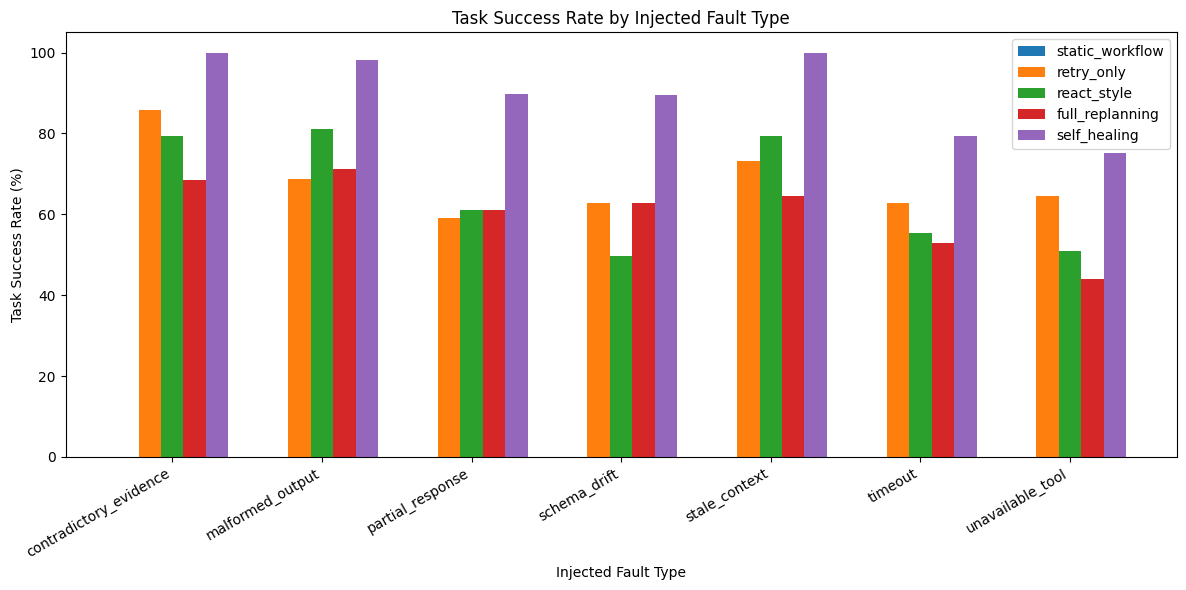

In [26]:
# -----------------------------
# Bar chart: success rate by injected fault type.
# -----------------------------

plot_df = failure_type_table_raw.copy()
plot_df["success_rate_pct"] = plot_df["success_rate"] * 100
fault_types = sorted(plot_df["actual_fault_type"].unique())

plt.figure(figsize=(12, 6))
bar_width = 0.15
x_positions = list(range(len(fault_types)))

for i, method in enumerate(METHOD_ORDER):
    method_df = plot_df[plot_df["method"] == method]
    method_values = []

    for fault_type in fault_types:
        row = method_df[method_df["actual_fault_type"] == fault_type]
        method_values.append(0 if row.empty else row["success_rate_pct"].iloc[0])

    positions = [x + i * bar_width for x in x_positions]
    plt.bar(positions, method_values, width=bar_width, label=method)

plt.xlabel("Injected Fault Type")
plt.ylabel("Task Success Rate (%)")
plt.title("Task Success Rate by Injected Fault Type")
plt.xticks([x + bar_width * 2 for x in x_positions], fault_types, rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "recovery_by_failure_type.png", dpi=300)
plt.show()


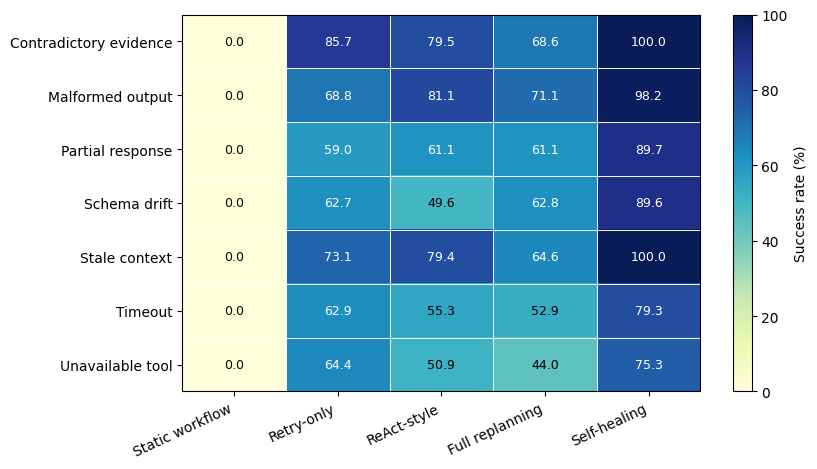

In [27]:
 # -----------------------------
# IEEE-style heatmap view of success rate by failure type and method.
# -----------------------------

import matplotlib.pyplot as plt
import numpy as np

# Paper-friendly display names
method_labels = {
    "static_workflow": "Static workflow",
    "retry_only": "Retry-only",
    "react_style": "ReAct-style",
    "full_replanning": "Full replanning",
    "self_healing": "Self-healing",
}

fault_type_labels = {
    "contradictory_evidence": "Contradictory evidence",
    "malformed_output": "Malformed output",
    "partial_response": "Partial response",
    "schema_drift": "Schema drift",
    "stale_context": "Stale context",
    "timeout": "Timeout",
    "unavailable_tool": "Unavailable tool",
}

# Build heatmap data
heatmap_data = failure_success_pivot.set_index("actual_fault_type")[METHOD_ORDER]

# Convert row/column labels to paper-friendly names
x_labels = [method_labels.get(method, method) for method in METHOD_ORDER]
y_labels = [fault_type_labels.get(fault, fault) for fault in heatmap_data.index]

fig, ax = plt.subplots(figsize=(8.5, 4.8))

# Use a clean, colorblind-friendly colormap
cmap = plt.get_cmap("YlGnBu")

im = ax.imshow(
    heatmap_data,
    aspect="auto",
    cmap=cmap,
    vmin=0,
    vmax=100
)

# Axis labels
ax.set_xticks(np.arange(len(METHOD_ORDER)))
ax.set_xticklabels(x_labels, rotation=25, ha="right")
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels(y_labels)

# No plot title. The LaTeX caption describes the figure.

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Success rate (%)")

# Add subtle white gridlines between cells
ax.set_xticks(np.arange(-0.5, len(METHOD_ORDER), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(heatmap_data.index), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.7)
ax.tick_params(which="minor", bottom=False, left=False)

# Add values inside cells with brightness-aware text color
for i in range(len(heatmap_data.index)):
    for j in range(len(METHOD_ORDER)):
        value = heatmap_data.iloc[i, j]

        # Get the background color for this value from the colormap
        rgba = cmap(value / 100.0)
        r, g, b, _ = rgba

        # Perceived luminance formula
        luminance = 0.299 * r + 0.587 * g + 0.114 * b

        # Use white text on dark cells, black text on light cells
        text_color = "white" if luminance < 0.5 else "black"

        ax.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=9
        )

plt.tight_layout()

# Save high-resolution figure for LaTeX
plt.savefig(FIGURES_DIR / "failure_type_success_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

### 12.8 Experiment 2 Completion Checklist

Experiment 2 is complete if the following checks pass:

- `actual_faults` exists in `df`.
- Faulted rows are non-empty.
- Each expected fault type appears in the fault-count table.
- `failure_type_results_100_tasks.csv` is generated.
- `failure_type_success_pivot.csv` is generated.
- `failure_type_success_pivot_table.tex` is generated.
- `recovery_by_failure_type.png` is generated.
- `failure_type_success_heatmap.png` is generated.


## 13. Experiment 3: Ablation Study

Experiment 3 answers **RQ4: Which architectural components contribute most to reliability improvement?**

Experiment 1 showed that the full self-healing orchestrator is more reliable than baseline orchestration strategies under injected faults. Experiment 2 showed how performance varies by injected fault type. Experiment 3 now checks whether the improvement comes from the full self-healing loop or from a simpler mechanism such as repeated retry.

An **ablation study** removes or weakens one component at a time. We compare the full self-healing orchestrator with variants that remove verifier calls, root-cause classification, recovery budgeting, targeted recovery, or observability traces.

Because ablations are meaningful only when recovery is needed, this experiment uses the nonzero fault settings: `0.1, 0.2, 0.3, 0.4, 0.5`.

### 13.1 Ablation Design

The ablation variants are:

| Variant | What changes | Expected signal |
|---|---|---|
| `self_healing_full` | Full self-healing loop | Highest or near-highest success |
| `self_healing_no_verifier` | Removes final verifier call | Lower verifier cost; effect on success is limited in detectable-fault settings |
| `self_healing_no_classifier` | Replaces failure-class-specific recovery with generic retry | Lower recovery success if classification matters |
| `self_healing_no_budget` | Increases recovery limit from 3 to 10 attempts | Similar or higher success but higher cost/recovery steps |
| `self_healing_no_targeted_recovery` | Removes failure-class-specific reduced-risk recovery | Lower success if targeted recovery matters |
| `self_healing_no_observability` | Disables recovery logs/traces | Similar success but no trace-level diagnosability |

For fairness, all ablation variants use a shared deterministic fault schedule name inside `execute_task_once()`. This keeps the injected-fault sequence comparable across variants while allowing the orchestration policy itself to differ.

In [28]:
# -----------------------------
# Experiment 3 helper: flatten ablation results.
# -----------------------------

def make_ablation_result_row(task, result, fault_intensity, seed):
    """
    Convert an ablation orchestrator result into a flat row for pandas.

    This mirrors run_single_experiment(), but includes trace-related fields
    so that the no-observability ablation can be evaluated directly.
    """
    actual_faults = result.get("actual_faults", [])

    if isinstance(actual_faults, list):
        actual_faults_str = ",".join(actual_faults)
    elif actual_faults is None:
        actual_faults_str = ""
    else:
        actual_faults_str = str(actual_faults)

    logs = result.get("logs", [])
    trace_events = len(logs) if isinstance(logs, list) else 0

    return {
        "task_id": task["task_id"],
        "category": task["category"],
        "method": result["method"],
        "fault_intensity": fault_intensity,
        "seed": seed,
        "success": result.get("success", False),
        "recovered": result.get("recovered", False),
        "silent_failure": result.get("silent_failure", False),
        "failure_detected": result.get("failure_detected", False),
        "failure_signal": result.get("failure_signal", None),
        "failure_class": result.get("failure_class", None),
        "actual_faults": actual_faults_str,
        "tool_calls": result.get("tool_calls", 0),
        "model_calls": result.get("model_calls", 0),
        "verifier_calls": result.get("verifier_calls", 0),
        "recovery_steps": result.get("recovery_steps", 0),
        "latency_ms": result.get("latency_ms", 0),
        "cost_proxy": result.get("cost_proxy", 0),
        "escalated": result.get("escalated", False),
        "trace_events": trace_events,
        "trace_available": trace_events > 0,
        "final_answer": result.get("final_answer", None),
    }


### 13.2 Generic Ablation Core

The next cell defines a reusable ablation engine. It implements the same control-loop structure as the full self-healing orchestrator but exposes switches for the components we want to remove or weaken:

- `use_classifier`: whether to classify failures into root-cause classes.
- `use_targeted_recovery`: whether recovery attempts receive failure-class-specific reduced fault intensity.
- `use_verifier`: whether final answers are validated with `verify_answer()`.
- `max_recovery_steps`: recovery budget.
- `record_logs`: whether observability traces are recorded.

This design avoids duplicating five long orchestrator functions and keeps the ablations easier to audit.

In [29]:
# -----------------------------
# Generic self-healing ablation core.
# -----------------------------

def self_healing_ablation_core(
    task,
    fault_intensity=0.0,
    seed=0,
    method_label="self_healing_ablation",
    max_recovery_steps=3,
    use_classifier=True,
    use_targeted_recovery=True,
    use_verifier=True,
    record_logs=True,
):
    """
    Parameterized self-healing loop used to implement ablation variants.

    Key implementation choices:
    - A shared fault-schedule name is passed to execute_task_once() so all
      ablation variants face comparable deterministic fault draws.
    - Disabling the classifier maps all failures to generic retry.
    - Disabling targeted recovery keeps recovery attempts at the original
      fault intensity instead of reducing the risk during repair/refresh.
    - Disabling the verifier removes verifier_calls from the cost proxy, but
      success is still computed externally using evaluate_success() so the
      experiment can report objective metrics.
    - Disabling observability removes logs/traces without changing execution.
    """

    SHARED_FAULT_SCHEDULE_NAME = "ablation_shared_fault_schedule"

    logs = []
    tool_calls = 0
    model_calls = 0
    verifier_calls = 0
    recovery_steps = 0
    total_latency = 0
    actual_faults = []

    final_answer = None
    failure_detected = False
    failure_signal = None
    failure_class = None
    recovered = False
    escalated = False

    def maybe_log(event):
        if record_logs:
            logs.append(event)

    # Initial execution.
    response = execute_task_once(
        task,
        fault_intensity=fault_intensity,
        seed=seed,
        method_name=SHARED_FAULT_SCHEDULE_NAME,
        attempt=0,
    )

    tool_calls += len(response.get("tool_trace", []))
    total_latency += response.get("latency_ms", 0)
    actual_faults.extend(response.get("actual_faults", []))

    maybe_log({
        "step": "initial_execution",
        "attempt": 0,
        "fault_intensity": fault_intensity,
        "response": response,
    })

    failure_detected, failure_signal = detect_failure(response)

    if not failure_detected:
        final_answer = response.get("output")
    else:
        if use_classifier:
            failure_class = classify_failure(failure_signal)
            recovery_policy_note = "classified_target_policy"
        else:
            failure_class = None
            recovery_policy_note = "generic_retry_no_classifier"

        maybe_log({
            "step": "failure_detected",
            "failure_signal": failure_signal,
            "failure_class": failure_class,
            "recovery_policy": recovery_policy_note,
        })

        for recovery_attempt in range(max_recovery_steps):
            recovery_steps += 1

            if use_classifier:
                recovery_action = choose_recovery_action(failure_class)
            else:
                recovery_action = "generic_retry"

            # Full self-healing reduces the effective fault intensity for targeted
            # repairs except for pure retry-with-backoff. The no-targeted-recovery
            # ablation disables this benefit.
            if not use_targeted_recovery:
                recovery_fault_intensity = fault_intensity
            elif recovery_action == "retry_with_backoff" or recovery_action == "generic_retry":
                recovery_fault_intensity = fault_intensity
            else:
                recovery_fault_intensity = fault_intensity * 0.25

            # Replanning consumes an additional model/planning call.
            if recovery_action == "replan":
                model_calls += 1

            maybe_log({
                "step": "recovery_action_selected",
                "recovery_attempt": recovery_attempt,
                "failure_class": failure_class,
                "recovery_action": recovery_action,
                "use_targeted_recovery": use_targeted_recovery,
                "recovery_fault_intensity": recovery_fault_intensity,
            })

            response = execute_task_once(
                task,
                fault_intensity=recovery_fault_intensity,
                seed=seed,
                method_name=SHARED_FAULT_SCHEDULE_NAME,
                attempt=recovery_attempt + 1,
            )

            tool_calls += len(response.get("tool_trace", []))
            total_latency += response.get("latency_ms", 0)
            actual_faults.extend(response.get("actual_faults", []))

            maybe_log({
                "step": "recovery_execution",
                "recovery_attempt": recovery_attempt,
                "response": response,
            })

            failure_detected, failure_signal = detect_failure(response)

            if not failure_detected:
                final_answer = response.get("output")
                recovered = True
                break

            if use_classifier:
                failure_class = classify_failure(failure_signal)

        if final_answer is None:
            escalated = True
            final_answer = response.get("output")

    # Verification / final metric calculation.
    if use_verifier:
        verification = verify_answer(final_answer, task)
        verifier_calls += verification["verifier_calls"]
        success = verification["verified"]
    else:
        # We still compute objective success for reporting, but the orchestrator
        # receives no verifier call/cost.
        success = evaluate_success(final_answer, task["success_criteria"])

    silent_failure = (not success) and (not failure_detected)

    if not success and failure_detected:
        escalated = True

    return {
        "task_id": task["task_id"],
        "method": method_label,
        "success": success,
        "recovered": recovered and success,
        "silent_failure": silent_failure,
        "failure_detected": failure_detected,
        "failure_signal": failure_signal,
        "failure_class": failure_class,
        "actual_faults": actual_faults,
        "final_answer": final_answer,
        "tool_calls": tool_calls,
        "model_calls": model_calls,
        "verifier_calls": verifier_calls,
        "recovery_steps": recovery_steps,
        "latency_ms": total_latency,
        "cost_proxy": tool_calls + model_calls + verifier_calls,
        "escalated": escalated,
        "logs": logs,
    }


### 13.3 Ablation Variant Functions

The following small wrapper functions configure the generic ablation core for each variant. Keeping these wrappers separate makes the experiment registry easy to read and reduces the risk of accidentally changing the full self-healing implementation used in Experiment 1.

In [30]:
# -----------------------------
# Ablation variants.
# -----------------------------

def self_healing_full(task, fault_intensity=0.0, seed=0):
    """Reference variant: full self-healing loop."""
    return self_healing_ablation_core(
        task,
        fault_intensity=fault_intensity,
        seed=seed,
        method_label="self_healing_full",
        max_recovery_steps=3,
        use_classifier=True,
        use_targeted_recovery=True,
        use_verifier=True,
        record_logs=True,
    )


def self_healing_no_verifier(task, fault_intensity=0.0, seed=0):
    """Ablation: remove final verifier call from the orchestration loop."""
    return self_healing_ablation_core(
        task,
        fault_intensity=fault_intensity,
        seed=seed,
        method_label="self_healing_no_verifier",
        max_recovery_steps=3,
        use_classifier=True,
        use_targeted_recovery=True,
        use_verifier=False,
        record_logs=True,
    )


def self_healing_no_classifier(task, fault_intensity=0.0, seed=0):
    """Ablation: detect failures but map them to generic retry without root-cause classification."""
    return self_healing_ablation_core(
        task,
        fault_intensity=fault_intensity,
        seed=seed,
        method_label="self_healing_no_classifier",
        max_recovery_steps=3,
        use_classifier=False,
        use_targeted_recovery=False,
        use_verifier=True,
        record_logs=True,
    )


def self_healing_no_budget(task, fault_intensity=0.0, seed=0):
    """Ablation: relax recovery budget by allowing up to 10 recovery steps."""
    return self_healing_ablation_core(
        task,
        fault_intensity=fault_intensity,
        seed=seed,
        method_label="self_healing_no_budget",
        max_recovery_steps=10,
        use_classifier=True,
        use_targeted_recovery=True,
        use_verifier=True,
        record_logs=True,
    )


def self_healing_no_targeted_recovery(task, fault_intensity=0.0, seed=0):
    """Ablation: keep detection/classification but disable targeted recovery benefit."""
    return self_healing_ablation_core(
        task,
        fault_intensity=fault_intensity,
        seed=seed,
        method_label="self_healing_no_targeted_recovery",
        max_recovery_steps=3,
        use_classifier=True,
        use_targeted_recovery=False,
        use_verifier=True,
        record_logs=True,
    )


def self_healing_no_observability(task, fault_intensity=0.0, seed=0):
    """Ablation: disable trace/observability logs while preserving execution behavior."""
    return self_healing_ablation_core(
        task,
        fault_intensity=fault_intensity,
        seed=seed,
        method_label="self_healing_no_observability",
        max_recovery_steps=3,
        use_classifier=True,
        use_targeted_recovery=True,
        use_verifier=True,
        record_logs=False,
    )


ablation_registry = {
    "self_healing_full": self_healing_full,
    "self_healing_no_verifier": self_healing_no_verifier,
    "self_healing_no_classifier": self_healing_no_classifier,
    "self_healing_no_budget": self_healing_no_budget,
    "self_healing_no_targeted_recovery": self_healing_no_targeted_recovery,
    "self_healing_no_observability": self_healing_no_observability,
}

print("Ablation variants:")
for name in ablation_registry:
    print("-", name)


Ablation variants:
- self_healing_full
- self_healing_no_verifier
- self_healing_no_classifier
- self_healing_no_budget
- self_healing_no_targeted_recovery
- self_healing_no_observability


### 13.4 Ablation Sanity Check

Before running the full ablation grid, we test each variant on one task. This verifies that all variants return the expected fields and that the no-verifier and no-observability variants behave as intended.

In [31]:
# -----------------------------
# Sanity check: run each ablation on one task.
# -----------------------------

ablation_test_task = tasks[0]

for method_name, method_fn in ablation_registry.items():
    result = method_fn(ablation_test_task, fault_intensity=0.3, seed=1)
    print("=" * 80)
    print("method:", result["method"])
    print("success:", result["success"])
    print("recovered:", result["recovered"])
    print("tool_calls:", result["tool_calls"])
    print("model_calls:", result["model_calls"])
    print("verifier_calls:", result["verifier_calls"])
    print("recovery_steps:", result["recovery_steps"])
    print("cost_proxy:", result["cost_proxy"])
    print("trace_events:", len(result.get("logs", [])))

# Basic assertions for the ablation-specific behavior.
assert self_healing_no_verifier(ablation_test_task, 0.3, 1)["verifier_calls"] == 0
assert len(self_healing_no_observability(ablation_test_task, 0.3, 1).get("logs", [])) == 0
print("Ablation sanity checks passed.")


method: self_healing_full
success: True
recovered: False
tool_calls: 1
model_calls: 0
verifier_calls: 1
recovery_steps: 0
cost_proxy: 2
trace_events: 1
method: self_healing_no_verifier
success: True
recovered: False
tool_calls: 1
model_calls: 0
verifier_calls: 0
recovery_steps: 0
cost_proxy: 1
trace_events: 1
method: self_healing_no_classifier
success: True
recovered: False
tool_calls: 1
model_calls: 0
verifier_calls: 1
recovery_steps: 0
cost_proxy: 2
trace_events: 1
method: self_healing_no_budget
success: True
recovered: False
tool_calls: 1
model_calls: 0
verifier_calls: 1
recovery_steps: 0
cost_proxy: 2
trace_events: 1
method: self_healing_no_targeted_recovery
success: True
recovered: False
tool_calls: 1
model_calls: 0
verifier_calls: 1
recovery_steps: 0
cost_proxy: 2
trace_events: 1
method: self_healing_no_observability
success: True
recovered: False
tool_calls: 1
model_calls: 0
verifier_calls: 1
recovery_steps: 0
cost_proxy: 2
trace_events: 0
Ablation sanity checks passed.


### 13.5 Run Full Ablation Grid

The ablation experiment uses the nonzero fault settings only: `0.1–0.5`. At zero fault intensity, all variants should succeed, so that setting is less informative for component analysis.

The expected row count is:

\[
100\ 	ext{tasks} 	imes 6\ 	ext{variants} 	imes 5\ 	ext{fault intensities} 	imes 3\ 	ext{seeds} = 9000\ 	ext{executions}.
\]

In [32]:
# -----------------------------
# Run the full ablation experiment.
# -----------------------------

ABLATION_FAULT_INTENSITIES = [0.1, 0.2, 0.3, 0.4, 0.5]
ABLATION_SEEDS = SEEDS

expected_ablation_rows = (
    len(tasks)
    * len(ablation_registry)
    * len(ABLATION_FAULT_INTENSITIES)
    * len(ABLATION_SEEDS)
)

print("Expected ablation rows:", expected_ablation_rows)

ablation_results = []

for task in tasks:
    for method_name, method_fn in ablation_registry.items():
        for fault_intensity in ABLATION_FAULT_INTENSITIES:
            for seed in ABLATION_SEEDS:
                result = method_fn(task, fault_intensity=fault_intensity, seed=seed)
                row = make_ablation_result_row(task, result, fault_intensity, seed)
                ablation_results.append(row)

ablation_df = pd.DataFrame(ablation_results)

print("Actual ablation rows:", len(ablation_df))
assert len(ablation_df) == expected_ablation_rows, (
    f"Expected {expected_ablation_rows}, got {len(ablation_df)}"
)

ablation_df.head()


Expected ablation rows: 9000


/tmp/ipykernel_2600/3439237790.py:86: DeprecationWarning: ast.Num is deprecated and will be removed in Python 3.14; use ast.Constant instead
  if isinstance(node, ast.Num):  # compatibility for older Python ASTs


Actual ablation rows: 9000


,task_id,category,method,fault_intensity,seed,success,recovered,silent_failure,failure_detected,failure_signal,failure_class,actual_faults,tool_calls,model_calls,verifier_calls,recovery_steps,latency_ms,cost_proxy,escalated,trace_events,trace_available,final_answer
0,retrieval_001,retrieval_evidence,self_healing_full,0.1,1,True,False,False,False,None,None,,1,0,1,0,80,2,False,1,True,Product A has standard support for 12 months.
1,retrieval_001,retrieval_evidence,self_healing_full,0.1,2,True,False,False,False,None,None,,1,0,1,0,80,2,False,1,True,Product A has standard support for 12 months.
2,retrieval_001,retrieval_evidence,self_healing_full,0.1,3,True,False,False,False,None,None,,1,0,1,0,80,2,False,1,True,Product A has standard support for 12 months.
3,retrieval_001,retrieval_evidence,self_healing_full,0.2,1,True,False,False,False,None,None,,1,0,1,0,80,2,False,1,True,Product A has standard support for 12 months.
4,retrieval_001,retrieval_evidence,self_healing_full,0.2,2,True,False,False,False,None,None,,1,0,1,0,80,2,False,1,True,Product A has standard support for 12 months.


### 13.6 Ablation Summary Tables

The first table summarizes each ablation variant across all nonzero fault settings. The second table breaks success and cost down by fault intensity. These tables are the main quantitative deliverables for Experiment 3.

In [33]:
# -----------------------------
# Overall ablation summary.
# -----------------------------

ablation_summary = ablation_df.groupby("method").agg(
    success_rate=("success", "mean"),
    recovery_rate=("recovered", "mean"),
    silent_failure_rate=("silent_failure", "mean"),
    avg_recovery_steps=("recovery_steps", "mean"),
    avg_tool_calls=("tool_calls", "mean"),
    avg_model_calls=("model_calls", "mean"),
    avg_verifier_calls=("verifier_calls", "mean"),
    avg_latency_ms=("latency_ms", "mean"),
    avg_cost_proxy=("cost_proxy", "mean"),
    avg_trace_events=("trace_events", "mean"),
).reset_index()

ablation_summary_pretty = ablation_summary.copy()

for col in ["success_rate", "recovery_rate", "silent_failure_rate"]:
    ablation_summary_pretty[col] = (ablation_summary_pretty[col] * 100).round(1)

for col in [
    "avg_recovery_steps", "avg_tool_calls", "avg_model_calls",
    "avg_verifier_calls", "avg_latency_ms", "avg_cost_proxy", "avg_trace_events"
]:
    ablation_summary_pretty[col] = ablation_summary_pretty[col].round(2)

print("Ablation summary:")
display(ablation_summary_pretty)

ablation_summary_pretty.to_csv(RESULTS_DIR / "ablation_summary_100_tasks.csv", index=False)
ablation_summary_pretty.to_latex(TABLES_DIR / "ablation_summary_table_for_latex.tex", index=False, float_format="%.2f")


Ablation summary:


,method,success_rate,recovery_rate,silent_failure_rate,avg_recovery_steps,avg_tool_calls,avg_model_calls,avg_verifier_calls,avg_latency_ms,avg_cost_proxy,avg_trace_events
0,self_healing_full,99.3,32.3,0.0,0.43,2.30,0.0,1.0,565.56,3.30,2.18
1,self_healing_no_budget,100.0,33.0,0.0,0.44,2.31,0.0,1.0,576.36,3.31,2.21
2,self_healing_no_classifier,95.7,28.7,0.0,0.56,2.45,0.0,1.0,774.50,3.45,2.45
3,self_healing_no_observability,99.3,32.3,0.0,0.43,2.30,0.0,1.0,565.56,3.30,0.00
4,self_healing_no_targeted_recovery,95.7,28.7,0.0,0.56,2.45,0.0,1.0,774.50,3.45,2.45
5,self_healing_no_verifier,99.3,32.3,0.0,0.43,2.30,0.0,0.0,565.56,2.30,2.18


In [34]:
# -----------------------------
# Ablation results by fault intensity.
# -----------------------------

ablation_by_fault_intensity = ablation_df.groupby(["fault_intensity", "method"]).agg(
    success_rate=("success", "mean"),
    recovery_rate=("recovered", "mean"),
    avg_recovery_steps=("recovery_steps", "mean"),
    avg_cost_proxy=("cost_proxy", "mean"),
    avg_trace_events=("trace_events", "mean"),
).reset_index()

ablation_by_fault_intensity_pretty = ablation_by_fault_intensity.copy()

for col in ["success_rate", "recovery_rate"]:
    ablation_by_fault_intensity_pretty[col] = (
        ablation_by_fault_intensity_pretty[col] * 100
    ).round(1)

for col in ["avg_recovery_steps", "avg_cost_proxy", "avg_trace_events"]:
    ablation_by_fault_intensity_pretty[col] = ablation_by_fault_intensity_pretty[col].round(2)

print("Ablation results by fault intensity:")
display(ablation_by_fault_intensity_pretty)

ablation_by_fault_intensity_pretty.to_csv(RESULTS_DIR / "ablation_by_fault_intensity.csv", index=False)
ablation_by_fault_intensity_pretty.to_latex(TABLES_DIR / "ablation_by_fault_intensity_table.tex", index=False, float_format="%.2f")


Ablation results by fault intensity:


,fault_intensity,method,success_rate,recovery_rate,avg_recovery_steps,avg_cost_proxy,avg_trace_events
0,0.1,self_healing_full,100.0,10.7,0.12,2.89,1.35
1,0.1,self_healing_no_budget,100.0,10.7,0.12,2.89,1.35
2,0.1,self_healing_no_classifier,100.0,10.7,0.12,2.89,1.35
3,0.1,self_healing_no_observability,100.0,10.7,0.12,2.89,0.00
4,0.1,self_healing_no_targeted_recovery,100.0,10.7,0.12,2.89,1.35
5,0.1,self_healing_no_verifier,100.0,10.7,0.12,1.89,1.35
6,0.2,self_healing_full,100.0,24.7,0.27,3.10,1.79
7,0.2,self_healing_no_budget,100.0,24.7,0.27,3.10,1.79
8,0.2,self_healing_no_classifier,99.3,24.0,0.32,3.15,1.88
9,0.2,self_healing_no_observability,100.0,24.7,0.27,3.10,0.00


### 13.7 Ablation Interpretation Helpers

The next table compares each ablated variant against the full self-healing version. Positive values indicate that the full version performs better. This helps identify which removed components cause the largest reliability or cost changes.

In [35]:
# -----------------------------
# Interpretation table: compare each variant to full self-healing.
# -----------------------------

full_row = ablation_summary_pretty[ablation_summary_pretty["method"] == "self_healing_full"].iloc[0]

ablation_interpretation_rows = []
for _, row in ablation_summary_pretty.iterrows():
    if row["method"] == "self_healing_full":
        continue
    ablation_interpretation_rows.append({
        "ablation_variant": row["method"],
        "full_success_rate": full_row["success_rate"],
        "variant_success_rate": row["success_rate"],
        "success_drop_vs_full": round(full_row["success_rate"] - row["success_rate"], 1),
        "full_cost_proxy": full_row["avg_cost_proxy"],
        "variant_cost_proxy": row["avg_cost_proxy"],
        "cost_change_vs_full": round(row["avg_cost_proxy"] - full_row["avg_cost_proxy"], 2),
        "full_trace_events": full_row["avg_trace_events"],
        "variant_trace_events": row["avg_trace_events"],
    })

ablation_interpretation = pd.DataFrame(ablation_interpretation_rows)
print("Ablation interpretation helper table:")
display(ablation_interpretation)

ablation_interpretation.to_csv(RESULTS_DIR / "ablation_interpretation.csv", index=False)
ablation_interpretation.to_latex(TABLES_DIR / "ablation_interpretation_table.tex", index=False, float_format="%.2f")


Ablation interpretation helper table:


,ablation_variant,full_success_rate,variant_success_rate,success_drop_vs_full,full_cost_proxy,variant_cost_proxy,cost_change_vs_full,full_trace_events,variant_trace_events
0,self_healing_no_budget,99.3,100.0,-0.7,3.3,3.31,0.01,2.18,2.21
1,self_healing_no_classifier,99.3,95.7,3.6,3.3,3.45,0.15,2.18,2.45
2,self_healing_no_observability,99.3,99.3,0.0,3.3,3.30,0.00,2.18,0.00
3,self_healing_no_targeted_recovery,99.3,95.7,3.6,3.3,3.45,0.15,2.18,2.45
4,self_healing_no_verifier,99.3,99.3,0.0,3.3,2.30,-1.00,2.18,2.18


### 13.8 Ablation Figures

The first figure shows how each ablation variant degrades as fault intensity increases. The second figure compares average cost proxy by variant. These plots are useful for deciding which ablation results belong in the main paper versus the appendix.

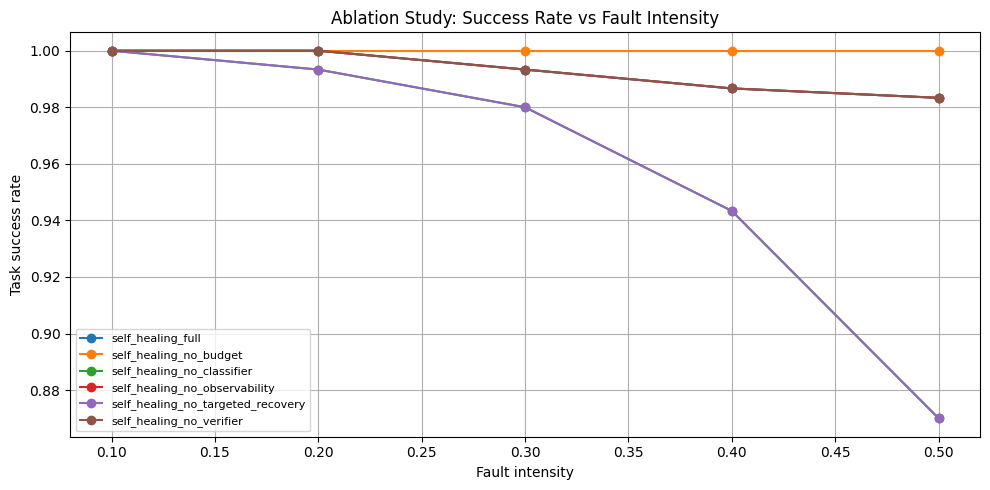

In [36]:
# -----------------------------
# Plot: ablation success rate vs fault intensity.
# -----------------------------

plot_df = ablation_df.groupby(["fault_intensity", "method"])["success"].mean().reset_index()

plt.figure(figsize=(10, 5))
for method in sorted(plot_df["method"].unique()):
    method_df = plot_df[plot_df["method"] == method]
    plt.plot(method_df["fault_intensity"], method_df["success"], marker="o", label=method)

plt.xlabel("Fault intensity")
plt.ylabel("Task success rate")
plt.title("Ablation Study: Success Rate vs Fault Intensity")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ablation_success_rate_vs_fault_intensity.png", dpi=300)
plt.show()


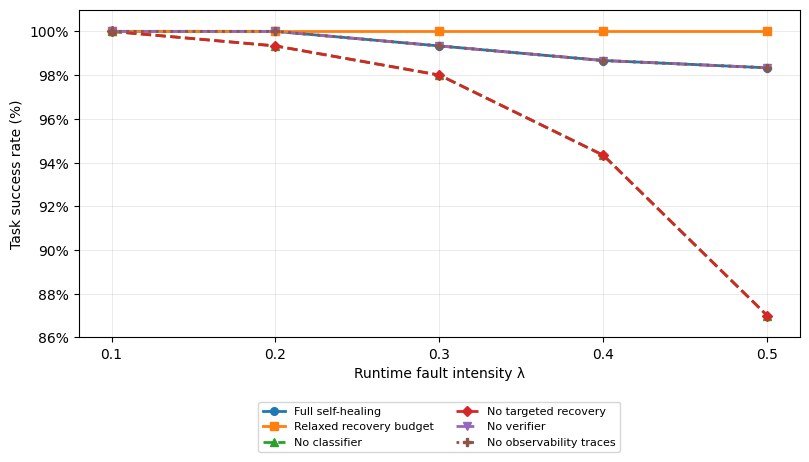

In [37]:
# -----------------------------
# IEEE-style plot: ablation success rate vs runtime fault intensity.
# -----------------------------

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Group results by fault intensity and ablation variant
plot_df = (
    ablation_df.groupby(["fault_intensity", "method"])["success"]
    .mean()
    .reset_index()
)

# Convert success rate from 0-1 to 0-100
plot_df["success_pct"] = plot_df["success"] * 100

# Paper-friendly display names
method_labels = {
    "self_healing_full": "Full self-healing",
    "self_healing_no_budget": "Relaxed recovery budget",
    "self_healing_no_classifier": "No classifier",
    "self_healing_no_observability": "No observability traces",
    "self_healing_no_targeted_recovery": "No targeted recovery",
    "self_healing_no_verifier": "No verifier",
}

# Stable plotting order
method_order = [
    "self_healing_full",
    "self_healing_no_budget",
    "self_healing_no_classifier",
    "self_healing_no_targeted_recovery",
    "self_healing_no_verifier",
    "self_healing_no_observability",
]

# Distinct line/marker styles for readability
line_styles = {
    "self_healing_full": "-",
    "self_healing_no_budget": "-",
    "self_healing_no_classifier": "--",
    "self_healing_no_targeted_recovery": "--",
    "self_healing_no_verifier": "-.",
    "self_healing_no_observability": ":",
}

marker_styles = {
    "self_healing_full": "o",
    "self_healing_no_budget": "s",
    "self_healing_no_classifier": "^",
    "self_healing_no_targeted_recovery": "D",
    "self_healing_no_verifier": "v",
    "self_healing_no_observability": "P",
}

fig, ax = plt.subplots(figsize=(8.2, 4.8))

for method in method_order:
    method_df = plot_df[plot_df["method"] == method].sort_values("fault_intensity")

    if method_df.empty:
        continue

    ax.plot(
        method_df["fault_intensity"],
        method_df["success_pct"],
        linestyle=line_styles.get(method, "-"),
        marker=marker_styles.get(method, "o"),
        linewidth=2,
        markersize=5.5,
        label=method_labels.get(method, method),
    )

# Axis labels
ax.set_xlabel("Runtime fault intensity λ")
ax.set_ylabel("Task success rate (%)")

# Use percentage formatting on y-axis
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

# Nonzero ablation fault-intensity ticks
ax.set_xticks(sorted(plot_df["fault_intensity"].unique()))

# Zoomed y-axis for ablation differences
ax.set_ylim(86, 101)

# Light IEEE-style grid
ax.grid(True, alpha=0.25, linewidth=0.7)
ax.set_axisbelow(True)

# Legend below plot to avoid covering lines
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    fontsize=8,
    frameon=True,
)

# No internal title. The LaTeX caption describes the figure.
plt.tight_layout()

# Save high-resolution figure for LaTeX
plt.savefig(
    FIGURES_DIR / "ablation_success_rate_vs_fault_intensity.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

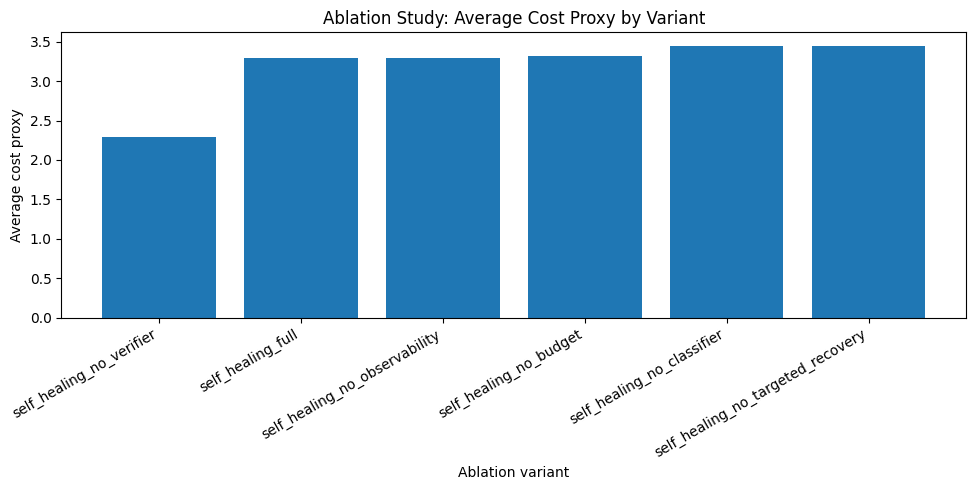

In [38]:
# -----------------------------
# Plot: ablation cost proxy by variant.
# -----------------------------

cost_df = ablation_summary.sort_values("avg_cost_proxy")

plt.figure(figsize=(10, 5))
plt.bar(cost_df["method"], cost_df["avg_cost_proxy"])
plt.xlabel("Ablation variant")
plt.ylabel("Average cost proxy")
plt.title("Ablation Study: Average Cost Proxy by Variant")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ablation_cost_proxy_by_variant.png", dpi=300)
plt.show()


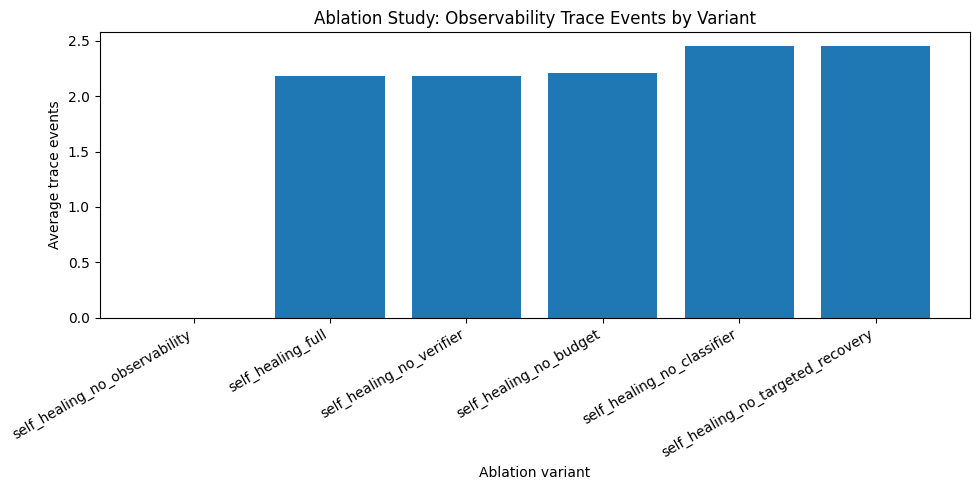

In [39]:
# -----------------------------
# Plot: trace events by ablation variant.
# -----------------------------

trace_df = ablation_summary.sort_values("avg_trace_events")

plt.figure(figsize=(10, 5))
plt.bar(trace_df["method"], trace_df["avg_trace_events"])
plt.xlabel("Ablation variant")
plt.ylabel("Average trace events")
plt.title("Ablation Study: Observability Trace Events by Variant")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ablation_trace_events_by_variant.png", dpi=300)
plt.show()


### 13.9 Export Ablation Data and Completion Checklist

The following cell exports the full ablation dataframe and verifies that the expected Experiment 3 artifacts exist.

In [40]:
# -----------------------------
# Export full ablation outputs.
# -----------------------------

ablation_df.to_csv(RESULTS_DIR / "ablation_results_100_tasks.csv", index=False)

required_ablation_outputs = [
    RESULTS_DIR / "ablation_results_100_tasks.csv",
    RESULTS_DIR / "ablation_summary_100_tasks.csv",
    RESULTS_DIR / "ablation_by_fault_intensity.csv",
    RESULTS_DIR / "ablation_interpretation.csv",
    TABLES_DIR / "ablation_summary_table_for_latex.tex",
    TABLES_DIR / "ablation_by_fault_intensity_table.tex",
    TABLES_DIR / "ablation_interpretation_table.tex",
    FIGURES_DIR / "ablation_success_rate_vs_fault_intensity.png",
    FIGURES_DIR / "ablation_cost_proxy_by_variant.png",
    FIGURES_DIR / "ablation_trace_events_by_variant.png",
]

missing_ablation_outputs = [str(path) for path in required_ablation_outputs if not path.exists()]
assert not missing_ablation_outputs, f"Missing ablation outputs: {missing_ablation_outputs}"

print("Experiment 3 completion checklist:")
print("[x] Ablation variants defined")
print("[x] Ablation sanity checks passed")
print("[x] Full ablation grid executed")
print("[x] Ablation summary table generated")
print("[x] Ablation by fault intensity table generated")
print("[x] Ablation interpretation table generated")
print("[x] Ablation plots generated")
print("[x] Ablation CSV and LaTeX exports generated")


Experiment 3 completion checklist:
[x] Ablation variants defined
[x] Ablation sanity checks passed
[x] Full ablation grid executed
[x] Ablation summary table generated
[x] Ablation by fault intensity table generated
[x] Ablation interpretation table generated
[x] Ablation plots generated
[x] Ablation CSV and LaTeX exports generated


## 14. Experiment 4: Semantic Silent-Failure Experiment

Experiments 1--3 evaluate mostly **detectable** tool/runtime failures: timeouts, unavailable tools, malformed outputs, schema drift, partial responses, stale context markers, and contradictory evidence markers. These failures usually produce explicit signals that can be detected by the orchestrator.

Experiment 4 evaluates a more dangerous failure mode: **semantic silent failure**. In this setting, a tool or execution path returns a plausible, syntactically valid, but incorrect answer. The output has no explicit error signal, so retry-only and full-replanning baselines may treat it as successful.

This experiment answers **RQ5**: how do orchestration strategies behave with respect to silent or undetected failures under semantic fault settings?

The expected behavior is:

- Static, retry-only, ReAct-style, and full-replanning baselines often return wrong answers silently because no explicit failure is detected.
- Self-healing uses final-answer verification to reject wrong-but-plausible outputs and recover.
- Self-healing without a verifier behaves like the baselines, which isolates the value of verification.


## Semantic Fault Model and Verifier Scope

The semantic silent-failure experiment uses controlled wrong-but-plausible outputs and task-specific success criteria. These outputs are syntactically valid and therefore may not trigger ordinary runtime failure detection.

The verifier in this notebook is a controlled task-criteria-based verifier. It is not intended to model a general-purpose real-world verifier. The experiment tests whether explicit verification can catch semantically invalid outputs under the controlled benchmark setting.

In [41]:
# -----------------------------
# Semantic wrong-answer generator
# -----------------------------

def make_semantic_wrong_answer(task):
    """
    Create a plausible but incorrect final answer for a task.

    The wrong answer is intentionally designed to:
    1. Look like a normal successful answer.
    2. Avoid explicit error markers such as status='error'.
    3. Fail the task-specific success criteria.
    4. Avoid triggering detect_failure().

    This simulates a silent semantic failure: the system appears to complete
    the task, but the final answer is wrong.
    """
    category = task.get("category", "")
    task_id = task.get("task_id", "")

    if category == "retrieval_evidence":
        return "The requested policy appears to indicate a support period of 6 months."

    if category == "multi_step_api_workflow":
        return "The workflow completed successfully: the customer tier is basic and shipping takes 7 business days."

    if category == "calculation_verification":
        return "The computed result is 999."

    if category == "planning_tool_selection":
        return "The selected tool indicates that the item is unavailable with stock of 0."

    if category == "contradiction_resolution":
        return "After resolving the conflict, the current answer is 6 months."

    return f"The task {task_id} completed successfully, but the result is unavailable."


# Quick spot-check: the wrong answer should fail success criteria.
for sample_task in tasks[:3]:
    wrong_answer = make_semantic_wrong_answer(sample_task)
    print(sample_task["task_id"], "success?", evaluate_success(wrong_answer, sample_task["success_criteria"]), "=>", wrong_answer)


retrieval_001 success? False => The requested policy appears to indicate a support period of 6 months.
retrieval_002 success? False => The requested policy appears to indicate a support period of 6 months.
retrieval_003 success? False => The requested policy appears to indicate a support period of 6 months.


In [42]:
# -----------------------------
# Semantic executor
# -----------------------------

def execute_task_once_with_semantic_fault(
    task,
    semantic_fault_intensity=0.0,
    seed=0,
    method_name="unknown",
    attempt=0,
):
    """
    Execute a task under semantic silent-failure injection.

    Unlike the runtime/tool fault injection used in Experiments 1--3, this
    function first executes the task cleanly, then probabilistically replaces
    the final answer with a plausible but incorrect answer.

    The injected semantic fault intentionally returns status='success'. This
    makes the output a silent-failure candidate because detect_failure() should
    not flag it. Only the verifier/success criterion can identify it as wrong.
    """

    # Run the original task cleanly. If zero-fault validation passed, this
    # should return the task's expected answer.
    clean_response = execute_task_once(
        task=task,
        fault_intensity=0.0,
        seed=seed,
        method_name=method_name,
        attempt=attempt,
    )

    clean_failure_detected, _ = detect_failure(clean_response)
    if clean_failure_detected:
        return clean_response

    semantic_seed = stable_seed(
        task.get("task_id", "unknown_task"),
        method_name,
        seed,
        attempt,
        "semantic_wrong_output",
        semantic_fault_intensity,
    )

    rng = random.Random(semantic_seed)
    inject_semantic_fault = rng.random() < semantic_fault_intensity

    if inject_semantic_fault:
        wrong_answer = make_semantic_wrong_answer(task)
        return {
            "tool": "semantic_task_executor",
            "status": "success",
            "output": wrong_answer,
            "latency_ms": clean_response.get("latency_ms", 0),
            "tool_trace": clean_response.get("tool_trace", []),
            "actual_faults": ["semantic_wrong_output"],
            "semantic_fault_injected": True,
            "semantic_fault_type": "semantic_wrong_output",
        }

    clean_response = dict(clean_response)
    clean_response["semantic_fault_injected"] = False
    clean_response["semantic_fault_type"] = None
    return clean_response


In [43]:
# -----------------------------
# Sanity check: semantic faults should be wrong but not detected by detect_failure().
# -----------------------------

for intensity in [0.0, 0.5, 1.0]:
    response = execute_task_once_with_semantic_fault(
        task=tasks[0],
        semantic_fault_intensity=intensity,
        seed=1,
        method_name="debug_semantic",
        attempt=0,
    )

    failure_detected, failure_signal = detect_failure(response)
    success = evaluate_success(response.get("output"), tasks[0]["success_criteria"])

    print("=" * 80)
    print("semantic_fault_intensity:", intensity)
    print("output:", response.get("output"))
    print("actual_faults:", response.get("actual_faults"))
    print("failure_detected:", failure_detected)
    print("failure_signal:", failure_signal)
    print("success:", success)
    print("silent_failure_candidate:", (not success) and (not failure_detected))

# At intensity 1.0, the wrong answer should be a silent-failure candidate.
forced_response = execute_task_once_with_semantic_fault(tasks[0], semantic_fault_intensity=1.0, seed=1, method_name="debug_semantic", attempt=0)
forced_failure_detected, _ = detect_failure(forced_response)
forced_success = evaluate_success(forced_response.get("output"), tasks[0]["success_criteria"])
assert (not forced_success) and (not forced_failure_detected), "Semantic fault did not create a silent-failure candidate."


semantic_fault_intensity: 0.0
output: Product A has standard support for 12 months.
actual_faults: []
failure_detected: False
failure_signal: None
success: True
silent_failure_candidate: False
semantic_fault_intensity: 0.5
output: Product A has standard support for 12 months.
actual_faults: []
failure_detected: False
failure_signal: None
success: True
silent_failure_candidate: False
semantic_fault_intensity: 1.0
output: The requested policy appears to indicate a support period of 6 months.
actual_faults: ['semantic_wrong_output']
failure_detected: False
failure_signal: None
success: False
silent_failure_candidate: True


### 14.1 Semantic Orchestration Methods

The following methods mirror the Experiment 1 baselines, but use the semantic executor. The baselines generally stop when the response looks successful. The self-healing method adds verifier-based validation and can recover when a plausible answer fails the success criterion.


In [44]:
# -----------------------------
# Semantic baseline and self-healing methods
# -----------------------------

def semantic_static_workflow(task, semantic_fault_intensity=0.0, seed=0):
    """Static workflow under semantic silent-failure injection."""
    response = execute_task_once_with_semantic_fault(task, semantic_fault_intensity, seed, "semantic_static_workflow", 0)
    failure_detected, failure_signal = detect_failure(response)
    final_answer = response.get("output")
    success = evaluate_success(final_answer, task["success_criteria"])
    silent_failure = (not success) and (not failure_detected)
    return {
        "task_id": task["task_id"], "method": "semantic_static_workflow", "success": success,
        "recovered": False, "silent_failure": silent_failure, "failure_detected": failure_detected,
        "failure_signal": failure_signal, "failure_class": None, "actual_faults": response.get("actual_faults", []),
        "final_answer": final_answer, "tool_calls": len(response.get("tool_trace", [])), "model_calls": 0,
        "verifier_calls": 0, "recovery_steps": 0, "latency_ms": response.get("latency_ms", 0),
        "cost_proxy": len(response.get("tool_trace", [])), "escalated": False,
        "logs": [{"step": "semantic_static_execution", "response": response}],
    }


def semantic_retry_only(task, semantic_fault_intensity=0.0, seed=0, max_retries=2):
    """Retry-only baseline. Semantic wrong outputs usually do not trigger retry."""
    logs, actual_faults = [], []
    tool_calls = total_latency = recovery_steps = 0
    failure_detected, failure_signal, recovered = False, None, False
    final_answer = None

    for attempt in range(max_retries + 1):
        response = execute_task_once_with_semantic_fault(task, semantic_fault_intensity, seed, "semantic_retry_only", attempt)
        logs.append({"attempt": attempt, "response": response})
        tool_calls += len(response.get("tool_trace", []))
        total_latency += response.get("latency_ms", 0)
        actual_faults.extend(response.get("actual_faults", []))
        failure_detected, failure_signal = detect_failure(response)
        if not failure_detected:
            final_answer = response.get("output")
            recovered = attempt > 0
            break
        recovery_steps += 1

    if final_answer is None:
        final_answer = response.get("output")
    success = evaluate_success(final_answer, task["success_criteria"])
    silent_failure = (not success) and (not failure_detected)
    return {
        "task_id": task["task_id"], "method": "semantic_retry_only", "success": success,
        "recovered": recovered and success, "silent_failure": silent_failure, "failure_detected": failure_detected,
        "failure_signal": failure_signal, "failure_class": None, "actual_faults": actual_faults,
        "final_answer": final_answer, "tool_calls": tool_calls, "model_calls": 0, "verifier_calls": 0,
        "recovery_steps": recovery_steps, "latency_ms": total_latency, "cost_proxy": tool_calls,
        "escalated": False, "logs": logs,
    }


def semantic_react_style(task, semantic_fault_intensity=0.0, seed=0, max_steps=3):
    """Simplified ReAct-style baseline under semantic silent-failure injection."""
    logs, actual_faults = [], []
    tool_calls = model_calls = total_latency = recovery_steps = 0
    failure_detected, failure_signal, recovered = False, None, False
    final_answer = None

    for step in range(max_steps):
        model_calls += 1
        response = execute_task_once_with_semantic_fault(task, semantic_fault_intensity, seed, "semantic_react_style", step)
        logs.append({"step": step, "response": response})
        tool_calls += len(response.get("tool_trace", []))
        total_latency += response.get("latency_ms", 0)
        actual_faults.extend(response.get("actual_faults", []))
        failure_detected, failure_signal = detect_failure(response)
        if not failure_detected:
            final_answer = response.get("output")
            recovered = step > 0
            break
        recovery_steps += 1

    if final_answer is None:
        final_answer = response.get("output")
    success = evaluate_success(final_answer, task["success_criteria"])
    silent_failure = (not success) and (not failure_detected)
    return {
        "task_id": task["task_id"], "method": "semantic_react_style", "success": success,
        "recovered": recovered and success, "silent_failure": silent_failure, "failure_detected": failure_detected,
        "failure_signal": failure_signal, "failure_class": None, "actual_faults": actual_faults,
        "final_answer": final_answer, "tool_calls": tool_calls, "model_calls": model_calls, "verifier_calls": 0,
        "recovery_steps": recovery_steps, "latency_ms": total_latency, "cost_proxy": tool_calls + model_calls,
        "escalated": False, "logs": logs,
    }


def semantic_full_replanning(task, semantic_fault_intensity=0.0, seed=0, max_replans=2):
    """Full-replanning baseline. Semantic wrong outputs usually prevent replanning."""
    logs, actual_faults = [], []
    tool_calls = model_calls = total_latency = recovery_steps = 0
    failure_detected, failure_signal, recovered = False, None, False
    final_answer = None

    for attempt in range(max_replans + 1):
        model_calls += 1
        response = execute_task_once_with_semantic_fault(task, semantic_fault_intensity, seed, "semantic_full_replanning", attempt)
        logs.append({"attempt": attempt, "response": response})
        tool_calls += len(response.get("tool_trace", []))
        total_latency += response.get("latency_ms", 0)
        actual_faults.extend(response.get("actual_faults", []))
        failure_detected, failure_signal = detect_failure(response)
        if not failure_detected:
            final_answer = response.get("output")
            recovered = attempt > 0
            break
        recovery_steps += 1

    if final_answer is None:
        final_answer = response.get("output")
    success = evaluate_success(final_answer, task["success_criteria"])
    silent_failure = (not success) and (not failure_detected)
    return {
        "task_id": task["task_id"], "method": "semantic_full_replanning", "success": success,
        "recovered": recovered and success, "silent_failure": silent_failure, "failure_detected": failure_detected,
        "failure_signal": failure_signal, "failure_class": None, "actual_faults": actual_faults,
        "final_answer": final_answer, "tool_calls": tool_calls, "model_calls": model_calls, "verifier_calls": 0,
        "recovery_steps": recovery_steps, "latency_ms": total_latency, "cost_proxy": tool_calls + model_calls,
        "escalated": False, "logs": logs,
    }


In [45]:
# -----------------------------
# Semantic self-healing methods
# -----------------------------

def semantic_self_healing(task, semantic_fault_intensity=0.0, seed=0, max_recovery_steps=3):
    """
    Self-healing under semantic silent-failure injection.

    The key behavior is verifier-based rejection. Even if detect_failure() does
    not detect a runtime/tool error, verify_answer() can reject a wrong final
    answer and trigger semantic recovery.
    """
    logs, actual_faults = [], []
    tool_calls = model_calls = verifier_calls = recovery_steps = total_latency = 0
    failure_detected, failure_signal, failure_class = False, None, None
    recovered = escalated = False

    response = execute_task_once_with_semantic_fault(task, semantic_fault_intensity, seed, "semantic_self_healing", 0)
    tool_calls += len(response.get("tool_trace", []))
    total_latency += response.get("latency_ms", 0)
    actual_faults.extend(response.get("actual_faults", []))
    logs.append({"step": "initial_execution", "response": response})

    failure_detected, failure_signal = detect_failure(response)
    final_answer = response.get("output")
    verification = verify_answer(final_answer, task)
    verifier_calls += verification["verifier_calls"]
    success = verification["verified"]

    if not success:
        # If there was no explicit runtime/tool failure, the verifier converts
        # this into a detected semantic validation failure.
        if not failure_detected:
            failure_detected = True
            failure_signal = "semantic_validation_failure"
            failure_class = "semantic_failure"

        logs.append({
            "step": "verifier_rejected_answer",
            "failure_signal": failure_signal,
            "failure_class": failure_class,
            "final_answer": final_answer,
        })

        for recovery_attempt in range(max_recovery_steps):
            recovery_steps += 1
            recovery_semantic_fault_intensity = semantic_fault_intensity * 0.25
            response = execute_task_once_with_semantic_fault(
                task,
                recovery_semantic_fault_intensity,
                seed,
                "semantic_self_healing",
                recovery_attempt + 1,
            )
            tool_calls += len(response.get("tool_trace", []))
            total_latency += response.get("latency_ms", 0)
            actual_faults.extend(response.get("actual_faults", []))
            final_answer = response.get("output")
            logs.append({
                "step": "semantic_recovery_execution",
                "recovery_attempt": recovery_attempt,
                "recovery_semantic_fault_intensity": recovery_semantic_fault_intensity,
                "response": response,
            })
            recovery_verification = verify_answer(final_answer, task)
            verifier_calls += recovery_verification["verifier_calls"]
            if recovery_verification["verified"]:
                success = True
                recovered = True
                failure_detected = False
                failure_signal = None
                failure_class = None
                break
        if not success:
            escalated = True

    silent_failure = (not success) and (not failure_detected)
    return {
        "task_id": task["task_id"], "method": "semantic_self_healing", "success": success,
        "recovered": recovered and success, "silent_failure": silent_failure, "failure_detected": failure_detected,
        "failure_signal": failure_signal, "failure_class": failure_class, "actual_faults": actual_faults,
        "final_answer": final_answer, "tool_calls": tool_calls, "model_calls": model_calls,
        "verifier_calls": verifier_calls, "recovery_steps": recovery_steps, "latency_ms": total_latency,
        "cost_proxy": tool_calls + model_calls + verifier_calls, "escalated": escalated, "logs": logs,
    }


def semantic_self_healing_no_verifier(task, semantic_fault_intensity=0.0, seed=0):
    """Self-healing ablation without verifier for semantic faults."""
    response = execute_task_once_with_semantic_fault(task, semantic_fault_intensity, seed, "semantic_self_healing_no_verifier", 0)
    failure_detected, failure_signal = detect_failure(response)
    final_answer = response.get("output")
    success = evaluate_success(final_answer, task["success_criteria"])
    silent_failure = (not success) and (not failure_detected)
    return {
        "task_id": task["task_id"], "method": "semantic_self_healing_no_verifier", "success": success,
        "recovered": False, "silent_failure": silent_failure, "failure_detected": failure_detected,
        "failure_signal": failure_signal, "failure_class": None, "actual_faults": response.get("actual_faults", []),
        "final_answer": final_answer, "tool_calls": len(response.get("tool_trace", [])), "model_calls": 0,
        "verifier_calls": 0, "recovery_steps": 0, "latency_ms": response.get("latency_ms", 0),
        "cost_proxy": len(response.get("tool_trace", [])), "escalated": False,
        "logs": [{"step": "semantic_no_verifier_execution", "response": response}],
    }


In [46]:
# -----------------------------
# Registry and sanity check for semantic experiment
# -----------------------------

semantic_registry = {
    "semantic_static_workflow": semantic_static_workflow,
    "semantic_retry_only": semantic_retry_only,
    "semantic_react_style": semantic_react_style,
    "semantic_full_replanning": semantic_full_replanning,
    "semantic_self_healing": semantic_self_healing,
    "semantic_self_healing_no_verifier": semantic_self_healing_no_verifier,
}

print("Semantic methods:")
print(list(semantic_registry.keys()))

# Sanity check at intensity 1.0. Baselines should often be silent failures;
# self-healing should use verification and may recover.
for method_name, method_fn in semantic_registry.items():
    result = method_fn(tasks[0], semantic_fault_intensity=1.0, seed=1)
    print("=" * 80)
    print("method:", result["method"])
    print("success:", result["success"])
    print("silent_failure:", result["silent_failure"])
    print("failure_detected:", result["failure_detected"])
    print("actual_faults:", result["actual_faults"])
    print("verifier_calls:", result["verifier_calls"])
    print("recovered:", result["recovered"])
    print("final_answer:", result["final_answer"])


Semantic methods:
['semantic_static_workflow', 'semantic_retry_only', 'semantic_react_style', 'semantic_full_replanning', 'semantic_self_healing', 'semantic_self_healing_no_verifier']
method: semantic_static_workflow
success: False
silent_failure: True
failure_detected: False
actual_faults: ['semantic_wrong_output']
verifier_calls: 0
recovered: False
final_answer: The requested policy appears to indicate a support period of 6 months.
method: semantic_retry_only
success: False
silent_failure: True
failure_detected: False
actual_faults: ['semantic_wrong_output']
verifier_calls: 0
recovered: False
final_answer: The requested policy appears to indicate a support period of 6 months.
method: semantic_react_style
success: False
silent_failure: True
failure_detected: False
actual_faults: ['semantic_wrong_output']
verifier_calls: 0
recovered: False
final_answer: The requested policy appears to indicate a support period of 6 months.
method: semantic_full_replanning
success: False
silent_failure:

### 14.2 Run the Semantic Silent-Failure Experiment

The semantic experiment uses 100 tasks, six methods, four semantic fault intensities, and three seeds. This produces 7200 executions.

The main outputs are:

- `semantic_fault_results_100_tasks.csv`
- `semantic_fault_summary.csv`
- `semantic_fault_by_intensity.csv`
- `semantic_silent_failure_table_for_latex.tex`
- silent-failure and success-rate figures


In [47]:
# -----------------------------
# Run full semantic experiment
# -----------------------------

def make_semantic_result_row(task, result, semantic_fault_intensity, seed):
    """Convert a semantic experiment result into a flat DataFrame row."""
    actual_faults = result.get("actual_faults", [])
    if isinstance(actual_faults, list):
        actual_faults_str = ",".join(actual_faults)
    elif actual_faults is None:
        actual_faults_str = ""
    else:
        actual_faults_str = str(actual_faults)

    return {
        "task_id": task["task_id"],
        "category": task["category"],
        "method": result["method"],
        "semantic_fault_intensity": semantic_fault_intensity,
        "seed": seed,
        "success": result.get("success", False),
        "recovered": result.get("recovered", False),
        "silent_failure": result.get("silent_failure", False),
        "failure_detected": result.get("failure_detected", False),
        "failure_signal": result.get("failure_signal", None),
        "failure_class": result.get("failure_class", None),
        "actual_faults": actual_faults_str,
        "tool_calls": result.get("tool_calls", 0),
        "model_calls": result.get("model_calls", 0),
        "verifier_calls": result.get("verifier_calls", 0),
        "recovery_steps": result.get("recovery_steps", 0),
        "latency_ms": result.get("latency_ms", 0),
        "cost_proxy": result.get("cost_proxy", 0),
        "escalated": result.get("escalated", False),
        "final_answer": result.get("final_answer", None),
    }

semantic_fault_intensities = [0.0, 0.1, 0.2, 0.3]
semantic_seeds = [1, 2, 3]

expected_semantic_rows = len(tasks) * len(semantic_registry) * len(semantic_fault_intensities) * len(semantic_seeds)
print("Expected semantic rows:", expected_semantic_rows)

semantic_results = []
for task in tasks:
    for method_name, method_fn in semantic_registry.items():
        for semantic_fault_intensity in semantic_fault_intensities:
            for seed in semantic_seeds:
                result = method_fn(task, semantic_fault_intensity=semantic_fault_intensity, seed=seed)
                row = make_semantic_result_row(task, result, semantic_fault_intensity, seed)
                semantic_results.append(row)

semantic_df = pd.DataFrame(semantic_results)
print("Actual semantic rows:", len(semantic_df))
assert len(semantic_df) == expected_semantic_rows, f"Expected {expected_semantic_rows}, got {len(semantic_df)}"

display(semantic_df.head())


Expected semantic rows: 7200


/tmp/ipykernel_2600/3439237790.py:86: DeprecationWarning: ast.Num is deprecated and will be removed in Python 3.14; use ast.Constant instead
  if isinstance(node, ast.Num):  # compatibility for older Python ASTs


Actual semantic rows: 7200


,task_id,category,method,semantic_fault_intensity,seed,success,recovered,silent_failure,failure_detected,failure_signal,failure_class,actual_faults,tool_calls,model_calls,verifier_calls,recovery_steps,latency_ms,cost_proxy,escalated,final_answer
0,retrieval_001,retrieval_evidence,semantic_static_workflow,0.0,1,True,False,False,False,None,None,,1,0,0,0,80,1,False,Product A has standard support for 12 months.
1,retrieval_001,retrieval_evidence,semantic_static_workflow,0.0,2,True,False,False,False,None,None,,1,0,0,0,80,1,False,Product A has standard support for 12 months.
2,retrieval_001,retrieval_evidence,semantic_static_workflow,0.0,3,True,False,False,False,None,None,,1,0,0,0,80,1,False,Product A has standard support for 12 months.
3,retrieval_001,retrieval_evidence,semantic_static_workflow,0.1,1,False,False,True,False,None,None,semantic_wrong_output,1,0,0,0,80,1,False,The requested policy appears to indicate a sup...
4,retrieval_001,retrieval_evidence,semantic_static_workflow,0.1,2,True,False,False,False,None,None,,1,0,0,0,80,1,False,Product A has standard support for 12 months.


In [48]:
# -----------------------------
# Semantic summary tables
# -----------------------------

semantic_summary = semantic_df.groupby("method").agg(
    success_rate=("success", "mean"),
    recovery_rate=("recovered", "mean"),
    silent_failure_rate=("silent_failure", "mean"),
    failure_detection_rate=("failure_detected", "mean"),
    avg_tool_calls=("tool_calls", "mean"),
    avg_model_calls=("model_calls", "mean"),
    avg_verifier_calls=("verifier_calls", "mean"),
    avg_recovery_steps=("recovery_steps", "mean"),
    avg_cost_proxy=("cost_proxy", "mean"),
).reset_index()

semantic_summary_pretty = semantic_summary.copy()
for col in ["success_rate", "recovery_rate", "silent_failure_rate", "failure_detection_rate"]:
    semantic_summary_pretty[col] = (semantic_summary_pretty[col] * 100).round(1)
for col in ["avg_tool_calls", "avg_model_calls", "avg_verifier_calls", "avg_recovery_steps", "avg_cost_proxy"]:
    semantic_summary_pretty[col] = semantic_summary_pretty[col].round(2)

display(semantic_summary_pretty)

semantic_by_intensity = semantic_df.groupby(["semantic_fault_intensity", "method"]).agg(
    success_rate=("success", "mean"),
    silent_failure_rate=("silent_failure", "mean"),
    failure_detection_rate=("failure_detected", "mean"),
    recovery_rate=("recovered", "mean"),
    avg_cost_proxy=("cost_proxy", "mean"),
).reset_index()

semantic_by_intensity_pretty = semantic_by_intensity.copy()
for col in ["success_rate", "silent_failure_rate", "failure_detection_rate", "recovery_rate"]:
    semantic_by_intensity_pretty[col] = (semantic_by_intensity_pretty[col] * 100).round(1)
semantic_by_intensity_pretty["avg_cost_proxy"] = semantic_by_intensity_pretty["avg_cost_proxy"].round(2)

display(semantic_by_intensity_pretty)


,method,success_rate,recovery_rate,silent_failure_rate,failure_detection_rate,avg_tool_calls,avg_model_calls,avg_verifier_calls,avg_recovery_steps,avg_cost_proxy
0,semantic_full_replanning,84.5,0.0,15.5,0.0,1.74,1.0,0.00,0.00,2.74
1,semantic_react_style,86.8,0.0,13.2,0.0,1.74,1.0,0.00,0.00,2.74
2,semantic_retry_only,85.4,0.0,14.6,0.0,1.74,0.0,0.00,0.00,1.74
3,semantic_self_healing,100.0,13.9,0.0,0.0,1.98,0.0,1.14,0.14,3.12
4,semantic_self_healing_no_verifier,82.4,0.0,17.6,0.0,1.74,0.0,0.00,0.00,1.74
5,semantic_static_workflow,84.8,0.0,15.2,0.0,1.74,0.0,0.00,0.00,1.74


,semantic_fault_intensity,method,success_rate,silent_failure_rate,failure_detection_rate,recovery_rate,avg_cost_proxy
0,0.0,semantic_full_replanning,100.0,0.0,0.0,0.0,2.74
1,0.0,semantic_react_style,100.0,0.0,0.0,0.0,2.74
2,0.0,semantic_retry_only,100.0,0.0,0.0,0.0,1.74
3,0.0,semantic_self_healing,100.0,0.0,0.0,0.0,2.74
4,0.0,semantic_self_healing_no_verifier,100.0,0.0,0.0,0.0,1.74
5,0.0,semantic_static_workflow,100.0,0.0,0.0,0.0,1.74
6,0.1,semantic_full_replanning,87.7,12.3,0.0,0.0,2.74
7,0.1,semantic_react_style,93.0,7.0,0.0,0.0,2.74
8,0.1,semantic_retry_only,91.7,8.3,0.0,0.0,1.74
9,0.1,semantic_self_healing,100.0,0.0,0.0,7.3,2.94


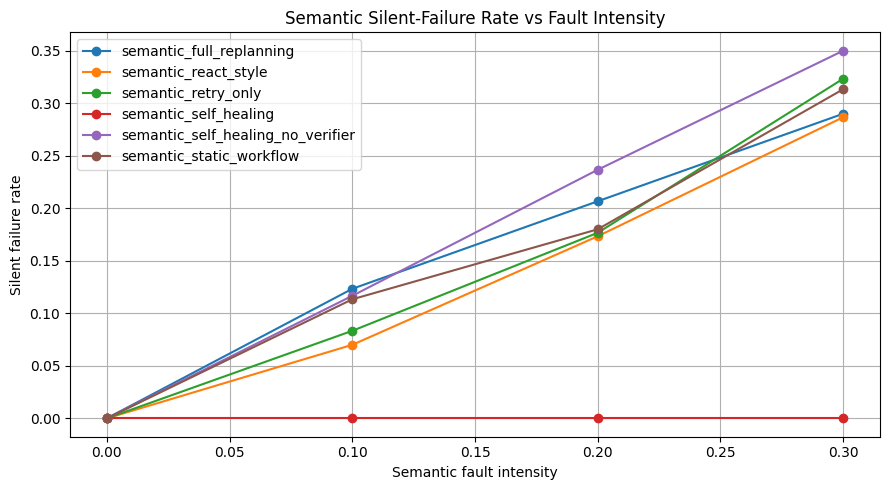

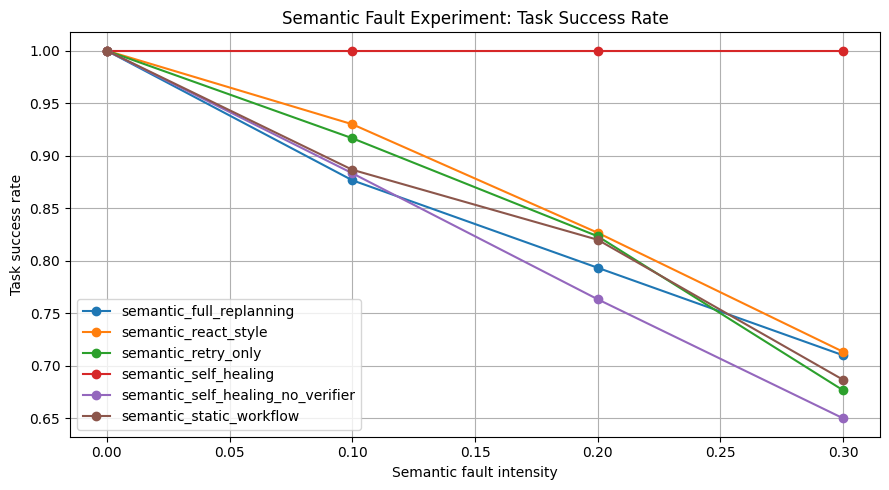

In [49]:
# -----------------------------
# Semantic experiment figures
# -----------------------------

# Silent failure rate should rise for baselines as semantic faults increase.
plot_df = semantic_df.groupby(["semantic_fault_intensity", "method"])["silent_failure"].mean().reset_index()
plt.figure(figsize=(9, 5))
for method in plot_df["method"].unique():
    method_df = plot_df[plot_df["method"] == method]
    plt.plot(method_df["semantic_fault_intensity"], method_df["silent_failure"], marker="o", label=method)
plt.xlabel("Semantic fault intensity")
plt.ylabel("Silent failure rate")
plt.title("Semantic Silent-Failure Rate vs Fault Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "semantic_silent_failure_rate_vs_intensity.png", dpi=300)
plt.show()

# Success rate shows whether verifier-based recovery preserves correctness.
plot_df = semantic_df.groupby(["semantic_fault_intensity", "method"])["success"].mean().reset_index()
plt.figure(figsize=(9, 5))
for method in plot_df["method"].unique():
    method_df = plot_df[plot_df["method"] == method]
    plt.plot(method_df["semantic_fault_intensity"], method_df["success"], marker="o", label=method)
plt.xlabel("Semantic fault intensity")
plt.ylabel("Task success rate")
plt.title("Semantic Fault Experiment: Task Success Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "semantic_success_rate_vs_intensity.png", dpi=300)
plt.show()


<>:98: SyntaxWarning: invalid escape sequence '\l'
<>:169: SyntaxWarning: invalid escape sequence '\l'
<>:98: SyntaxWarning: invalid escape sequence '\l'
<>:169: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2600/2481984202.py:98: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel("Semantic fault intensity $\lambda_s$")
/tmp/ipykernel_2600/2481984202.py:169: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel("Semantic fault intensity $\lambda_s$")


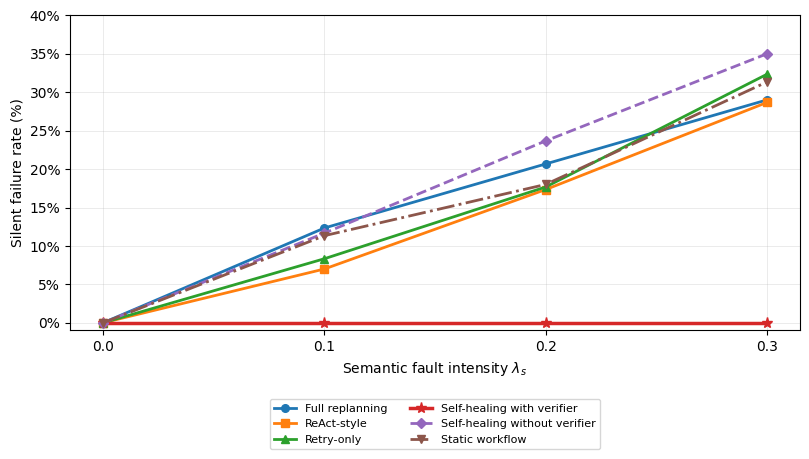

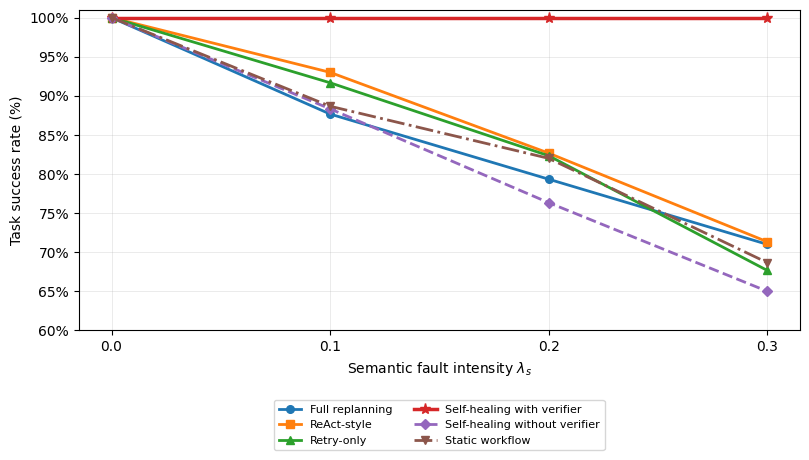

In [50]:
# -----------------------------
# IEEE-style semantic experiment figures
# -----------------------------

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Paper-friendly display names
semantic_method_labels = {
    "semantic_full_replanning": "Full replanning",
    "semantic_react_style": "ReAct-style",
    "semantic_retry_only": "Retry-only",
    "semantic_self_healing": "Self-healing with verifier",
    "semantic_self_healing_no_verifier": "Self-healing without verifier",
    "semantic_static_workflow": "Static workflow",
}

# Stable plotting order
semantic_method_order = [
    "semantic_full_replanning",
    "semantic_react_style",
    "semantic_retry_only",
    "semantic_self_healing",
    "semantic_self_healing_no_verifier",
    "semantic_static_workflow",
]

# Distinct line and marker styles
line_styles = {
    "semantic_full_replanning": "-",
    "semantic_react_style": "-",
    "semantic_retry_only": "-",
    "semantic_self_healing": "-",
    "semantic_self_healing_no_verifier": "--",
    "semantic_static_workflow": "-.",
}

marker_styles = {
    "semantic_full_replanning": "o",
    "semantic_react_style": "s",
    "semantic_retry_only": "^",
    "semantic_self_healing": "*",
    "semantic_self_healing_no_verifier": "D",
    "semantic_static_workflow": "v",
}

line_widths = {
    "semantic_full_replanning": 2,
    "semantic_react_style": 2,
    "semantic_retry_only": 2,
    "semantic_self_healing": 2.5,
    "semantic_self_healing_no_verifier": 2,
    "semantic_static_workflow": 2,
}

marker_sizes = {
    "semantic_full_replanning": 5.5,
    "semantic_react_style": 5.5,
    "semantic_retry_only": 5.5,
    "semantic_self_healing": 8,
    "semantic_self_healing_no_verifier": 5.5,
    "semantic_static_workflow": 5.5,
}


# =========================================================
# Figure 1: Silent failure rate vs semantic fault intensity
# =========================================================

plot_df = (
    semantic_df.groupby(["semantic_fault_intensity", "method"])["silent_failure"]
    .mean()
    .reset_index()
)

# Convert silent failure rate from 0-1 to 0-100
plot_df["silent_failure_pct"] = plot_df["silent_failure"] * 100

fig, ax = plt.subplots(figsize=(8.2, 4.8))

for method in semantic_method_order:
    method_df = plot_df[plot_df["method"] == method].sort_values("semantic_fault_intensity")

    if method_df.empty:
        continue

    ax.plot(
        method_df["semantic_fault_intensity"],
        method_df["silent_failure_pct"],
        linestyle=line_styles.get(method, "-"),
        marker=marker_styles.get(method, "o"),
        linewidth=line_widths.get(method, 2),
        markersize=marker_sizes.get(method, 5.5),
        label=semantic_method_labels.get(method, method),
    )

# Axis labels
ax.set_xlabel("Semantic fault intensity $\lambda_s$")
ax.set_ylabel("Silent failure rate (%)")

# Format y-axis as percentages
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

# Use actual evaluated intensity values as ticks
ax.set_xticks(sorted(plot_df["semantic_fault_intensity"].unique()))

# Y-axis range for readability
y_max = plot_df["silent_failure_pct"].max()
ax.set_ylim(-1, min(40, max(10, y_max + 5)))

# Light IEEE-style grid
ax.grid(True, alpha=0.25, linewidth=0.7)
ax.set_axisbelow(True)

# Legend below plot to avoid covering the lines
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=2,
    fontsize=8,
    frameon=True,
)

# No internal title. The LaTeX caption describes the figure.
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "semantic_silent_failure_rate_vs_intensity.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# =========================================================
# Figure 2: Task success rate vs semantic fault intensity
# Keep this only if the manuscript uses this second figure.
# =========================================================

plot_df = (
    semantic_df.groupby(["semantic_fault_intensity", "method"])["success"]
    .mean()
    .reset_index()
)

# Convert success rate from 0-1 to 0-100
plot_df["success_pct"] = plot_df["success"] * 100

fig, ax = plt.subplots(figsize=(8.2, 4.8))

for method in semantic_method_order:
    method_df = plot_df[plot_df["method"] == method].sort_values("semantic_fault_intensity")

    if method_df.empty:
        continue

    ax.plot(
        method_df["semantic_fault_intensity"],
        method_df["success_pct"],
        linestyle=line_styles.get(method, "-"),
        marker=marker_styles.get(method, "o"),
        linewidth=line_widths.get(method, 2),
        markersize=marker_sizes.get(method, 5.5),
        label=semantic_method_labels.get(method, method),
    )

# Axis labels
ax.set_xlabel("Semantic fault intensity $\lambda_s$")
ax.set_ylabel("Task success rate (%)")

# Format y-axis as percentages
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

# Use actual evaluated intensity values as ticks
ax.set_xticks(sorted(plot_df["semantic_fault_intensity"].unique()))

# Y-axis range for readability
y_min = plot_df["success_pct"].min()
ax.set_ylim(max(0, y_min - 5), 101)

# Light IEEE-style grid
ax.grid(True, alpha=0.25, linewidth=0.7)
ax.set_axisbelow(True)

# Legend below plot to avoid covering the lines
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=2,
    fontsize=8,
    frameon=True,
)

# No internal title. The LaTeX caption describes the figure.
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "semantic_success_rate_vs_intensity.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

<>:94: SyntaxWarning: invalid escape sequence '\l'
<>:94: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2600/1267844460.py:94: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel("Semantic fault intensity $\lambda_s$")


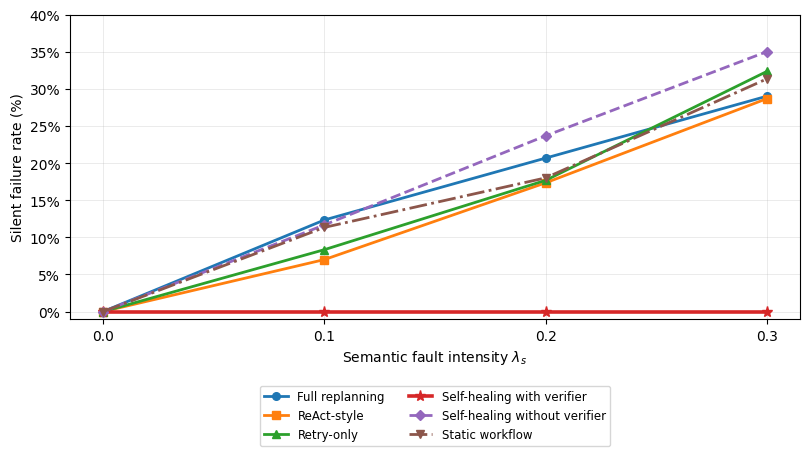

In [51]:
# -----------------------------
# IEEE-style figure: semantic silent-failure rate vs semantic fault intensity
# -----------------------------

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Paper-friendly display names
semantic_method_labels = {
    "semantic_full_replanning": "Full replanning",
    "semantic_react_style": "ReAct-style",
    "semantic_retry_only": "Retry-only",
    "semantic_self_healing": "Self-healing with verifier",
    "semantic_self_healing_no_verifier": "Self-healing without verifier",
    "semantic_static_workflow": "Static workflow",
}

# Stable plotting order
semantic_method_order = [
    "semantic_full_replanning",
    "semantic_react_style",
    "semantic_retry_only",
    "semantic_self_healing",
    "semantic_self_healing_no_verifier",
    "semantic_static_workflow",
]

# Distinct line and marker styles
line_styles = {
    "semantic_full_replanning": "-",
    "semantic_react_style": "-",
    "semantic_retry_only": "-",
    "semantic_self_healing": "-",
    "semantic_self_healing_no_verifier": "--",
    "semantic_static_workflow": "-.",
}

marker_styles = {
    "semantic_full_replanning": "o",
    "semantic_react_style": "s",
    "semantic_retry_only": "^",
    "semantic_self_healing": "*",
    "semantic_self_healing_no_verifier": "D",
    "semantic_static_workflow": "v",
}

line_widths = {
    "semantic_full_replanning": 2.0,
    "semantic_react_style": 2.0,
    "semantic_retry_only": 2.0,
    "semantic_self_healing": 2.6,
    "semantic_self_healing_no_verifier": 2.0,
    "semantic_static_workflow": 2.0,
}

marker_sizes = {
    "semantic_full_replanning": 5.5,
    "semantic_react_style": 5.5,
    "semantic_retry_only": 5.5,
    "semantic_self_healing": 8.0,
    "semantic_self_healing_no_verifier": 5.5,
    "semantic_static_workflow": 5.5,
}

# Group results by semantic fault intensity and method
plot_df = (
    semantic_df.groupby(["semantic_fault_intensity", "method"])["silent_failure"]
    .mean()
    .reset_index()
)

# Convert silent failure rate from 0-1 to 0-100
plot_df["silent_failure_pct"] = plot_df["silent_failure"] * 100

fig, ax = plt.subplots(figsize=(8.2, 4.8))

for method in semantic_method_order:
    method_df = plot_df[plot_df["method"] == method].sort_values("semantic_fault_intensity")

    if method_df.empty:
        continue

    ax.plot(
        method_df["semantic_fault_intensity"],
        method_df["silent_failure_pct"],
        linestyle=line_styles.get(method, "-"),
        marker=marker_styles.get(method, "o"),
        linewidth=line_widths.get(method, 2.0),
        markersize=marker_sizes.get(method, 5.5),
        label=semantic_method_labels.get(method, method),
    )

# Axis labels
ax.set_xlabel("Semantic fault intensity $\lambda_s$")
ax.set_ylabel("Silent failure rate (%)")

# Use actual evaluated semantic fault intensities as ticks
ax.set_xticks(sorted(plot_df["semantic_fault_intensity"].unique()))

# Format y-axis as percentages
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

# Keep enough room for the highest silent-failure value while preserving readability
y_max = plot_df["silent_failure_pct"].max()
ax.set_ylim(-1, min(40, max(10, y_max + 5)))

# Light IEEE-style grid
ax.grid(True, alpha=0.25, linewidth=0.7)
ax.set_axisbelow(True)

# Legend below plot to avoid covering data
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=2,
    fontsize=8.5,
    frameon=True,
)

# No internal title. The LaTeX caption describes the figure.
plt.tight_layout()

# Save high-resolution figure for LaTeX
plt.savefig(
    FIGURES_DIR / "semantic_silent_failure_rate_vs_intensity.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [52]:
# -----------------------------
# Export Experiment 4 artifacts and run completion checklist
# -----------------------------

semantic_df.to_csv(RESULTS_DIR / "semantic_fault_results_100_tasks.csv", index=False)
semantic_summary_pretty.to_csv(RESULTS_DIR / "semantic_fault_summary.csv", index=False)
semantic_by_intensity_pretty.to_csv(RESULTS_DIR / "semantic_fault_by_intensity.csv", index=False)

semantic_latex = semantic_summary_pretty.to_latex(
    index=False,
    float_format="%.2f",
    caption="Semantic silent-failure experiment results.",
    label="tab:semantic_silent_failure",
)
with open(TABLES_DIR / "semantic_silent_failure_table_for_latex.tex", "w") as f:
    f.write(semantic_latex)

required_semantic_outputs = [
    RESULTS_DIR / "semantic_fault_results_100_tasks.csv",
    RESULTS_DIR / "semantic_fault_summary.csv",
    RESULTS_DIR / "semantic_fault_by_intensity.csv",
    TABLES_DIR / "semantic_silent_failure_table_for_latex.tex",
    FIGURES_DIR / "semantic_silent_failure_rate_vs_intensity.png",
    FIGURES_DIR / "semantic_success_rate_vs_intensity.png",
]

missing_semantic_outputs = [str(path) for path in required_semantic_outputs if not path.exists()]
assert not missing_semantic_outputs, f"Missing Experiment 4 outputs: {missing_semantic_outputs}"

print("Experiment 4 completion checklist:")
print("[x] semantic wrong-answer generator added")
print("[x] semantic executor added")
print("[x] semantic baselines and self-healing methods added")
print("[x] semantic sanity check passed")
print("[x] semantic experiment produced", len(semantic_df), "rows")
print("[x] semantic summary tables generated")
print("[x] semantic figures generated")
print("[x] semantic CSV and LaTeX exports generated")


Experiment 4 completion checklist:
[x] semantic wrong-answer generator added
[x] semantic executor added
[x] semantic baselines and self-healing methods added
[x] semantic sanity check passed
[x] semantic experiment produced 7200 rows
[x] semantic summary tables generated
[x] semantic figures generated
[x] semantic CSV and LaTeX exports generated


### 14.3 Experiment 4 Interpretation Notes

Recommended paper framing:

- The semantic experiment evaluates wrong-but-plausible outputs, not explicit runtime failures.
- Baselines generally have higher silent-failure rates because no explicit error signal is available.
- Self-healing reduces silent failures by applying verifier-based validation and recovery.
- The `semantic_self_healing_no_verifier` variant isolates the role of verification: without the verifier, semantic wrong outputs pass through silently.
- This experiment should be reported separately from the main runtime-fault experiment because it targets semantic invalidity rather than explicit tool or runtime failure.


## 15. Figures

These figures are saved into `outputs/figures/` and can be used in the paper draft after reviewing labels and formatting.

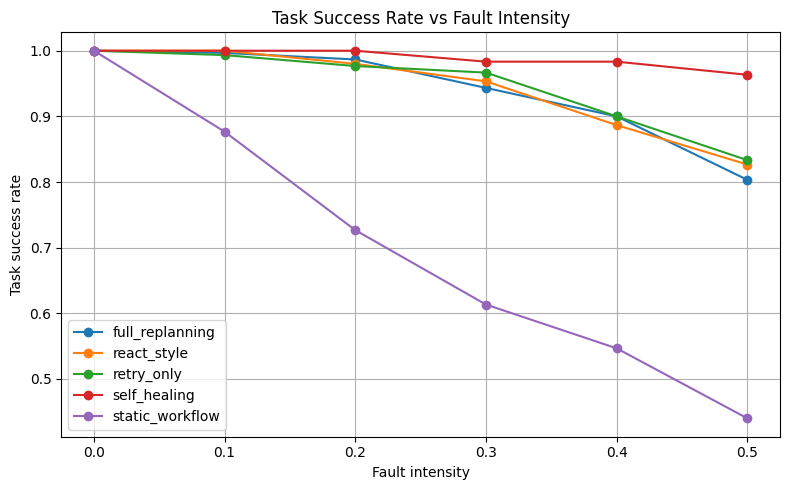

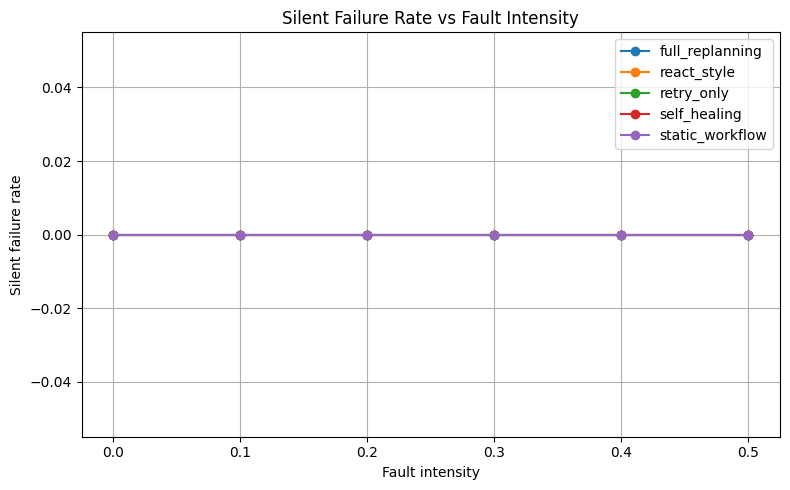

In [53]:
def save_line_plot(metric, ylabel, title, filename):
    plot_df = df.groupby(["fault_intensity", "method"])[metric].mean().reset_index()
    plt.figure(figsize=(8, 5))
    for method in sorted(plot_df["method"].unique()):
        method_df = plot_df[plot_df["method"] == method]
        plt.plot(method_df["fault_intensity"], method_df[metric], marker="o", label=method)
    plt.xlabel("Fault intensity")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=300)
    plt.show()


save_line_plot("success", "Task success rate", "Task Success Rate vs Fault Intensity", "success_rate_vs_fault_intensity.png")
save_line_plot("silent_failure", "Silent failure rate", "Silent Failure Rate vs Fault Intensity", "silent_failure_vs_fault_intensity.png")

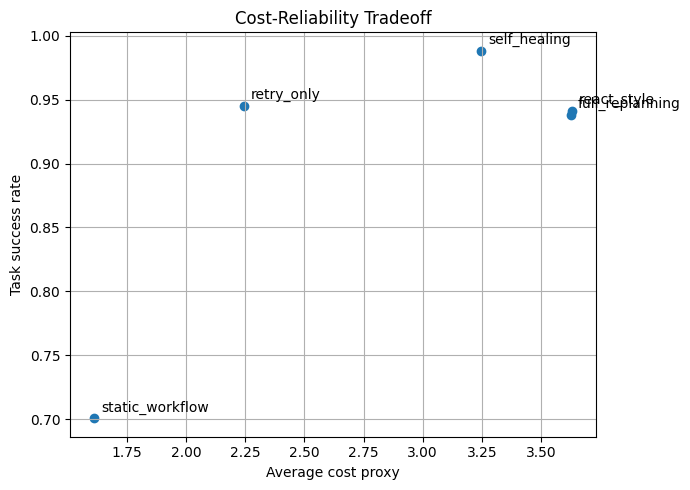

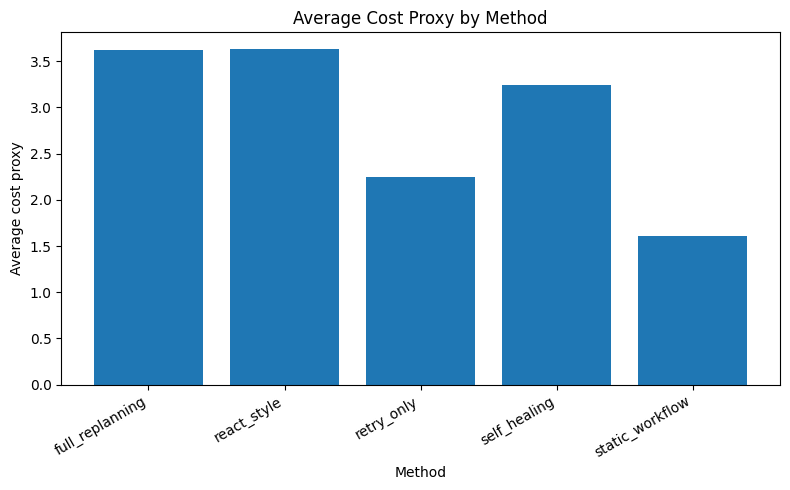

In [54]:
# Cost-reliability tradeoff
tradeoff_df = df.groupby("method").agg(
    success_rate=("success", "mean"),
    avg_cost_proxy=("cost_proxy", "mean"),
).reset_index()

plt.figure(figsize=(7, 5))
plt.scatter(tradeoff_df["avg_cost_proxy"], tradeoff_df["success_rate"])
for _, row in tradeoff_df.iterrows():
    plt.annotate(row["method"], (row["avg_cost_proxy"], row["success_rate"]), textcoords="offset points", xytext=(5, 5))
plt.xlabel("Average cost proxy")
plt.ylabel("Task success rate")
plt.title("Cost-Reliability Tradeoff")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cost_reliability_tradeoff.png", dpi=300)
plt.show()

# Average cost proxy by method
cost_df = df.groupby("method")["cost_proxy"].mean().reset_index()
plt.figure(figsize=(8, 5))
plt.bar(cost_df["method"], cost_df["cost_proxy"])
plt.xlabel("Method")
plt.ylabel("Average cost proxy")
plt.title("Average Cost Proxy by Method")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "average_cost_proxy_by_method.png", dpi=300)
plt.show()

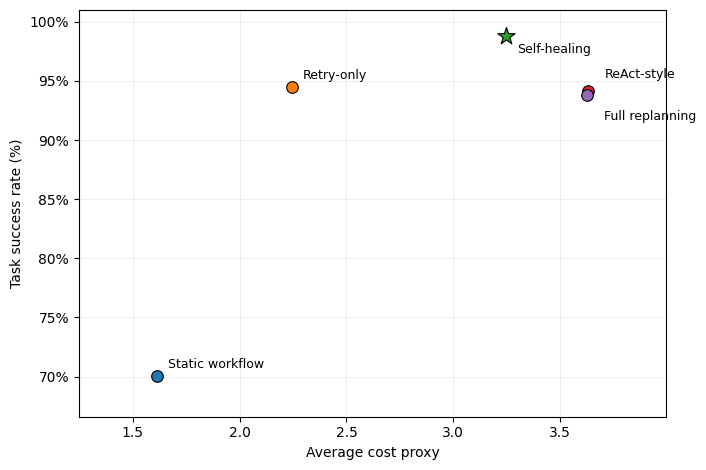

In [55]:
# -----------------------------
# IEEE-style cost-reliability trade-off figure
# -----------------------------

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Aggregate reliability and cost by orchestration method
tradeoff_df = (
    df.groupby("method")
    .agg(
        success_rate=("success", "mean"),
        avg_cost_proxy=("cost_proxy", "mean"),
    )
    .reset_index()
)

# Convert success rate from 0-1 to 0-100
tradeoff_df["success_pct"] = tradeoff_df["success_rate"] * 100

# Paper-friendly display names
method_labels = {
    "static_workflow": "Static workflow",
    "retry_only": "Retry-only",
    "react_style": "ReAct-style",
    "full_replanning": "Full replanning",
    "self_healing": "Self-healing",
}

# Stable plotting order
method_order = [
    "static_workflow",
    "retry_only",
    "self_healing",
    "react_style",
    "full_replanning",
]

# Manual annotation offsets to avoid label overlap
label_offsets = {
    "static_workflow": (8, 8),
    "retry_only": (8, 8),
    "self_healing": (8, -10),
    "react_style": (12, 12),
    "full_replanning": (12, -16),
}

# Marker styling
marker_styles = {
    "static_workflow": "o",
    "retry_only": "o",
    "react_style": "o",
    "full_replanning": "o",
    "self_healing": "*",
}

marker_sizes = {
    "static_workflow": 70,
    "retry_only": 70,
    "react_style": 70,
    "full_replanning": 70,
    "self_healing": 170,
}

fig, ax = plt.subplots(figsize=(7.2, 4.8))

# Plot each method separately for clean annotation control
for method in method_order:
    method_df = tradeoff_df[tradeoff_df["method"] == method]

    if method_df.empty:
        continue

    row = method_df.iloc[0]

    ax.scatter(
        row["avg_cost_proxy"],
        row["success_pct"],
        s=marker_sizes.get(method, 70),
        marker=marker_styles.get(method, "o"),
        edgecolors="black",
        linewidths=0.8,
        zorder=3,
    )

    dx, dy = label_offsets.get(method, (8, 8))

    ax.annotate(
        method_labels.get(method, method),
        xy=(row["avg_cost_proxy"], row["success_pct"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=9,
        ha="left",
        va="center",
    )

# Axis labels
ax.set_xlabel("Average cost proxy")
ax.set_ylabel("Task success rate (%)")

# Format y-axis as percentages
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

# Add axis padding so labels do not touch borders
x_min = tradeoff_df["avg_cost_proxy"].min()
x_max = tradeoff_df["avg_cost_proxy"].max()
y_min = tradeoff_df["success_pct"].min()
y_max = tradeoff_df["success_pct"].max()

x_pad = max(0.25, (x_max - x_min) * 0.18)
y_pad = max(2.0, (y_max - y_min) * 0.12)

ax.set_xlim(x_min - x_pad, x_max + x_pad)
ax.set_ylim(max(0, y_min - y_pad), min(101, y_max + y_pad))

# Clean IEEE-style grid
ax.grid(True, alpha=0.22, linewidth=0.7)
ax.set_axisbelow(True)

# No internal title. The LaTeX caption describes the figure.
plt.tight_layout()

# Save high-resolution figure for LaTeX
plt.savefig(FIGURES_DIR / "cost_reliability_tradeoff.png", dpi=300, bbox_inches="tight")

plt.show()

## 16. Export Manifest

This final cell lists the main generated artifacts. Download the `outputs/` folder or individual files for the paper artifact packet.

In [56]:
print("Generated artifacts:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(path)

Generated artifacts:
outputs/data/tasks_100.json
outputs/data/zero_fault_validation.csv
outputs/figures/ablation_cost_proxy_by_variant.png
outputs/figures/ablation_success_rate_vs_fault_intensity.png
outputs/figures/ablation_trace_events_by_variant.png
outputs/figures/average_cost_proxy_by_method.png
outputs/figures/cost_reliability_tradeoff.png
outputs/figures/failure_type_success_heatmap.png
outputs/figures/recovery_by_failure_type.png
outputs/figures/semantic_silent_failure_rate_vs_intensity.png
outputs/figures/semantic_success_rate_vs_intensity.png
outputs/figures/silent_failure_vs_fault_intensity.png
outputs/figures/success_rate_vs_fault_intensity.png
outputs/results/ablation_by_fault_intensity.csv
outputs/results/ablation_interpretation.csv
outputs/results/ablation_results_100_tasks.csv
outputs/results/ablation_summary_100_tasks.csv
outputs/results/category_results_100_tasks.csv
outputs/results/failure_type_interpretation.csv
outputs/results/failure_type_results_100_tasks.csv
out

## 17. Notes for Paper Framing


Recommended framing:

- Treat fault intensities `0.0–0.3` as the primary evaluation setting.
- Treat `0.4–0.5` as high-stress evaluation.
- Be explicit that this is a controlled synthetic benchmark designed for fault-injection analysis, not a broad general-purpose agent benchmark.
- Experiment 2 groups only rows where an actual fault occurred; this is a harder subset than the aggregate Experiment 1 results.
- The current fault set mostly produces detectable failures, so `silent_failure_rate` may remain low. A separate semantic-fault experiment is needed if silent failure reduction becomes a main claim.
- The failure-type tables support the targeted-recovery story, while future ablation studies should test which self-healing components matter most.


## 18. Experiment 5: Trace and Diagnosability Case Studies

Experiments 1–4 quantify reliability, recovery, cost, ablation effects, and semantic silent-failure behavior. Experiment 5 asks a qualitative but important systems question:

> When self-healing succeeds, can we inspect *why* recovery happened and *how* the orchestrator recovered?

This experiment extracts representative recovery traces from the already-defined self-healing orchestrators. A trace records the task, injected fault, detected failure signal, inferred failure class, recovery action, verifier behavior, final answer, and outcome. These traces support the paper's observability and diagnosability claims.

We extract three case studies:

1. **Runtime/tool failure:** a timeout, unavailable tool, malformed output, schema drift, or partial response.
2. **Context/evidence failure:** stale context or contradictory evidence.
3. **Semantic silent failure:** a plausible but wrong output caught by verifier-guided recovery.

The outputs are saved as JSON traces, CSV summaries, and a LaTeX-ready compact table.

In [57]:
# -----------------------------
# Experiment 5 setup
# -----------------------------

TRACE_DIR = OUTPUT_DIR / "traces"
TRACE_DIR.mkdir(parents=True, exist_ok=True)

# We reuse the task set and orchestrator implementations from Experiments 1–4.
assert len(tasks) == 100, f"Expected 100 benchmark tasks, got {len(tasks)}"
assert callable(self_healing_orchestrator), "self_healing_orchestrator must be defined."
assert callable(semantic_self_healing), "semantic_self_healing must be defined."

print("Experiment 5 setup complete.")
print("Trace output directory:", TRACE_DIR)

Experiment 5 setup complete.
Trace output directory: outputs/traces


### 18.1 JSON-Safe Trace Serialization Helpers

Recovery traces contain nested dictionaries and lists. The following helpers make sure trace payloads can be exported as JSON without serialization errors.

In [58]:
def make_json_safe(obj):
    """
    Convert a single object into a JSON-safe value.

    Most notebook values are already JSON serializable. If a value is not
    serializable, we convert it to a string so the full trace can still be saved.
    """
    try:
        json.dumps(obj)
        return obj
    except TypeError:
        return str(obj)


def recursively_make_json_safe(obj):
    """
    Recursively convert dictionaries and lists into JSON-safe structures.
    """
    if isinstance(obj, dict):
        return {str(k): recursively_make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [recursively_make_json_safe(v) for v in obj]
    return make_json_safe(obj)


print("JSON serialization helpers defined.")

JSON serialization helpers defined.


### 18.2 Trace Summarization Helpers

The full JSON traces are useful for inspection, but they are too large for a paper table. The next helpers extract compact, paper-friendly summaries from each trace.

In [59]:
def _faults_to_string(actual_faults):
    """Convert a fault list/string/None into a compact string."""
    if isinstance(actual_faults, list):
        return ",".join(str(f) for f in actual_faults)
    if actual_faults is None:
        return ""
    return str(actual_faults)


def extract_trace_events(logs):
    """
    Extract high-level events from a self-healing trace log.

    Returns dictionaries/lists used by the compact case-study table.
    """
    detected_signals = []
    failure_classes = []
    recovery_actions = []
    verifier_events = []
    step_names = []

    for log in logs:
        if not isinstance(log, dict):
            continue

        step = str(log.get("step", ""))
        if step:
            step_names.append(step)

        if log.get("failure_signal") is not None:
            detected_signals.append(str(log.get("failure_signal")))

        if log.get("failure_class") is not None:
            failure_classes.append(str(log.get("failure_class")))

        if log.get("recovery_action") is not None:
            recovery_actions.append(str(log.get("recovery_action")))

        # Semantic recovery does not always have a recovery_action field, so
        # infer it from semantic recovery steps for paper-friendly summaries.
        if step == "semantic_recovery_execution":
            recovery_actions.append("verification_guided_semantic_recovery")

        if "verifier" in step.lower() or "verification" in str(log).lower():
            verifier_events.append(step or "verifier_event")

    # Remove duplicates while preserving order.
    def dedupe(seq):
        seen = set()
        out = []
        for item in seq:
            if item not in seen:
                out.append(item)
                seen.add(item)
        return out

    return {
        "step_names": dedupe(step_names),
        "detected_signals": dedupe(detected_signals),
        "failure_classes": dedupe(failure_classes),
        "recovery_actions": dedupe(recovery_actions),
        "verifier_events": dedupe(verifier_events),
    }


def summarize_recovery_trace(task, result, case_study_name, experiment_source, fault_setting, seed):
    """
    Convert a full orchestrator result into one compact summary row.

    This is the row that will appear in trace_case_studies.csv and the
    LaTeX-ready case-study table.
    """
    logs = result.get("logs", [])
    events = extract_trace_events(logs)

    return {
        "case_study": case_study_name,
        "experiment_source": experiment_source,
        "task_id": task.get("task_id"),
        "category": task.get("category"),
        "method": result.get("method"),
        "fault_setting": fault_setting,
        "seed": seed,
        "actual_faults": _faults_to_string(result.get("actual_faults", [])),
        "success": result.get("success"),
        "recovered": result.get("recovered"),
        "silent_failure": result.get("silent_failure"),
        "failure_detected": result.get("failure_detected"),
        "final_failure_signal": result.get("failure_signal"),
        "final_failure_class": result.get("failure_class"),
        "trace_steps": " | ".join(events["step_names"]),
        "detected_signals_in_trace": " | ".join(events["detected_signals"]),
        "failure_classes_in_trace": " | ".join(events["failure_classes"]),
        "recovery_actions_in_trace": " | ".join(events["recovery_actions"]),
        "verifier_events": " | ".join(events["verifier_events"]),
        "tool_calls": result.get("tool_calls"),
        "model_calls": result.get("model_calls"),
        "verifier_calls": result.get("verifier_calls"),
        "recovery_steps": result.get("recovery_steps"),
        "cost_proxy": result.get("cost_proxy"),
        "final_answer": result.get("final_answer"),
    }


print("Trace summarization helpers defined.")

Trace summarization helpers defined.


### 18.3 Candidate Search for Representative Recovery Traces

We search the benchmark for self-healing runs that recovered successfully after an actual injected fault. We intentionally search higher fault intensities first because those are more likely to contain useful recovery traces.

In [60]:
# -----------------------------
# Candidate search for Experiment 1 self-healing traces
# -----------------------------

self_healing_candidates = []

for task in tasks:
    for fault_intensity in [0.5, 0.4, 0.3, 0.2, 0.1]:
        for seed in SEEDS:
            result = self_healing_orchestrator(
                task=task,
                fault_intensity=fault_intensity,
                seed=seed,
                max_recovery_steps=3,
            )
            actual_faults = result.get("actual_faults", [])
            if result.get("success") is True and result.get("recovered") is True and len(actual_faults) > 0:
                self_healing_candidates.append({
                    "task": task,
                    "result": result,
                    "fault_intensity": fault_intensity,
                    "seed": seed,
                    "actual_faults": actual_faults,
                })

print("Number of recovered self-healing candidates:", len(self_healing_candidates))

for i, candidate in enumerate(self_healing_candidates[:8]):
    print("=" * 80)
    print("candidate:", i)
    print("task_id:", candidate["task"]["task_id"])
    print("category:", candidate["task"]["category"])
    print("fault_intensity:", candidate["fault_intensity"])
    print("seed:", candidate["seed"])
    print("actual_faults:", candidate["actual_faults"])
    print("recovery_steps:", candidate["result"].get("recovery_steps"))
    print("final_answer:", candidate["result"].get("final_answer"))

Number of recovered self-healing candidates: 496
candidate: 0
task_id: retrieval_001
category: retrieval_evidence
fault_intensity: 0.5
seed: 1
actual_faults: ['malformed_output']
recovery_steps: 1
final_answer: Product A has standard support for 12 months.
candidate: 1
task_id: retrieval_001
category: retrieval_evidence
fault_intensity: 0.5
seed: 2
actual_faults: ['timeout']
recovery_steps: 1
final_answer: Product A has standard support for 12 months.
candidate: 2
task_id: retrieval_001
category: retrieval_evidence
fault_intensity: 0.5
seed: 3
actual_faults: ['timeout', 'malformed_output']
recovery_steps: 2
final_answer: Product A has standard support for 12 months.
candidate: 3
task_id: retrieval_001
category: retrieval_evidence
fault_intensity: 0.4
seed: 2
actual_faults: ['stale_context']
recovery_steps: 1
final_answer: Product A has standard support for 12 months.
candidate: 4
task_id: retrieval_001
category: retrieval_evidence
fault_intensity: 0.3
seed: 3
actual_faults: ['partial_r

/tmp/ipykernel_2600/3439237790.py:86: DeprecationWarning: ast.Num is deprecated and will be removed in Python 3.14; use ast.Constant instead
  if isinstance(node, ast.Num):  # compatibility for older Python ASTs


### 18.4 Select Runtime/Tool and Context/Evidence Case Studies

We select two representative traces from Experiment 1:

1. a runtime/tool-output failure, such as timeout, schema drift, malformed output, partial response, or unavailable tool;
2. a context/evidence failure, such as stale context or contradictory evidence.

If multiple candidates exist, the notebook chooses the first deterministic candidate found in the search order.

In [61]:
def select_candidate_by_fault(
    candidates,
    target_faults,
    preferred_categories=None,
    exclude_task_ids=None,
    fallback_category=None,
):
    """
    Select a representative candidate that contains one of the target faults.

    Selection priorities:
    1. target fault type is present;
    2. task_id is not already used by another case study;
    3. category is in preferred_categories, if provided;
    4. otherwise, choose the first valid deterministic candidate.

    This keeps the case-study set more diverse and paper-friendly.
    """
    preferred_categories = preferred_categories or []
    exclude_task_ids = set(exclude_task_ids or [])

    fault_matches = [
        candidate for candidate in candidates
        if any(fault in target_faults for fault in candidate.get("actual_faults", []))
    ]

    # First try: fault match + unused task + preferred category.
    for candidate in fault_matches:
        task = candidate["task"]
        if task.get("task_id") not in exclude_task_ids and task.get("category") in preferred_categories:
            return candidate

    # Second try: fault match + unused task.
    for candidate in fault_matches:
        if candidate["task"].get("task_id") not in exclude_task_ids:
            return candidate

    # Third try: any fault match.
    if fault_matches:
        return fault_matches[0]

    # Final fallback: category-based candidate, preferably unused.
    if fallback_category is not None:
        for candidate in candidates:
            task = candidate["task"]
            if task.get("category") == fallback_category and task.get("task_id") not in exclude_task_ids:
                return candidate
        for candidate in candidates:
            if candidate["task"].get("category") == fallback_category:
                return candidate

    return None


runtime_faults = {"timeout", "unavailable_tool", "malformed_output", "schema_drift", "partial_response"}
context_faults = {"stale_context", "contradictory_evidence"}

# Prefer a workflow/planning/calculation task for runtime/tool failures so the
# case study is not always a retrieval task.
runtime_case = select_candidate_by_fault(
    self_healing_candidates,
    runtime_faults,
    preferred_categories=["multi_step_api_workflow", "planning_tool_selection", "calculation_verification"],
)

# Prefer contradiction-resolution for evidence/context failures, then retrieval.
context_case = select_candidate_by_fault(
    self_healing_candidates,
    context_faults,
    preferred_categories=["contradiction_resolution", "retrieval_evidence"],
    exclude_task_ids={runtime_case["task"]["task_id"]} if runtime_case else set(),
    fallback_category="contradiction_resolution",
)

assert runtime_case is not None, "No runtime/tool failure recovery case found."
assert context_case is not None, "No context/evidence recovery case found."

print("Selected runtime/tool failure case:")
print("task_id:", runtime_case["task"]["task_id"])
print("category:", runtime_case["task"]["category"])
print("fault_intensity:", runtime_case["fault_intensity"])
print("seed:", runtime_case["seed"])
print("actual_faults:", runtime_case["actual_faults"])
print("success:", runtime_case["result"].get("success"), "recovered:", runtime_case["result"].get("recovered"))

print("\nSelected context/evidence failure case:")
print("task_id:", context_case["task"]["task_id"])
print("category:", context_case["task"]["category"])
print("fault_intensity:", context_case["fault_intensity"])
print("seed:", context_case["seed"])
print("actual_faults:", context_case["actual_faults"])
print("success:", context_case["result"].get("success"), "recovered:", context_case["result"].get("recovered"))

Selected runtime/tool failure case:
task_id: workflow_001
category: multi_step_api_workflow
fault_intensity: 0.5
seed: 1
actual_faults: ['timeout']
success: True recovered: True

Selected context/evidence failure case:
task_id: retrieval_001
category: retrieval_evidence
fault_intensity: 0.4
seed: 2
actual_faults: ['stale_context']
success: True recovered: True


### 18.5 Select a Semantic Silent-Failure Recovery Case

The third case study uses Experiment 4. We search for a semantic wrong-output fault where the verifier rejects the initial answer and self-healing recovers successfully.

In [62]:
# -----------------------------
# Candidate search for semantic self-healing traces
# -----------------------------

semantic_candidates = []

for task in tasks:
    for semantic_fault_intensity in [0.3, 0.2, 0.1]:
        for seed in SEEDS:
            result = semantic_self_healing(
                task=task,
                semantic_fault_intensity=semantic_fault_intensity,
                seed=seed,
                max_recovery_steps=3,
            )
            actual_faults = result.get("actual_faults", [])
            if (
                "semantic_wrong_output" in actual_faults
                and result.get("success") is True
                and result.get("recovered") is True
            ):
                semantic_candidates.append({
                    "task": task,
                    "result": result,
                    "semantic_fault_intensity": semantic_fault_intensity,
                    "seed": seed,
                    "actual_faults": actual_faults,
                })

print("Number of semantic recovered candidates:", len(semantic_candidates))

for i, candidate in enumerate(semantic_candidates[:8]):
    print("=" * 80)
    print("candidate:", i)
    print("task_id:", candidate["task"]["task_id"])
    print("category:", candidate["task"]["category"])
    print("semantic_fault_intensity:", candidate["semantic_fault_intensity"])
    print("seed:", candidate["seed"])
    print("actual_faults:", candidate["actual_faults"])
    print("recovery_steps:", candidate["result"].get("recovery_steps"))
    print("final_answer:", candidate["result"].get("final_answer"))

assert len(semantic_candidates) > 0, "No semantic self-healing recovery candidates found."

# Prefer a semantic case using a task not already selected for the first two
# case studies, so the final case-study set is more diverse.
used_task_ids = {runtime_case["task"]["task_id"], context_case["task"]["task_id"]}
semantic_case = None
for candidate in semantic_candidates:
    if candidate["task"].get("task_id") not in used_task_ids:
        semantic_case = candidate
        break
if semantic_case is None:
    semantic_case = semantic_candidates[0]

print("\nSelected semantic silent-failure case:")
print("task_id:", semantic_case["task"]["task_id"])
print("category:", semantic_case["task"]["category"])
print("semantic_fault_intensity:", semantic_case["semantic_fault_intensity"])
print("seed:", semantic_case["seed"])
print("actual_faults:", semantic_case["actual_faults"])
print("success:", semantic_case["result"].get("success"), "recovered:", semantic_case["result"].get("recovered"))

Number of semantic recovered candidates: 167
candidate: 0
task_id: retrieval_001
category: retrieval_evidence
semantic_fault_intensity: 0.3
seed: 3
actual_faults: ['semantic_wrong_output']
recovery_steps: 1
final_answer: Product A has standard support for 12 months.
candidate: 1
task_id: retrieval_002
category: retrieval_evidence
semantic_fault_intensity: 0.3
seed: 1
actual_faults: ['semantic_wrong_output']
recovery_steps: 1
final_answer: Product B has a refund window of 30 days.
candidate: 2
task_id: retrieval_003
category: retrieval_evidence
semantic_fault_intensity: 0.3
seed: 2
actual_faults: ['semantic_wrong_output']
recovery_steps: 1
final_answer: Enterprise customers receive priority support within 4 hours.
candidate: 3
task_id: retrieval_003
category: retrieval_evidence
semantic_fault_intensity: 0.2
seed: 1
actual_faults: ['semantic_wrong_output']
recovery_steps: 1
final_answer: Enterprise customers receive priority support within 4 hours.
candidate: 4
task_id: retrieval_004
cat

/tmp/ipykernel_2600/3439237790.py:86: DeprecationWarning: ast.Num is deprecated and will be removed in Python 3.14; use ast.Constant instead
  if isinstance(node, ast.Num):  # compatibility for older Python ASTs


### 18.6 Save Full JSON Traces

The compact tables are useful for the paper, but the full JSON traces are useful for the artifact packet. Each JSON file contains the selected task, the full orchestrator result, and the nested recovery logs.

In [63]:
case_studies = [
    {
        "name": "runtime_tool_failure",
        "experiment_source": "Experiment 1",
        "case": runtime_case,
        "fault_setting": f"lambda={runtime_case['fault_intensity']}",
        "seed": runtime_case["seed"],
        "filename": "example_recovery_trace_1_runtime_tool_failure.json",
    },
    {
        "name": "context_evidence_failure",
        "experiment_source": "Experiment 1",
        "case": context_case,
        "fault_setting": f"lambda={context_case['fault_intensity']}",
        "seed": context_case["seed"],
        "filename": "example_recovery_trace_2_context_evidence_failure.json",
    },
    {
        "name": "semantic_silent_failure",
        "experiment_source": "Experiment 4",
        "case": semantic_case,
        "fault_setting": f"semantic_lambda={semantic_case['semantic_fault_intensity']}",
        "seed": semantic_case["seed"],
        "filename": "example_recovery_trace_3_semantic_silent_failure.json",
    },
]

for item in case_studies:
    payload = {
        "case_study": item["name"],
        "experiment_source": item["experiment_source"],
        "fault_setting": item["fault_setting"],
        "seed": item["seed"],
        "task": item["case"]["task"],
        "result": item["case"]["result"],
    }
    payload = recursively_make_json_safe(payload)
    output_path = TRACE_DIR / item["filename"]
    with open(output_path, "w") as f:
        json.dump(payload, f, indent=2)
    print("Saved:", output_path)

Saved: outputs/traces/example_recovery_trace_1_runtime_tool_failure.json
Saved: outputs/traces/example_recovery_trace_2_context_evidence_failure.json
Saved: outputs/traces/example_recovery_trace_3_semantic_silent_failure.json


### 18.7 Compact Trace Tables for the Paper

The next cells create two tables:

1. a full trace summary with detailed fields;
2. a compact paper-friendly table containing the key fault, recovery, and verifier information.

In [64]:
trace_summary_rows = []

for item in case_studies:
    trace_summary_rows.append(
        summarize_recovery_trace(
            task=item["case"]["task"],
            result=item["case"]["result"],
            case_study_name=item["name"],
            experiment_source=item["experiment_source"],
            fault_setting=item["fault_setting"],
            seed=item["seed"],
        )
    )

trace_case_studies_df = pd.DataFrame(trace_summary_rows)
trace_case_studies_df

,case_study,experiment_source,task_id,category,method,fault_setting,seed,actual_faults,success,recovered,silent_failure,failure_detected,final_failure_signal,final_failure_class,trace_steps,detected_signals_in_trace,failure_classes_in_trace,recovery_actions_in_trace,verifier_events,tool_calls,model_calls,verifier_calls,recovery_steps,cost_proxy,final_answer
0,runtime_tool_failure,Experiment 1,workflow_001,multi_step_api_workflow,self_healing,lambda=0.5,1,timeout,True,True,False,False,None,tool_invocation_failure,initial_execution | failure_detected | recover...,timeout,tool_invocation_failure,retry_with_backoff,,3,0,1,1,4,"Order O100 belongs to customer C001, who is en..."
1,context_evidence_failure,Experiment 1,retrieval_001,retrieval_evidence,self_healing,lambda=0.4,2,stale_context,True,True,False,False,None,context_failure,initial_execution | failure_detected | recover...,stale_context,context_failure,refresh_retrieval,,2,0,1,1,3,Product A has standard support for 12 months.
2,semantic_silent_failure,Experiment 4,retrieval_002,retrieval_evidence,semantic_self_healing,semantic_lambda=0.3,1,semantic_wrong_output,True,True,False,False,None,None,initial_execution | verifier_rejected_answer |...,semantic_validation_failure,semantic_failure,verification_guided_semantic_recovery,verifier_rejected_answer,2,0,2,1,4,Product B has a refund window of 30 days.


In [65]:
trace_case_studies_compact = trace_case_studies_df[[
    "case_study",
    "task_id",
    "category",
    "actual_faults",
    "detected_signals_in_trace",
    "failure_classes_in_trace",
    "recovery_actions_in_trace",
    "verifier_calls",
    "recovery_steps",
    "success",
    "recovered",
]].copy()

trace_case_studies_compact

,case_study,task_id,category,actual_faults,detected_signals_in_trace,failure_classes_in_trace,recovery_actions_in_trace,verifier_calls,recovery_steps,success,recovered
0,runtime_tool_failure,workflow_001,multi_step_api_workflow,timeout,timeout,tool_invocation_failure,retry_with_backoff,1,1,True,True
1,context_evidence_failure,retrieval_001,retrieval_evidence,stale_context,stale_context,context_failure,refresh_retrieval,1,1,True,True
2,semantic_silent_failure,retrieval_002,retrieval_evidence,semantic_wrong_output,semantic_validation_failure,semantic_failure,verification_guided_semantic_recovery,2,1,True,True


### 18.8 Step-Level Trace Table

For deeper debugging, the following table flattens the selected traces into one row per log event. This is usually too detailed for the main paper, but useful for the artifact packet and appendix.

In [66]:
def flatten_trace_logs(case_studies):
    """Create one row per log step across selected case studies."""
    rows = []
    for item in case_studies:
        result = item["case"]["result"]
        task = item["case"]["task"]
        logs = result.get("logs", [])
        for step_index, log in enumerate(logs):
            if not isinstance(log, dict):
                log = {"raw_log": str(log)}
            rows.append({
                "case_study": item["name"],
                "task_id": task.get("task_id"),
                "category": task.get("category"),
                "step_index": step_index,
                "step": log.get("step"),
                "failure_signal": log.get("failure_signal"),
                "failure_class": log.get("failure_class"),
                "recovery_action": log.get("recovery_action"),
                "has_response": "response" in log,
                "log_summary": str({k: v for k, v in log.items() if k != "response"})[:500],
            })
    return pd.DataFrame(rows)


trace_steps_df = flatten_trace_logs(case_studies)
trace_steps_df

,case_study,task_id,category,step_index,step,failure_signal,failure_class,recovery_action,has_response,log_summary
0,runtime_tool_failure,workflow_001,multi_step_api_workflow,0,initial_execution,None,None,None,True,"{'step': 'initial_execution', 'attempt': 0, 'f..."
1,runtime_tool_failure,workflow_001,multi_step_api_workflow,1,failure_detected,timeout,tool_invocation_failure,None,False,"{'step': 'failure_detected', 'failure_signal':..."
2,runtime_tool_failure,workflow_001,multi_step_api_workflow,2,recovery_action_selected,None,tool_invocation_failure,retry_with_backoff,False,"{'step': 'recovery_action_selected', 'recovery..."
3,runtime_tool_failure,workflow_001,multi_step_api_workflow,3,recovery_execution,None,None,retry_with_backoff,True,"{'step': 'recovery_execution', 'recovery_attem..."
4,context_evidence_failure,retrieval_001,retrieval_evidence,0,initial_execution,None,None,None,True,"{'step': 'initial_execution', 'attempt': 0, 'f..."
5,context_evidence_failure,retrieval_001,retrieval_evidence,1,failure_detected,stale_context,context_failure,None,False,"{'step': 'failure_detected', 'failure_signal':..."
6,context_evidence_failure,retrieval_001,retrieval_evidence,2,recovery_action_selected,None,context_failure,refresh_retrieval,False,"{'step': 'recovery_action_selected', 'recovery..."
7,context_evidence_failure,retrieval_001,retrieval_evidence,3,recovery_execution,None,None,refresh_retrieval,True,"{'step': 'recovery_execution', 'recovery_attem..."
8,semantic_silent_failure,retrieval_002,retrieval_evidence,0,initial_execution,None,None,None,True,{'step': 'initial_execution'}
9,semantic_silent_failure,retrieval_002,retrieval_evidence,1,verifier_rejected_answer,semantic_validation_failure,semantic_failure,None,False,"{'step': 'verifier_rejected_answer', 'failure_..."


### 18.9 Trace Completeness Summary

A useful trace should contain enough information to diagnose what happened. The following diagnostic checks whether each selected trace contains logs, faults, failure signals, recovery actions or semantic recovery events, verifier activity, and a final answer.

In [67]:
def compute_trace_completeness(result):
    """
    Compute simple trace-completeness indicators for a result object.
    """
    logs = result.get("logs", [])
    events = extract_trace_events(logs)

    has_logs = len(logs) > 0
    has_faults = len(result.get("actual_faults", [])) > 0
    has_failure_signal = bool(events["detected_signals"]) or result.get("failure_signal") is not None
    has_recovery_action = bool(events["recovery_actions"])
    has_verifier_activity = result.get("verifier_calls", 0) > 0 or bool(events["verifier_events"])
    has_final_answer = result.get("final_answer") is not None

    indicators = [
        has_logs,
        has_faults,
        has_failure_signal,
        has_recovery_action,
        has_verifier_activity,
        has_final_answer,
    ]

    return {
        "has_logs": has_logs,
        "has_faults": has_faults,
        "has_failure_signal": has_failure_signal,
        "has_recovery_action": has_recovery_action,
        "has_verifier_activity": has_verifier_activity,
        "has_final_answer": has_final_answer,
        "trace_completeness_score": sum(indicators),
        "trace_completeness_max": len(indicators),
    }


trace_completeness_rows = []
for item in case_studies:
    row = compute_trace_completeness(item["case"]["result"])
    row["case_study"] = item["name"]
    row["task_id"] = item["case"]["task"].get("task_id")
    row["category"] = item["case"]["task"].get("category")
    trace_completeness_rows.append(row)

trace_completeness_df = pd.DataFrame(trace_completeness_rows)
trace_completeness_df

,has_logs,has_faults,has_failure_signal,has_recovery_action,has_verifier_activity,has_final_answer,trace_completeness_score,trace_completeness_max,case_study,task_id,category
0,True,True,True,True,True,True,6,6,runtime_tool_failure,workflow_001,multi_step_api_workflow
1,True,True,True,True,True,True,6,6,context_evidence_failure,retrieval_001,retrieval_evidence
2,True,True,True,True,True,True,6,6,semantic_silent_failure,retrieval_002,retrieval_evidence


### 18.10 Export Experiment 5 Artifacts

This cell exports the trace case-study tables and a LaTeX-ready compact table.

In [68]:
# Export trace tables.
trace_case_studies_df.to_csv(RESULTS_DIR / "trace_case_studies.csv", index=False)
trace_case_studies_compact.to_csv(RESULTS_DIR / "trace_case_studies_compact.csv", index=False)
trace_steps_df.to_csv(RESULTS_DIR / "trace_case_study_steps.csv", index=False)
trace_completeness_df.to_csv(RESULTS_DIR / "trace_completeness_summary.csv", index=False)

# Export LaTeX table for paper/appendix use.
trace_latex = trace_case_studies_compact.to_latex(
    index=False,
    caption="Representative self-healing recovery traces.",
    label="tab:trace_case_studies",
)

with open(TABLES_DIR / "case_study_trace_table_for_latex.tex", "w") as f:
    f.write(trace_latex)

print(trace_latex)
print("\nExperiment 5 trace artifacts exported.")

\begin{table}
\caption{Representative self-healing recovery traces.}
\label{tab:trace_case_studies}
\begin{tabular}{lllllllrrrr}
\toprule
case_study & task_id & category & actual_faults & detected_signals_in_trace & failure_classes_in_trace & recovery_actions_in_trace & verifier_calls & recovery_steps & success & recovered \\
\midrule
runtime_tool_failure & workflow_001 & multi_step_api_workflow & timeout & timeout & tool_invocation_failure & retry_with_backoff & 1 & 1 & True & True \\
context_evidence_failure & retrieval_001 & retrieval_evidence & stale_context & stale_context & context_failure & refresh_retrieval & 1 & 1 & True & True \\
semantic_silent_failure & retrieval_002 & retrieval_evidence & semantic_wrong_output & semantic_validation_failure & semantic_failure & verification_guided_semantic_recovery & 2 & 1 & True & True \\
\bottomrule
\end{tabular}
\end{table}


Experiment 5 trace artifacts exported.


### 18.11 Experiment 5 Completion Checklist

The following checklist verifies that Experiment 5 generated the expected trace artifacts.

In [69]:
experiment_5_checks = {
    "runtime_case_selected": runtime_case is not None,
    "context_case_selected": context_case is not None,
    "semantic_case_selected": semantic_case is not None,
    "trace_case_studies_df_has_3_rows": len(trace_case_studies_df) == 3,
    "trace_steps_generated": len(trace_steps_df) > 0,
    "trace_completeness_generated": len(trace_completeness_df) == 3,
    "runtime_trace_json_exists": (TRACE_DIR / "example_recovery_trace_1_runtime_tool_failure.json").exists(),
    "context_trace_json_exists": (TRACE_DIR / "example_recovery_trace_2_context_evidence_failure.json").exists(),
    "semantic_trace_json_exists": (TRACE_DIR / "example_recovery_trace_3_semantic_silent_failure.json").exists(),
    "compact_csv_exists": (RESULTS_DIR / "trace_case_studies_compact.csv").exists(),
    "latex_table_exists": (TABLES_DIR / "case_study_trace_table_for_latex.tex").exists(),
}

for check_name, passed in experiment_5_checks.items():
    print(f"{check_name}: {'PASSED' if passed else 'FAILED'}")

assert all(experiment_5_checks.values()), "One or more Experiment 5 checks failed."
print("\nExperiment 5 completion checklist passed.")

runtime_case_selected: PASSED
context_case_selected: PASSED
semantic_case_selected: PASSED
trace_case_studies_df_has_3_rows: PASSED
trace_steps_generated: PASSED
trace_completeness_generated: PASSED
runtime_trace_json_exists: PASSED
context_trace_json_exists: PASSED
semantic_trace_json_exists: PASSED
compact_csv_exists: PASSED
latex_table_exists: PASSED

Experiment 5 completion checklist passed.


### 18.12 Experiment 5 Interpretation Notes

Use these notes when writing the Results section:

- The runtime/tool failure trace demonstrates how explicit tool-output failures are detected and recovered.
- The context/evidence trace demonstrates that the orchestrator can record evidence-related failures such as stale or contradictory context.
- The semantic silent-failure trace demonstrates the role of verifier-guided recovery when an answer is syntactically valid but semantically wrong.
- The no-observability ablation in Experiment 3 shows that observability may not directly increase success, but Experiment 5 shows why traces are still valuable for diagnosis, debugging, and auditability.
- The trace case studies should be framed as representative examples, not as aggregate statistical results.

## Final Artifact Outputs

The notebook produces the following artifact types:

- Benchmark task definitions
- Main experiment results
- Failure-class analysis results
- Ablation study results
- Semantic silent-failure results
- Representative recovery traces
- Paper figures
- LaTeX-ready tables
- A ZIP archive of generated outputs

## 19. Final Export Manifest Including Experiment 5

This final manifest lists the artifacts generated by Experiments 1–5.

In [70]:
print("Generated artifacts after Experiments 1–5:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(path)

Generated artifacts after Experiments 1–5:
outputs/data/tasks_100.json
outputs/data/zero_fault_validation.csv
outputs/figures/ablation_cost_proxy_by_variant.png
outputs/figures/ablation_success_rate_vs_fault_intensity.png
outputs/figures/ablation_trace_events_by_variant.png
outputs/figures/average_cost_proxy_by_method.png
outputs/figures/cost_reliability_tradeoff.png
outputs/figures/failure_type_success_heatmap.png
outputs/figures/recovery_by_failure_type.png
outputs/figures/semantic_silent_failure_rate_vs_intensity.png
outputs/figures/semantic_success_rate_vs_intensity.png
outputs/figures/silent_failure_vs_fault_intensity.png
outputs/figures/success_rate_vs_fault_intensity.png
outputs/results/ablation_by_fault_intensity.csv
outputs/results/ablation_interpretation.csv
outputs/results/ablation_results_100_tasks.csv
outputs/results/ablation_summary_100_tasks.csv
outputs/results/category_results_100_tasks.csv
outputs/results/failure_type_interpretation.csv
outputs/results/failure_type_res

## Final Reproducibility Checks

The following checks verify that the notebook generated the expected number of experiment rows and trace case studies. These checks are intended to make the artifact self-validating for readers and reviewers.

In [71]:
print("Experiment 1 rows:", len(df))
print("Experiment 3 rows:", len(ablation_df))
print("Experiment 4 rows:", len(semantic_df))

assert len(df) == 9000
assert len(ablation_df) == 9000
assert len(semantic_df) == 7200

assert "actual_faults" in df.columns
assert "actual_faults" in ablation_df.columns
assert "actual_faults" in semantic_df.columns

assert len(trace_case_studies_compact) == 3
assert len(trace_steps_df) > 0
assert len(trace_completeness_df) == 3

print("All experiment sanity checks passed.")

Experiment 1 rows: 9000
Experiment 3 rows: 9000
Experiment 4 rows: 7200
All experiment sanity checks passed.


## Final Zero-Fault Validation Export

This final validation export records the zero-fault benchmark behavior as an artifact file. It duplicates the conceptual validation performed earlier, but it is kept here to produce a standalone CSV for the repository artifact package.

In [72]:
from pathlib import Path
# import pandas as pd

OUTPUTS_DIR = Path("outputs")
RESULTS_DIR = OUTPUTS_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

zero_fault_rows = []

for task in tasks:
    response = execute_task_once(
        task=task,
        fault_intensity=0.0,
        seed=1,
        method_name="zero_fault_validation",
        attempt=0
    )

    success = evaluate_success(
        response.get("output"),
        task["success_criteria"]
    )

    zero_fault_rows.append({
        "task_id": task["task_id"],
        "category": task["category"],
        "status": response.get("status"),
        "error_type": response.get("error_type"),
        "output": response.get("output"),
        "success": success,
        "tool_calls": len(response.get("tool_trace", [])),
        "latency_ms": response.get("latency_ms", 0)
    })

zero_fault_validation_df = pd.DataFrame(zero_fault_rows)

display(zero_fault_validation_df.head())

print("Zero-fault validation success rate:", zero_fault_validation_df["success"].mean())

assert zero_fault_validation_df["success"].mean() == 1.0, "Zero-fault validation failed."

# Save in BOTH places so either checklist path works.
zero_fault_validation_df.to_csv(OUTPUTS_DIR / "zero_fault_validation.csv", index=False)
zero_fault_validation_df.to_csv(RESULTS_DIR / "zero_fault_validation.csv", index=False)

print("Saved:")
print(OUTPUTS_DIR / "zero_fault_validation.csv")
print(RESULTS_DIR / "zero_fault_validation.csv")

/tmp/ipykernel_2600/3439237790.py:86: DeprecationWarning: ast.Num is deprecated and will be removed in Python 3.14; use ast.Constant instead
  if isinstance(node, ast.Num):  # compatibility for older Python ASTs


,task_id,category,status,error_type,output,success,tool_calls,latency_ms
0,retrieval_001,retrieval_evidence,success,None,Product A has standard support for 12 months.,True,1,80
1,retrieval_002,retrieval_evidence,success,None,Product B has a refund window of 30 days.,True,1,80
2,retrieval_003,retrieval_evidence,success,None,Enterprise customers receive priority support ...,True,1,80
3,retrieval_004,retrieval_evidence,success,None,Product A has standard support for 12 months.,True,1,80
4,retrieval_005,retrieval_evidence,success,None,Product B has a refund window of 30 days.,True,1,80


Zero-fault validation success rate: 1.0
Saved:
outputs/zero_fault_validation.csv
outputs/results/zero_fault_validation.csv


## Final Required File Check

This cell verifies that the notebook exported the key files expected by the paper artifact: tasks, result CSV files, paper figures, LaTeX tables, and representative JSON traces.

In [73]:
# from pathlib import Path

OUTPUTS_DIR = Path("outputs")

required_files = [
    # Core dataset / validation
    OUTPUTS_DIR / "data" / "tasks_100.json",
    OUTPUTS_DIR / "zero_fault_validation.csv",

    # Experiment 1
    OUTPUTS_DIR / "results" / "results_100_tasks.csv",
    OUTPUTS_DIR / "results" / "overall_results_100_tasks.csv",
    OUTPUTS_DIR / "results" / "fault_intensity_results_100_tasks.csv",
    OUTPUTS_DIR / "results" / "category_results_100_tasks.csv",
    OUTPUTS_DIR / "figures" / "success_rate_vs_fault_intensity.png",
    OUTPUTS_DIR / "figures" / "cost_reliability_tradeoff.png",

    # Experiment 2
    OUTPUTS_DIR / "results" / "failure_type_results_100_tasks.csv",
    OUTPUTS_DIR / "results" / "failure_type_success_pivot.csv",
    OUTPUTS_DIR / "figures" / "failure_type_success_heatmap.png",

    # Experiment 3
    OUTPUTS_DIR / "results" / "ablation_results_100_tasks.csv",
    OUTPUTS_DIR / "results" / "ablation_summary_100_tasks.csv",
    OUTPUTS_DIR / "figures" / "ablation_success_rate_vs_fault_intensity.png",

    # Experiment 4
    OUTPUTS_DIR / "results" / "semantic_fault_results_100_tasks.csv",
    OUTPUTS_DIR / "results" / "semantic_fault_summary.csv",
    OUTPUTS_DIR / "figures" / "semantic_silent_failure_rate_vs_intensity.png",
    OUTPUTS_DIR / "figures" / "semantic_success_rate_vs_intensity.png",

    # Experiment 5
    OUTPUTS_DIR / "results" / "trace_case_studies.csv",
    OUTPUTS_DIR / "results" / "trace_case_studies_compact.csv",
    OUTPUTS_DIR / "results" / "trace_case_study_steps.csv",
    OUTPUTS_DIR / "results" / "trace_completeness_summary.csv",
    OUTPUTS_DIR / "tables" / "case_study_trace_table_for_latex.tex",

    # Trace JSONs
    OUTPUTS_DIR / "traces" / "example_recovery_trace_1_runtime_tool_failure.json",
    OUTPUTS_DIR / "traces" / "example_recovery_trace_2_context_evidence_failure.json",
    OUTPUTS_DIR / "traces" / "example_recovery_trace_3_semantic_silent_failure.json",
]

missing_files = [str(path) for path in required_files if not path.exists()]
present_files = [str(path) for path in required_files if path.exists()]

print(f"Required files checked: {len(required_files)}")
print(f"Files present: {len(present_files)}")
print(f"Files missing: {len(missing_files)}")

if missing_files:
    print("\nMissing files:")
    for file in missing_files:
        print(" -", file)
else:
    print("\nAll required output files exist.")

Required files checked: 26
Files present: 26
Files missing: 0

All required output files exist.


## Package Outputs

This cell creates a ZIP archive of the `outputs/` directory for convenient upload or archival. The GitHub repository can include either the expanded folders or this ZIP artifact, but the expanded folders are easier for readers to browse.

In [74]:
from pathlib import Path
import shutil

OUTPUTS_DIR = Path("outputs")
ZIP_NAME = "self_healing_orchestrator_experiments_1_5_outputs.zip"

# Remove old zip if it exists
if Path(ZIP_NAME).exists():
    Path(ZIP_NAME).unlink()

# Create zip from outputs folder
shutil.make_archive(
    base_name=ZIP_NAME.replace(".zip", ""),
    format="zip",
    root_dir=OUTPUTS_DIR
)

print(f"Created ZIP: {ZIP_NAME}")

Created ZIP: self_healing_orchestrator_experiments_1_5_outputs.zip
